In [38]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
from scipy import stats
import sys
from pathlib import Path
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from rich.table import Table
from rich.console import Console
from rich.panel import Panel

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

def _resolve_project_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'config.py').exists():
            return candidate
    raise FileNotFoundError('config.py not found in cwd or parents')

PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f'project root: {PROJECT_ROOT}')

from config import (
    GENE_PATHS,
    VARIANT_PATHS,
    SOURCE_PALETTE,
    load_variant_pairs_matched,
)
from utils.plot_utils import autosave

print('\navailable datasets:')
for name in ['clingen', 'clingen_null', 'background', 'background_null']:
    print(f'  {name}: {VARIANT_PATHS[name].name}')

project root: /Users/markus/in-silico-vg-analysis

available datasets:
  clingen: ClinGen_HI_Gnomad_variants_dedup_31012026.parquet
  clingen_null: ClinGen_HI_Synth_variants_downsampled_perm_31012026.parquet
  background: Background_Gnomad_variants_dedup_perm_31012026.parquet
  background_null: Background_Synth_variants_downsampled_perm_31012026.parquet


In [39]:
CLINGEN_VAR = VARIANT_PATHS['clingen']
BG_VAR = VARIANT_PATHS['background']
BG_NULL_VAR = VARIANT_PATHS['background_null']
CLINGEN_NULL_VAR = VARIANT_PATHS['clingen_null']

CLINGEN_GENE = GENE_PATHS['clingen']
BG_GENE = GENE_PATHS['background']
BG_NULL_GENE = GENE_PATHS['background_null']
CLINGEN_NULL_GENE = GENE_PATHS['clingen_null']

PATHS = {
    'background': BG_VAR,
    'background_null': BG_NULL_VAR,
    'clingen': CLINGEN_VAR,
    'clingen_null': CLINGEN_NULL_VAR,
}

GENE_PATHS = {
    'background': BG_GENE,
    'background_null': BG_NULL_GENE,
    'clingen': CLINGEN_GENE,
    'clingen_null': CLINGEN_NULL_GENE,
}

# show column structure (datasets loaded in next cells)
df_var_temp = pl.read_parquet(BG_VAR)
print(f'Variant columns: {df_var_temp.columns}')

df_gene_temp = pl.read_parquet(BG_GENE)
print(f'Gene columns: {df_gene_temp.columns}')


Variant columns: ['variant_id', 'scored_interval', 'gene_id', 'gene_name', 'gene_type', 'gene_strand', 'junction_Start', 'junction_End', 'output_type', 'variant_scorer', 'track_name', 'track_strand', 'Assay title', 'ontology_curie', 'biosample_name', 'biosample_type', 'gtex_tissue', 'raw_score', 'quantile_score', 'scored_interval_str', 'is_anchor', 'seq_len', 'scorer_friendly', 'gene_norm', 'CHROM', 'POS', 'REF', 'ALT', 'gene_tag', 'method_friendly', 'variant_id_canonical', 'CHROM_af', 'POS_af', 'REF_af', 'ALT_af', 'AF', 'perm_AF']
Gene columns: ['gene_id', 'n_variants', 'vg_predicted', 'vg_predicted_perm', 'sum_sq_raw_score', 'mean_raw_score', 'mean_abs_effect', 'median_abs_effect', 'std_abs_effect', 'min_abs_effect', 'max_abs_effect', 'skewness_effect', 'q99_abs_effect', 'min_variant_id', 'min_variant_score', 'max_variant_id', 'max_variant_score', 'mean_dist_to_tss', 'median_dist_to_tss', 'min_dist_to_tss', 'max_dist_to_tss', 'n_high_impact_gt05', 'n_high_impact_gt1', 'mean_abs_dista

# Dataset Comparison: ClinGen vs Background

comparing spatial variance distributions across datasets

In [40]:
# load both datasets for comparison
clingen_gene = pl.read_parquet(CLINGEN_GENE).to_pandas()
background_gene = pl.read_parquet(BG_GENE).to_pandas()

print(f'loaded datasets:')
print(f'  clingen: {len(clingen_gene):,} genes')
print(f'  background: {len(background_gene):,} genes')
print(f'  total: {len(clingen_gene) + len(background_gene):,} genes')

# add source labels
clingen_gene['source'] = 'clingen'
background_gene['source'] = 'background'

# combine for plotting
combined = pd.concat([clingen_gene, background_gene], ignore_index=True)

print(f'\\ncombined dataset: {len(combined):,} genes')

loaded datasets:
  clingen: 316 genes
  background: 349 genes
  total: 665 genes
\ncombined dataset: 665 genes


In [41]:
# spatial variance metrics to compare
variance_metrics = [
    # total variance
    ('vg_predicted', 'total vg'),
    
    # upstream (distal)
    ('vg_distal_upstream', 'vg distal upstream'),
    ('n_variants_distal_upstream', 'n variants distal upstream'),
    ('mean_abs_distal_upstream', 'mean effect distal upstream'),
    
    # upstream (proximal)
    ('vg_proximal_upstream', 'vg proximal upstream'),
    ('n_variants_proximal_upstream', 'n variants proximal upstream'),
    ('mean_abs_proximal_upstream', 'mean effect proximal upstream'),
    
    # promoter core
    ('vg_promoter_core', 'vg promoter core'),
    ('n_variants_promoter_core', 'n variants promoter core'),
    ('mean_abs_promoter_core', 'mean effect promoter core'),
    
    # downstream (proximal)
    ('vg_down_proximal', 'vg down proximal'),
    ('n_variants_down_proximal', 'n variants down proximal'),
    ('mean_abs_down_proximal', 'mean effect down proximal'),
    
    # downstream (distal)
    ('vg_down_distal', 'vg down distal'),
    ('n_variants_down_distal', 'n variants down distal'),
    ('mean_abs_down_distal', 'mean effect down distal'),
]

# check which metrics are available
available_metrics = [(col, label) for col, label in variance_metrics if col in combined.columns]

print(f'plotting {len(available_metrics)} variance metrics:')
for col, label in available_metrics:
    print(f'  {label}')

plotting 16 variance metrics:
  total vg
  vg distal upstream
  n variants distal upstream
  mean effect distal upstream
  vg proximal upstream
  n variants proximal upstream
  mean effect proximal upstream
  vg promoter core
  n variants promoter core
  mean effect promoter core
  vg down proximal
  n variants down proximal
  mean effect down proximal
  vg down distal
  n variants down distal
  mean effect down distal


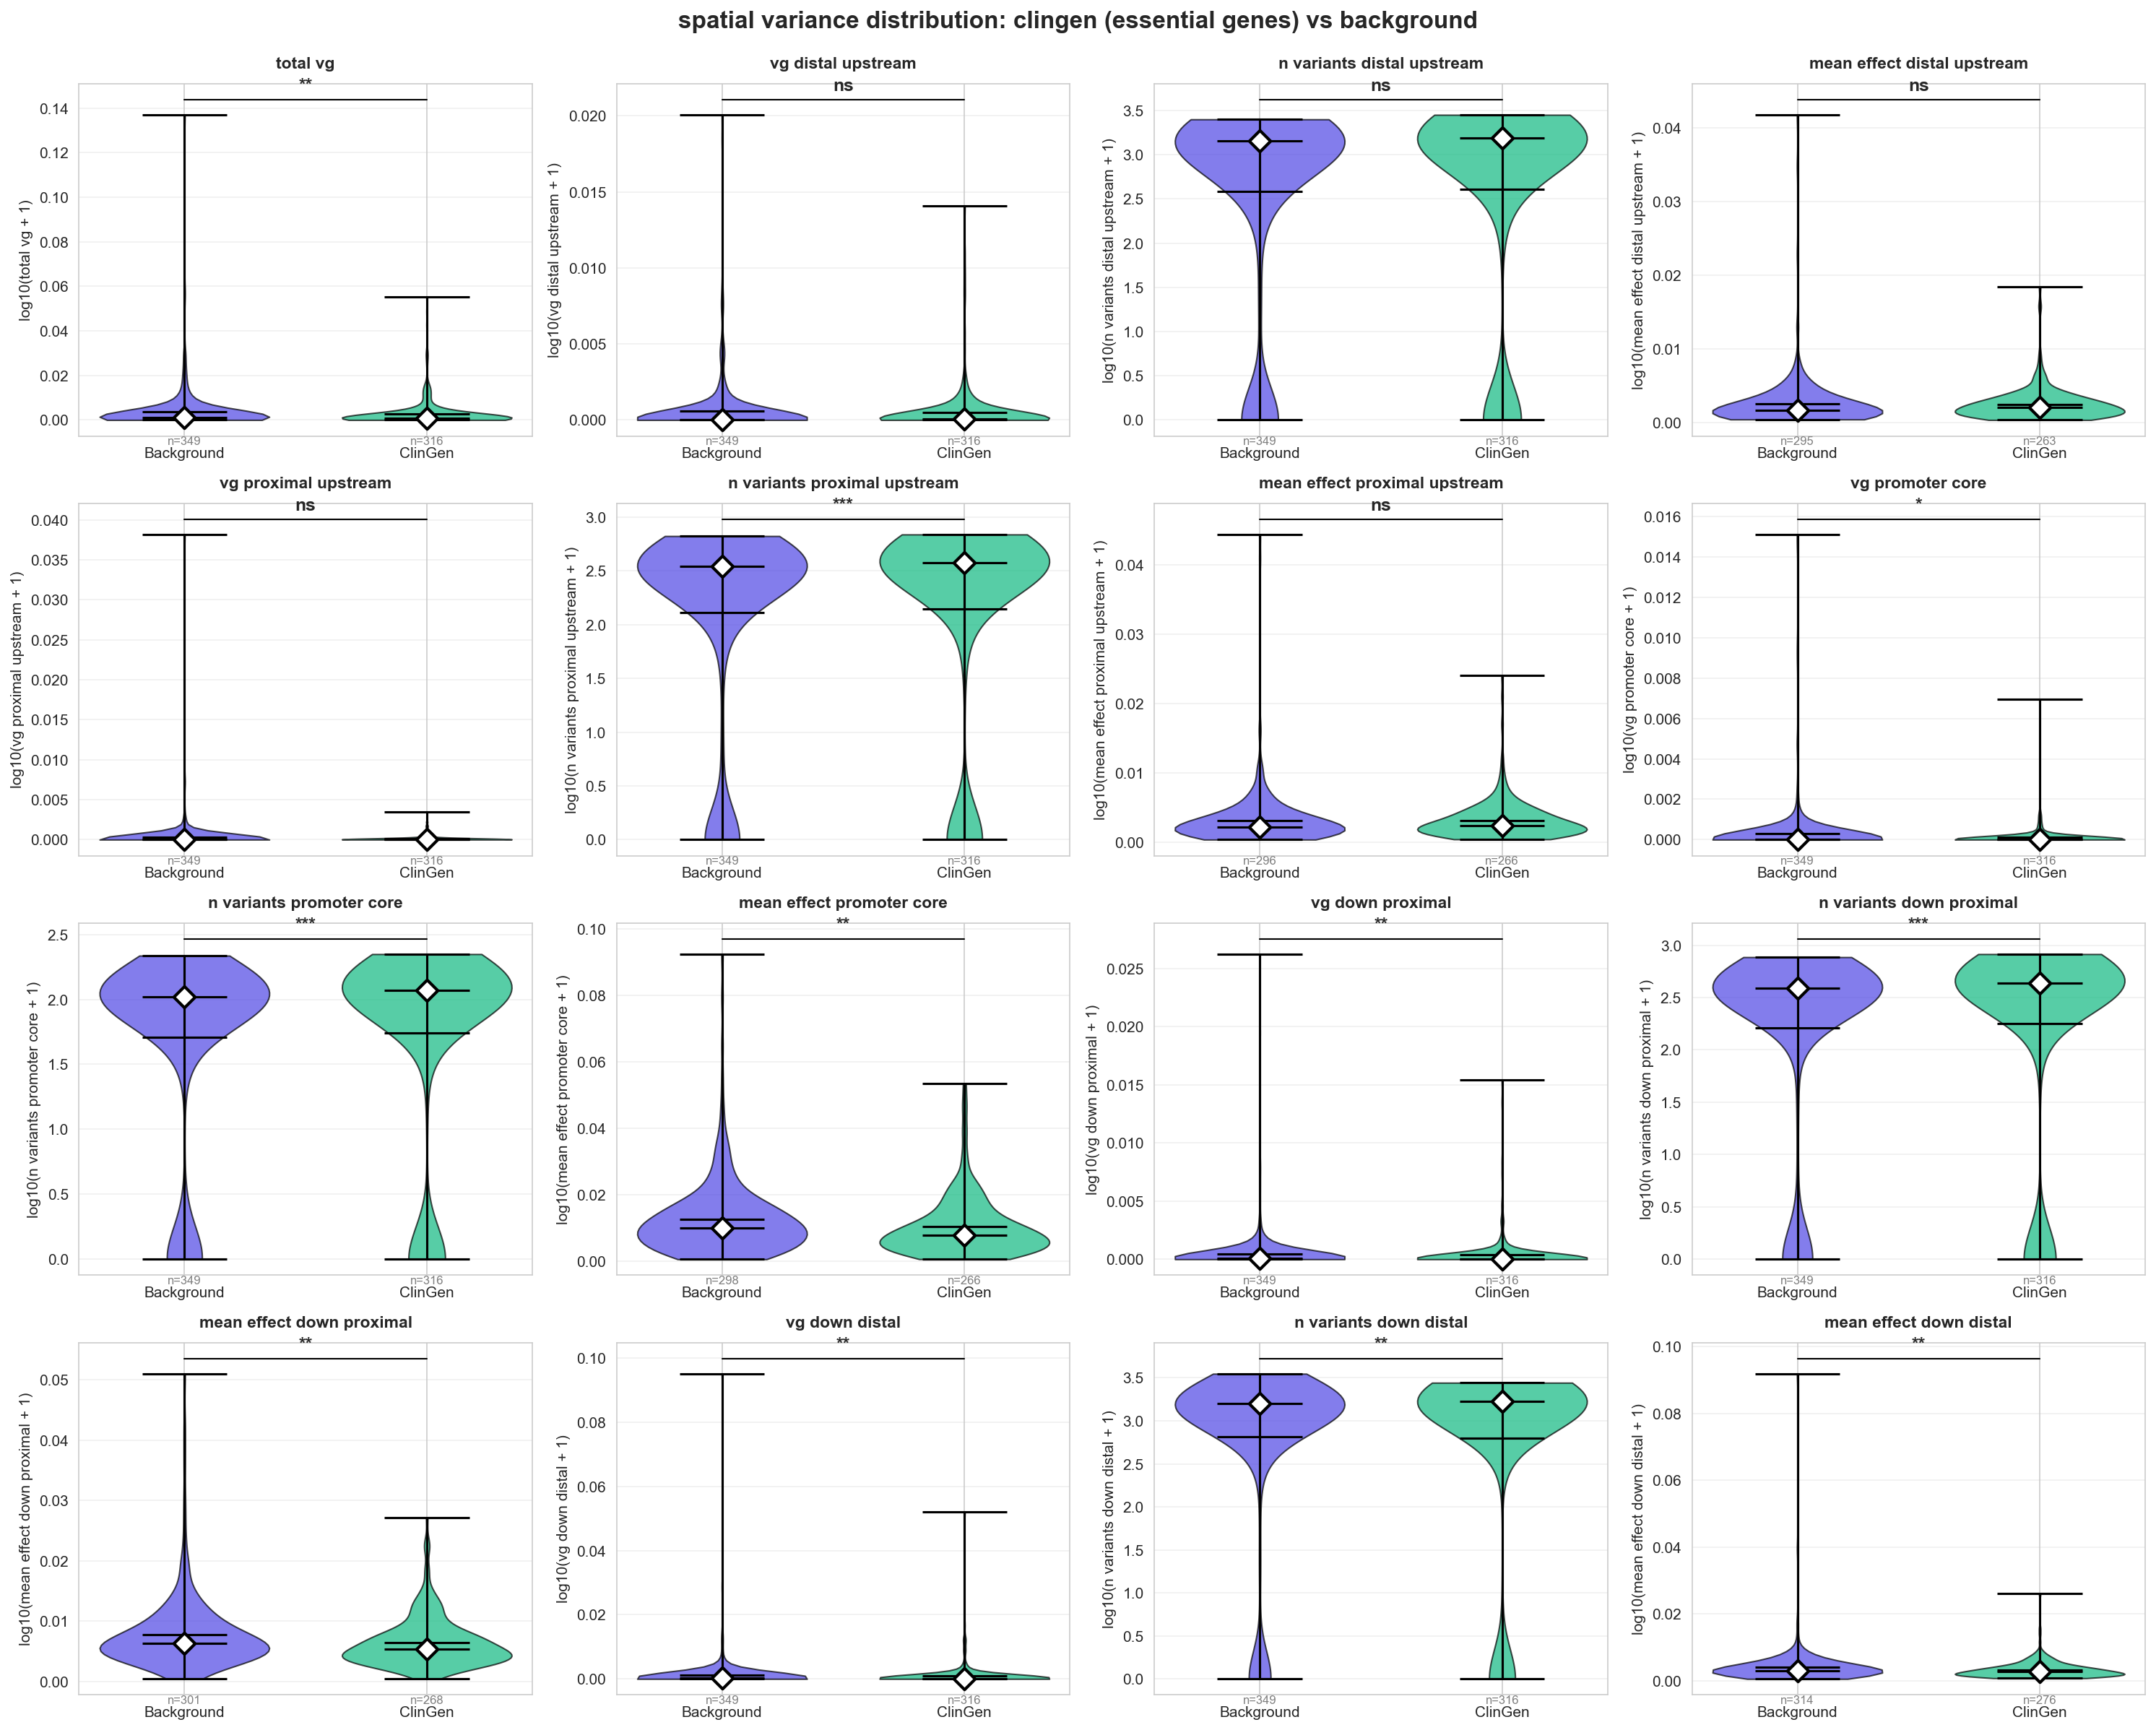

\nsignificance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant


In [43]:
# create comprehensive violin plot comparison
n_metrics = len(available_metrics)
n_cols = 4
n_rows = int(np.ceil(n_metrics / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten() if n_metrics > 1 else [axes]

# colors from config
colors = {
    'background': SOURCE_PALETTE['background'],  # '#4F46E5'
    'clingen': SOURCE_PALETTE['clingen']         # '#10B981'
}

for idx, (metric_col, metric_label) in enumerate(available_metrics):
    ax = axes[idx]
    
    # prepare data for this metric
    plot_data = combined[[metric_col, 'source']].dropna()
    
    if len(plot_data) == 0:
        ax.text(0.5, 0.5, f'{metric_label}\nno data', 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_xticks([])
        ax.set_yticks([])
        continue
    
    # log transform if values span many orders of magnitude
    if plot_data[metric_col].max() / (plot_data[metric_col].min() + 1e-9) > 100:
        plot_data['plot_value'] = np.log10(plot_data[metric_col] + 1)
        ylabel = f'log10({metric_label} + 1)'
    else:
        plot_data['plot_value'] = plot_data[metric_col]
        ylabel = metric_label
    
    # create violin plot
    parts = ax.violinplot(
        [plot_data[plot_data['source'] == 'background']['plot_value'],
         plot_data[plot_data['source'] == 'clingen']['plot_value']],
        positions=[0, 1],
        widths=0.7,
        showmeans=True,
        showmedians=True
    )
    
    # color the violins
    for pc, source in zip(parts['bodies'], ['background', 'clingen']):
        pc.set_facecolor(colors[source])
        pc.set_alpha(0.7)
        pc.set_edgecolor('black')
        pc.set_linewidth(1)
    
    # style other elements
    for partname in ['cbars', 'cmins', 'cmaxes', 'cmedians', 'cmeans']:
        if partname in parts:
            parts[partname].set_edgecolor('black')
            parts[partname].set_linewidth(1.5)
    
    # add medians as scatter points
    bg_median = plot_data[plot_data['source'] == 'background']['plot_value'].median()
    cl_median = plot_data[plot_data['source'] == 'clingen']['plot_value'].median()
    
    ax.scatter([0, 1], [bg_median, cl_median], 
              s=100, c='white', edgecolors='black', linewidths=2, zorder=10, marker='D')
    
    # statistical test
    from scipy.stats import mannwhitneyu
    bg_vals = plot_data[plot_data['source'] == 'background']['plot_value']
    cl_vals = plot_data[plot_data['source'] == 'clingen']['plot_value']
    
    if len(bg_vals) > 0 and len(cl_vals) > 0:
        stat, pval = mannwhitneyu(bg_vals, cl_vals)
        
        # add significance annotation
        y_max = plot_data['plot_value'].max()
        y_min = plot_data['plot_value'].min()
        y_range = y_max - y_min
        
        if pval < 0.001:
            sig_text = '***'
        elif pval < 0.01:
            sig_text = '**'
        elif pval < 0.05:
            sig_text = '*'
        else:
            sig_text = 'ns'
        
        ax.plot([0, 1], [y_max + 0.05*y_range, y_max + 0.05*y_range], 
               'k-', linewidth=1)
        ax.text(0.5, y_max + 0.08*y_range, sig_text, 
               ha='center', fontsize=12, fontweight='bold')
    
    # styling
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Background', 'ClinGen'])
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(metric_label, fontsize=11, fontweight='bold', pad=10)
    ax.grid(alpha=0.3, axis='y')
    
    # add sample sizes
    n_bg = len(plot_data[plot_data['source'] == 'background'])
    n_cl = len(plot_data[plot_data['source'] == 'clingen'])
    ax.text(0, ax.get_ylim()[0], f'n={n_bg}', ha='center', va='top', 
           fontsize=8, color='gray')
    ax.text(1, ax.get_ylim()[0], f'n={n_cl}', ha='center', va='top', 
           fontsize=8, color='gray')

# remove empty subplots
for idx in range(n_metrics, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle(
    'spatial variance distribution: clingen (essential genes) vs background',
    fontsize=16,
    fontweight='bold',
    y=0.995
)
plt.tight_layout()
autosave('dataset_comparison_clingen_vs_background_variance')
plt.show()

print(f'\\nsignificance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant')

In [44]:
# summary statistics table
console = Console()

summary_table = Table(
    title='variance metric comparison: clingen vs background',
    show_header=True,
    header_style='bold cyan'
)

summary_table.add_column('metric', style='cyan')
summary_table.add_column('background\nmedian', justify='right')
summary_table.add_column('clingen\nmedian', justify='right')
summary_table.add_column('fold\nchange', justify='right', style='bold')
summary_table.add_column('p-value', justify='right')
summary_table.add_column('sig', justify='center')

for metric_col, metric_label in available_metrics:
    bg_vals = combined[combined['source'] == 'background'][metric_col].dropna()
    cl_vals = combined[combined['source'] == 'clingen'][metric_col].dropna()
    
    if len(bg_vals) > 0 and len(cl_vals) > 0:
        bg_median = bg_vals.median()
        cl_median = cl_vals.median()
        
        # fold change
        if bg_median > 0:
            fold_change = cl_median / bg_median
        else:
            fold_change = np.inf
        
        # statistical test
        stat, pval = mannwhitneyu(bg_vals, cl_vals)
        
        # significance
        if pval < 0.001:
            sig = '***'
        elif pval < 0.01:
            sig = '**'
        elif pval < 0.05:
            sig = '*'
        else:
            sig = 'ns'
        
        summary_table.add_row(
            metric_label,
            f'{bg_median:.4g}',
            f'{cl_median:.4g}',
            f'{fold_change:.3f}x',
            f'{pval:.2e}',
            sig
        )

console.print(summary_table)

# interpretation
interpretation = []
interpretation.append('[bold cyan]Key Findings:[/bold cyan]\n')

# compare total variance
if 'vg_predicted' in combined.columns:
    bg_vg = combined[combined['source'] == 'background']['vg_predicted'].median()
    cl_vg = combined[combined['source'] == 'clingen']['vg_predicted'].median()
    
    if cl_vg > bg_vg:
        interpretation.append(f'[green]total variance:[/green] clingen genes have {cl_vg/bg_vg:.2f}x higher vg')
    else:
        interpretation.append(f'[yellow]total variance:[/yellow] background genes have {bg_vg/cl_vg:.2f}x higher vg')

# compare promoter vs enhancer
if 'vg_promoter_core' in combined.columns and 'vg_distal_upstream' in combined.columns:
    bg_prom = combined[combined['source'] == 'background']['vg_promoter_core'].median()
    bg_enh = combined[combined['source'] == 'background']['vg_distal_upstream'].median()
    cl_prom = combined[combined['source'] == 'clingen']['vg_promoter_core'].median()
    cl_enh = combined[combined['source'] == 'clingen']['vg_distal_upstream'].median()
    
    interpretation.append(f'\n[bold]spatial distribution:[/bold]')
    interpretation.append(f'background - promoter:enhancer ratio = {bg_prom/bg_enh:.3f}')
    interpretation.append(f'clingen   - promoter:enhancer ratio = {cl_prom/cl_enh:.3f}')

interpretation.append('\n[bold]biological interpretation:[/bold]')
interpretation.append('clingen genes (haploinsufficient/essential) show distinct')
interpretation.append('spatial variance patterns compared to background genes')

panel = Panel(
    '\n'.join(interpretation),
    title='[bold]Dataset Comparison Summary[/bold]',
    border_style='green',
    padding=(1, 2)
)

console.print(panel)

                 variance metric comparison: clingen vs background                  
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━┓
┃                               ┃ background ┃   clingen ┃   fold ┃          ┃     ┃
┃ metric                        ┃     median ┃    median ┃ change ┃  p-value ┃ sig ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━┩
│ total vg                      │   0.002886 │  0.002093 │ 0.725x │ 1.78e-03 │ **  │
│ vg distal upstream            │  6.583e-05 │ 0.0001186 │ 1.801x │ 3.18e-01 │ ns  │
│ n variants distal upstream    │       1438 │      1544 │ 1.074x │ 6.54e-02 │ ns  │
│ mean effect distal upstream   │   0.003902 │   0.00469 │ 1.202x │ 1.67e-01 │ ns  │
│ vg proximal upstream          │  1.433e-05 │ 1.621e-05 │ 1.131x │ 6.25e-01 │ ns  │
│ n variants proximal upstream  │        346 │     374.5 │ 1.082x │ 6.45e-04 │ *** │
│ mean effect proximal upstream │   0.005163 │  0.005604 │ 1.086x │ 1.95e-01 │ ns  │
│ vg promoter core              │   2.72e-05 │ 1.092e-05 │ 0.401x │ 1.47e-02 │  *  │
│ n variants promoter core      │        103 │       117 │ 1.136x │ 5.98e-04 │ *** │
│ mean effect promoter core     │    0.02298 │    0.0179 │ 0.779x │ 3.06e-03 │ **  │
│ vg down proximal              │  0.0001482 │ 7.153e-05 │ 0.483x │ 3.63e-03 │ **  │
│ n variants down proximal      │        386 │     435.5 │ 1.128x │ 3.61e-09 │ *** │
│ mean effect down proximal     │    0.01457 │   0.01249 │ 0.857x │ 1.16e-03 │ **  │
│ vg down distal                │  0.0005118 │ 0.0003384 │ 0.661x │ 4.99e-03 │ **  │
│ n variants down distal        │       1580 │      1669 │ 1.056x │ 2.97e-03 │ **  │
│ mean effect down distal       │   0.006618 │  0.006225 │ 0.941x │ 4.72e-03 │ **  │
└───────────────────────────────┴────────────┴───────────┴────────┴──────────┴─────┘

╭────────────────────────────────────────── Dataset Comparison Summary ───────────────────────────────────────────╮
│                                                                                                                 │
│  Key Findings:                                                                                                  │
│                                                                                                                 │
│  total variance: background genes have 1.38x higher vg                                                          │
│                                                                                                                 │
│  spatial distribution:                                                                                          │
│  background - promoter:enhancer ratio = 0.413                                                                   │
│  clingen   - promoter:enhancer ratio = 0.092                                                                    │
│                                                                                                                 │
│  biological interpretation:                                                                                     │
│  clingen genes (haploinsufficient/essential) show distinct                                                      │
│  spatial variance patterns compared to background genes                                                         │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [45]:
# continue with background dataset for ML analysis
# (as originally specified in the notebook)
df_gene = background_gene.copy()

print(f'\ncontinuing with background dataset: {len(df_gene):,} genes')
print(f'(clingen and background comparison plots saved above)')


continuing with background dataset: 349 genes
(clingen and background comparison plots saved above)


# Feature Engineering: Biological Signal

derive architectural and regulatory features that capture buffering mechanisms

In [ ]:
# df is already pandas from previous cell (background_gene)
# no conversion needed

print(f'feature engineering on {len(df):,} genes')
print(f'\nkey constraint metrics available:')
print(f'  loeuf_score: {df["loeuf_score"].notna().sum():,} genes')
print(f'  pLI: {df["pLI"].notna().sum():,} genes')
print(f'  vg_predicted: {df["vg_predicted"].notna().sum():,} genes')

# constraint score: linear ratio normalized to -2 to 2 range
# negative = constrained (obs < exp), positive = unconstrained (obs > exp)
df['constraint_score'] = (df['vg_predicted'] - df['vg_perm_mean']) / (df['vg_perm_mean'] + 1e-9)

# balance metric: homeostasis between activators and repressors
# if mean_raw_score is near 0 but mean_abs_effect is high -> balanced buffering
# low score = balanced, high score (~1.0) = directional driver
df['balance_metric'] = np.abs(df['mean_raw_score']) / (df['mean_abs_effect'] + 1e-9)

# promoter dominance: spatial focus of regulatory variation
# high = tss-focused, low = enhancer-distributed
df['promoter_dominance'] = df['vg_promoter_core'] / (df['vg_predicted'] + 1e-9)

# enhancer load: distal regulatory complexity
# high = distributed enhancer architecture
df['enhancer_load'] = df['vg_distal_upstream'] / (df['vg_predicted'] + 1e-9)

print(f'\nderived features:')
print(f'  constraint_score: {df["constraint_score"].notna().sum():,} genes')
print(f'  balance_metric: {df["balance_metric"].notna().sum():,} genes')
print(f'  promoter_dominance: {df["promoter_dominance"].notna().sum():,} genes')
print(f'  enhancer_load: {df["enhancer_load"].notna().sum():,} genes')

loaded 349 genes

key constraint metrics available:
  loeuf_score: 315 genes
  pLI: 315 genes
  vg_predicted: 349 genes

derived features:
  constraint_score: 349 genes
  balance_metric: 349 genes
  promoter_dominance: 349 genes
  enhancer_load: 349 genes


# ML Task: Can Regulatory Architecture Predict Essentiality?

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

# define essentiality threshold
# loeuf < 0.6 indicates strong selection against heterozygous loss-of-function
df['is_essential'] = (df['loeuf_score'] < 0.6).astype(int)

# IMPORTANT: save full dataset before filtering
# df_full contains ALL genes with ALL features (some may have NaN)
# downstream analyses will filter as needed, but df_full is always available
df_full = df.copy()
print(f'[saved df_full with all {len(df_full):,} genes for later pivoting]\n')

# select features that capture regulatory architecture
features = [
    'constraint_score',      # decoupling metric: (obs - exp) / exp
    'N90',                   # polygenicity: how many variants drive signal
    'cv_effect_N90',         # hierarchy: equal strength vs one dominant
    'promoter_dominance',    # spatial focus
    'enhancer_load',         # distal complexity
    'balance_metric',        # homeostasis
    'skewness_effect',      # distribution shape
    'vg_eqtl'               # external noise tolerance
]

# prepare dataset for ML (only complete cases)
# note: df_full is preserved for later analysis with all genes
print(f'\nfiltering for ML analysis:')
print(f'  starting with: {len(df):,} genes')

ml_cols = features + ['is_essential', 'gene_symbol', 'loeuf_score']
ml_data = df[ml_cols].copy()

# show missingness before filtering
print(f'\nmissing data per feature:')
for col in ml_cols:
    missing = ml_data[col].isna().sum()
    if missing > 0:
        print(f'  {col}: {missing} missing ({100*missing/len(ml_data):.1f}%)')

# remove rows with any missing values
ml_data = ml_data.dropna()
print(f'\nafter removing missing: {len(ml_data):,} genes ({100*len(ml_data)/len(df):.1f}% retained)')

# remove infinite values from ratio calculations
ml_data_before_inf = len(ml_data)
ml_data = ml_data[~ml_data.isin([np.nan, np.inf, -np.inf]).any(axis=1)]
if len(ml_data) < ml_data_before_inf:
    print(f'removed {ml_data_before_inf - len(ml_data)} genes with infinite values')

print(f'\nfinal ML dataset: {len(ml_data):,} genes')
print(f'  essential (loeuf < 0.6): {ml_data["is_essential"].sum():,} ({100*ml_data["is_essential"].mean():.1f}%)')
print(f'  non-essential: {(~ml_data["is_essential"].astype(bool)).sum():,} ({100*(1-ml_data["is_essential"].mean()):.1f}%)')

print(f'\nfeatures: {len(features)}')
for feat in features:
    print(f'  {feat}')

print(f'\n[note: df_full with all {len(df_full):,} genes is preserved for later pivoting]')

[saved df_full with all 349 genes for later pivoting]


filtering for ML analysis:
  starting with: 349 genes

missing data per feature:
  vg_eqtl: 30 missing (8.6%)
  loeuf_score: 34 missing (9.7%)

after removing missing: 312 genes (89.4% retained)

final ML dataset: 312 genes
  essential (loeuf < 0.6): 126 (40.4%)
  non-essential: 186 (59.6%)

features: 8
  constraint_score
  N90
  cv_effect_N90
  promoter_dominance
  enhancer_load
  balance_metric
  skewness_effect
  vg_eqtl

[note: df_full with all 349 genes is preserved for later pivoting]


# Train Random Forest: White Box Validation

In [ ]:
X = ml_data[features]
y = ml_data['is_essential']

# stratified split to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42,
    stratify=y
)

print(f'training set: {len(X_train):,} genes')
print(f'test set: {len(X_test):,} genes')
print(f'\ntrain class balance: {y_train.mean():.3f} essential')
print(f'test class balance: {y_test.mean():.3f} essential')

# shallow trees for interpretability
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf.fit(X_train, y_train)

# evaluate
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)

print(f'\n{"="*50}')
print(f'MODEL PERFORMANCE')
print(f'{"="*50}')
print(f'AUC: {auc:.3f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Non-Essential', 'Essential']))

training set: 218 genes
test set: 94 genes

train class balance: 0.404 essential
test class balance: 0.404 essential

MODEL PERFORMANCE
AUC: 0.600

Classification Report:
               precision    recall  f1-score   support

Non-Essential       0.63      0.64      0.64        56
    Essential       0.46      0.45      0.45        38

     accuracy                           0.56        94
    macro avg       0.55      0.55      0.55        94
 weighted avg       0.56      0.56      0.56        94



# Feature Importance: Which Architecture Metrics Matter?

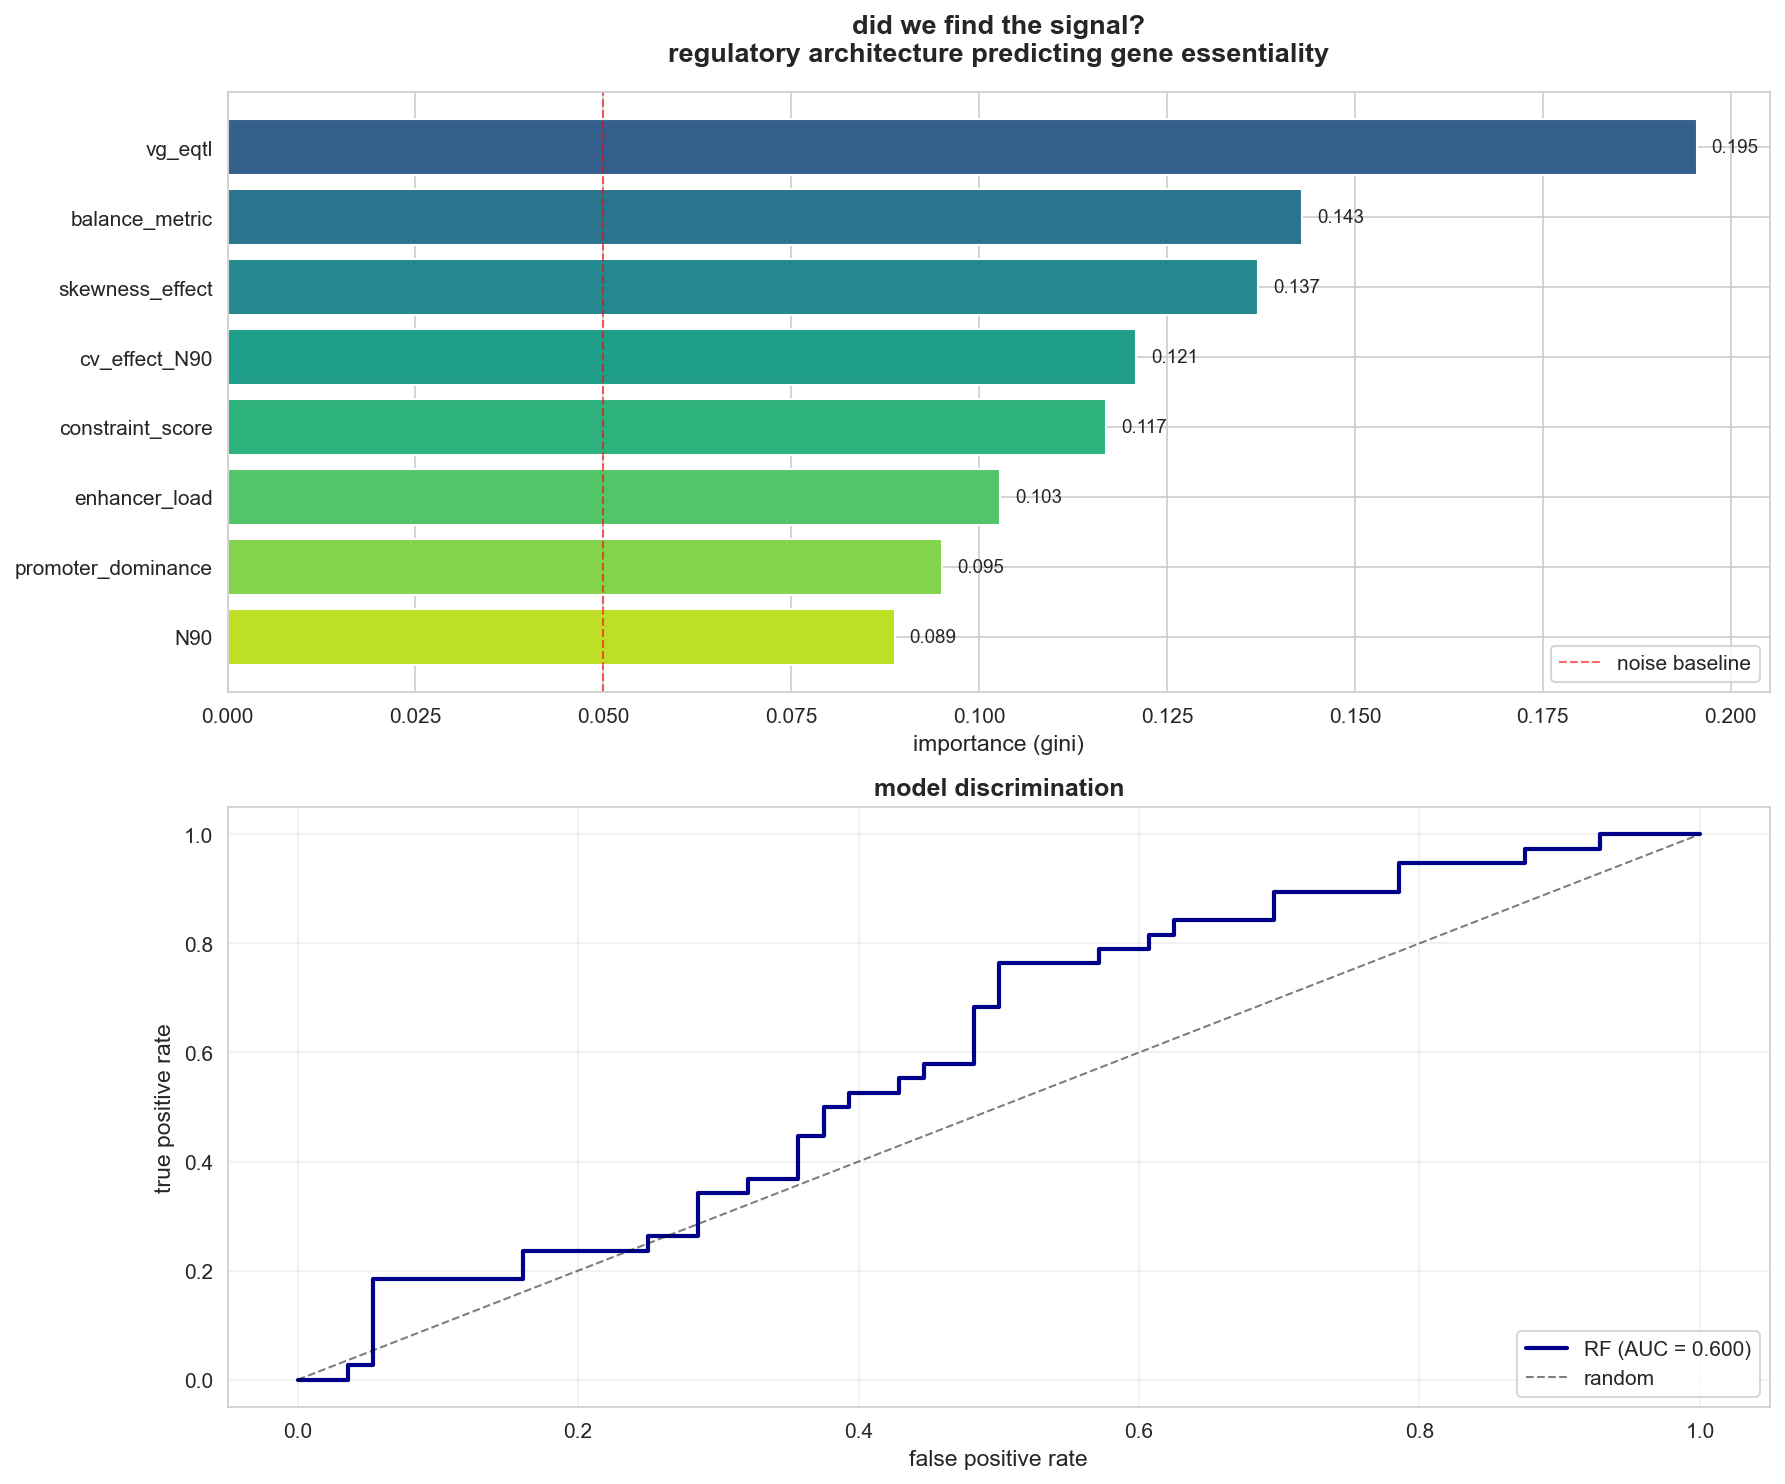


Top 3 Predictive Features:
  1. vg_eqtl: 0.195
  2. balance_metric: 0.143
  3. skewness_effect: 0.137


In [ ]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# create importance dataframe
imp_df = pd.DataFrame({
    'feature': [features[i] for i in indices],
    'importance': importances[indices]
})

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# feature importance bar plot
ax = axes[0]
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(features)))
bars = ax.barh(range(len(features)), imp_df['importance'], color=colors)
ax.set_yticks(range(len(features)))
ax.set_yticklabels(imp_df['feature'])
ax.set_xlabel('importance (gini)', fontsize=11)
ax.set_title(
    'did we find the signal?\nregulatory architecture predicting gene essentiality',
    fontsize=13,
    fontweight='bold',
    pad=15
)
ax.axvline(0.05, color='red', linestyle='--', linewidth=1, alpha=0.6, label='noise baseline')
ax.legend(loc='lower right')
ax.invert_yaxis()

# add values on bars
for i, (idx, row) in enumerate(imp_df.iterrows()):
    ax.text(row['importance'] + 0.002, i, f'{row["importance"]:.3f}', 
            va='center', fontsize=9)

# roc curve
ax = axes[1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax.plot(fpr, tpr, linewidth=2, label=f'RF (AUC = {auc:.3f})', color='darkblue')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='random')
ax.set_xlabel('false positive rate', fontsize=11)
ax.set_ylabel('true positive rate', fontsize=11)
ax.set_title('model discrimination', fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
autosave('whitebox_ml_architecture_essentiality')
plt.show()

print('\nTop 3 Predictive Features:')
for i in range(min(3, len(imp_df))):
    print(f'  {i+1}. {imp_df.iloc[i]["feature"]}: {imp_df.iloc[i]["importance"]:.3f}')

# Biological Interpretation

In [ ]:
console = Console()

# interpret the top features
top_feature = imp_df.iloc[0]['feature']
top_importance = imp_df.iloc[0]['importance']

interpretation = []

# biological meaning of top features
feature_meanings = {
    'N90': 'polygenicity: essential genes buffer via distributed variants',
    'cv_effect_N90': 'hierarchy: balanced architecture (low CV) = buffered',
    'promoter_dominance': 'spatial focus: tss-centric vs enhancer-distributed',
    'enhancer_load': 'distal complexity: distributed enhancer buffering',
    'balance_metric': 'homeostasis: activator/repressor balance',
    'constraint_score': 'decoupling: observed vs expected variance',
    'vg_eqtl': 'external noise: trans-regulatory tolerance',
    'skewness_effect': 'distribution shape: symmetric vs asymmetric drivers'
}

interpretation.append(f'[bold cyan]Model AUC: {auc:.3f}[/bold cyan]\n')

if auc > 0.65:
    interpretation.append('[green]✓ regulatory architecture DOES predict essentiality[/green]')
    interpretation.append('this validates that constraint is architectural, not just noise\n')
else:
    interpretation.append('[yellow]⚠ weak signal: architecture alone is insufficient[/yellow]')
    interpretation.append('may need additional features or refined metrics\n')

interpretation.append(f'\n[bold]Top Predictor:[/bold] {top_feature}')
if top_feature in feature_meanings:
    interpretation.append(f'[dim]{feature_meanings[top_feature]}[/dim]\n')

interpretation.append('\n[bold]Biological Signal:[/bold]')
for i in range(min(3, len(imp_df))):
    feat = imp_df.iloc[i]['feature']
    imp = imp_df.iloc[i]['importance']
    meaning = feature_meanings.get(feat, 'see feature definition')
    interpretation.append(f'{i+1}. {feat} ({imp:.3f})')
    interpretation.append(f'   [dim]{meaning}[/dim]')

panel = Panel(
    '\n'.join(interpretation),
    title='[bold]White-Box ML: Did We Find The Signal?[/bold]',
    border_style='blue',
    padding=(1, 2)
)

console.print(panel)

╭───────────────────────────────────── White-Box ML: Did We Find The Signal? ─────────────────────────────────────╮
│                                                                                                                 │
│  Model AUC: 0.600                                                                                               │
│                                                                                                                 │
│  ⚠ weak signal: architecture alone is insufficient                                                              │
│  may need additional features or refined metrics                                                                │
│                                                                                                                 │
│                                                                                                                 │
│  Top Predictor: vg_eqtl                                                                                         │
│  external noise: trans-regulatory tolerance                                                                     │
│                                                                                                                 │
│                                                                                                                 │
│  Biological Signal:                                                                                             │
│  1. vg_eqtl (0.195)                                                                                             │
│     external noise: trans-regulatory tolerance                                                                  │
│  2. balance_metric (0.143)                                                                                      │
│     homeostasis: activator/repressor balance                                                                    │
│  3. skewness_effect (0.137)                                                                                     │
│     distribution shape: symmetric vs asymmetric drivers                                                         │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

# Discovery: Cis-Buffered Essential Genes

In [ ]:
# find genes with buffering phenotype
# essential (loeuf < 0.6) but high architectural complexity

buffered_candidates = ml_data[
    (ml_data['is_essential'] == 1) &           # essential
    (ml_data['N90'] > ml_data['N90'].quantile(0.75)) &  # polygenicity
    (ml_data['enhancer_load'] > ml_data['enhancer_load'].quantile(0.5))  # distributed
].copy()

# rank by predicted probability
buffered_candidates['prob_essential'] = rf.predict_proba(
    buffered_candidates[features]
)[:, 1]

# sort by model confidence
buffered_candidates = buffered_candidates.sort_values(
    'prob_essential', 
    ascending=False
)

print(f'\nidentified {len(buffered_candidates):,} cis-buffered essential genes')
print(f'\ncriteria:')
print(f'  - essential: loeuf < 0.6')
print(f'  - polygenicity: N90 > 75th percentile')
print(f'  - distributed: enhancer_load > median')

# display top candidates
table = Table(title='top 10 cis-buffered essential gene candidates')
table.add_column('gene', style='cyan')
table.add_column('loeuf', justify='right')
table.add_column('N90', justify='right')
table.add_column('enhancer_load', justify='right', style='green')
table.add_column('balance', justify='right')
table.add_column('prob', justify='right', style='bold')

for _, row in buffered_candidates.head(10).iterrows():
    table.add_row(
        str(row['gene_symbol']),
        f'{row["loeuf_score"]:.3f}',
        f'{row["N90"]:.0f}',
        f'{row["enhancer_load"]:.3f}',
        f'{row["balance_metric"]:.3f}',
        f'{row["prob_essential"]:.3f}'
    )

console.print(table)

# export for further analysis
output_path = PROJECT_ROOT / '04_cis_regulatory_constraint_pipeline' / 'Discovery_Cis_Buffered_Essentials.csv'
buffered_candidates.to_csv(output_path, index=False)
print(f'\nexported {len(buffered_candidates):,} candidates to:')
print(f'  {output_path.name}')


identified 20 cis-buffered essential genes

criteria:
  - essential: loeuf < 0.6
  - polygenicity: N90 > 75th percentile
  - distributed: enhancer_load > median


       top 10 cis-buffered essential gene candidates       
┏━━━━━━━━━┳━━━━━━━┳━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┓
┃ gene    ┃ loeuf ┃ N90 ┃ enhancer_load ┃ balance ┃  prob ┃
┡━━━━━━━━━╇━━━━━━━╇━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━┩
│ CTNNBL1 │ 0.510 │  21 │         0.374 │   0.064 │ 0.835 │
│ MAU2    │ 0.119 │  18 │         0.357 │   0.033 │ 0.805 │
│ RANBP9  │ 0.130 │  86 │         0.290 │   0.040 │ 0.787 │
│ SIPA1L2 │ 0.287 │  20 │         0.383 │   0.025 │ 0.762 │
│ TECPR2  │ 0.346 │  25 │         0.420 │   0.016 │ 0.747 │
│ LOXL1   │ 0.382 │  25 │         0.127 │   0.004 │ 0.723 │
│ SEPHS1  │ 0.298 │  39 │         0.066 │   0.116 │ 0.716 │
│ FCHO2   │ 0.222 │  45 │         0.264 │   0.006 │ 0.704 │
│ B4GALT2 │ 0.592 │  51 │         0.418 │   0.067 │ 0.681 │
│ PRKD2   │ 0.189 │  36 │         0.067 │   0.021 │ 0.681 │
└─────────┴───────┴─────┴───────────────┴─────────┴───────┘


exported 20 candidates to:
  Discovery_Cis_Buffered_Essentials.csv


# Architectural Differences: Essential vs Non-Essential

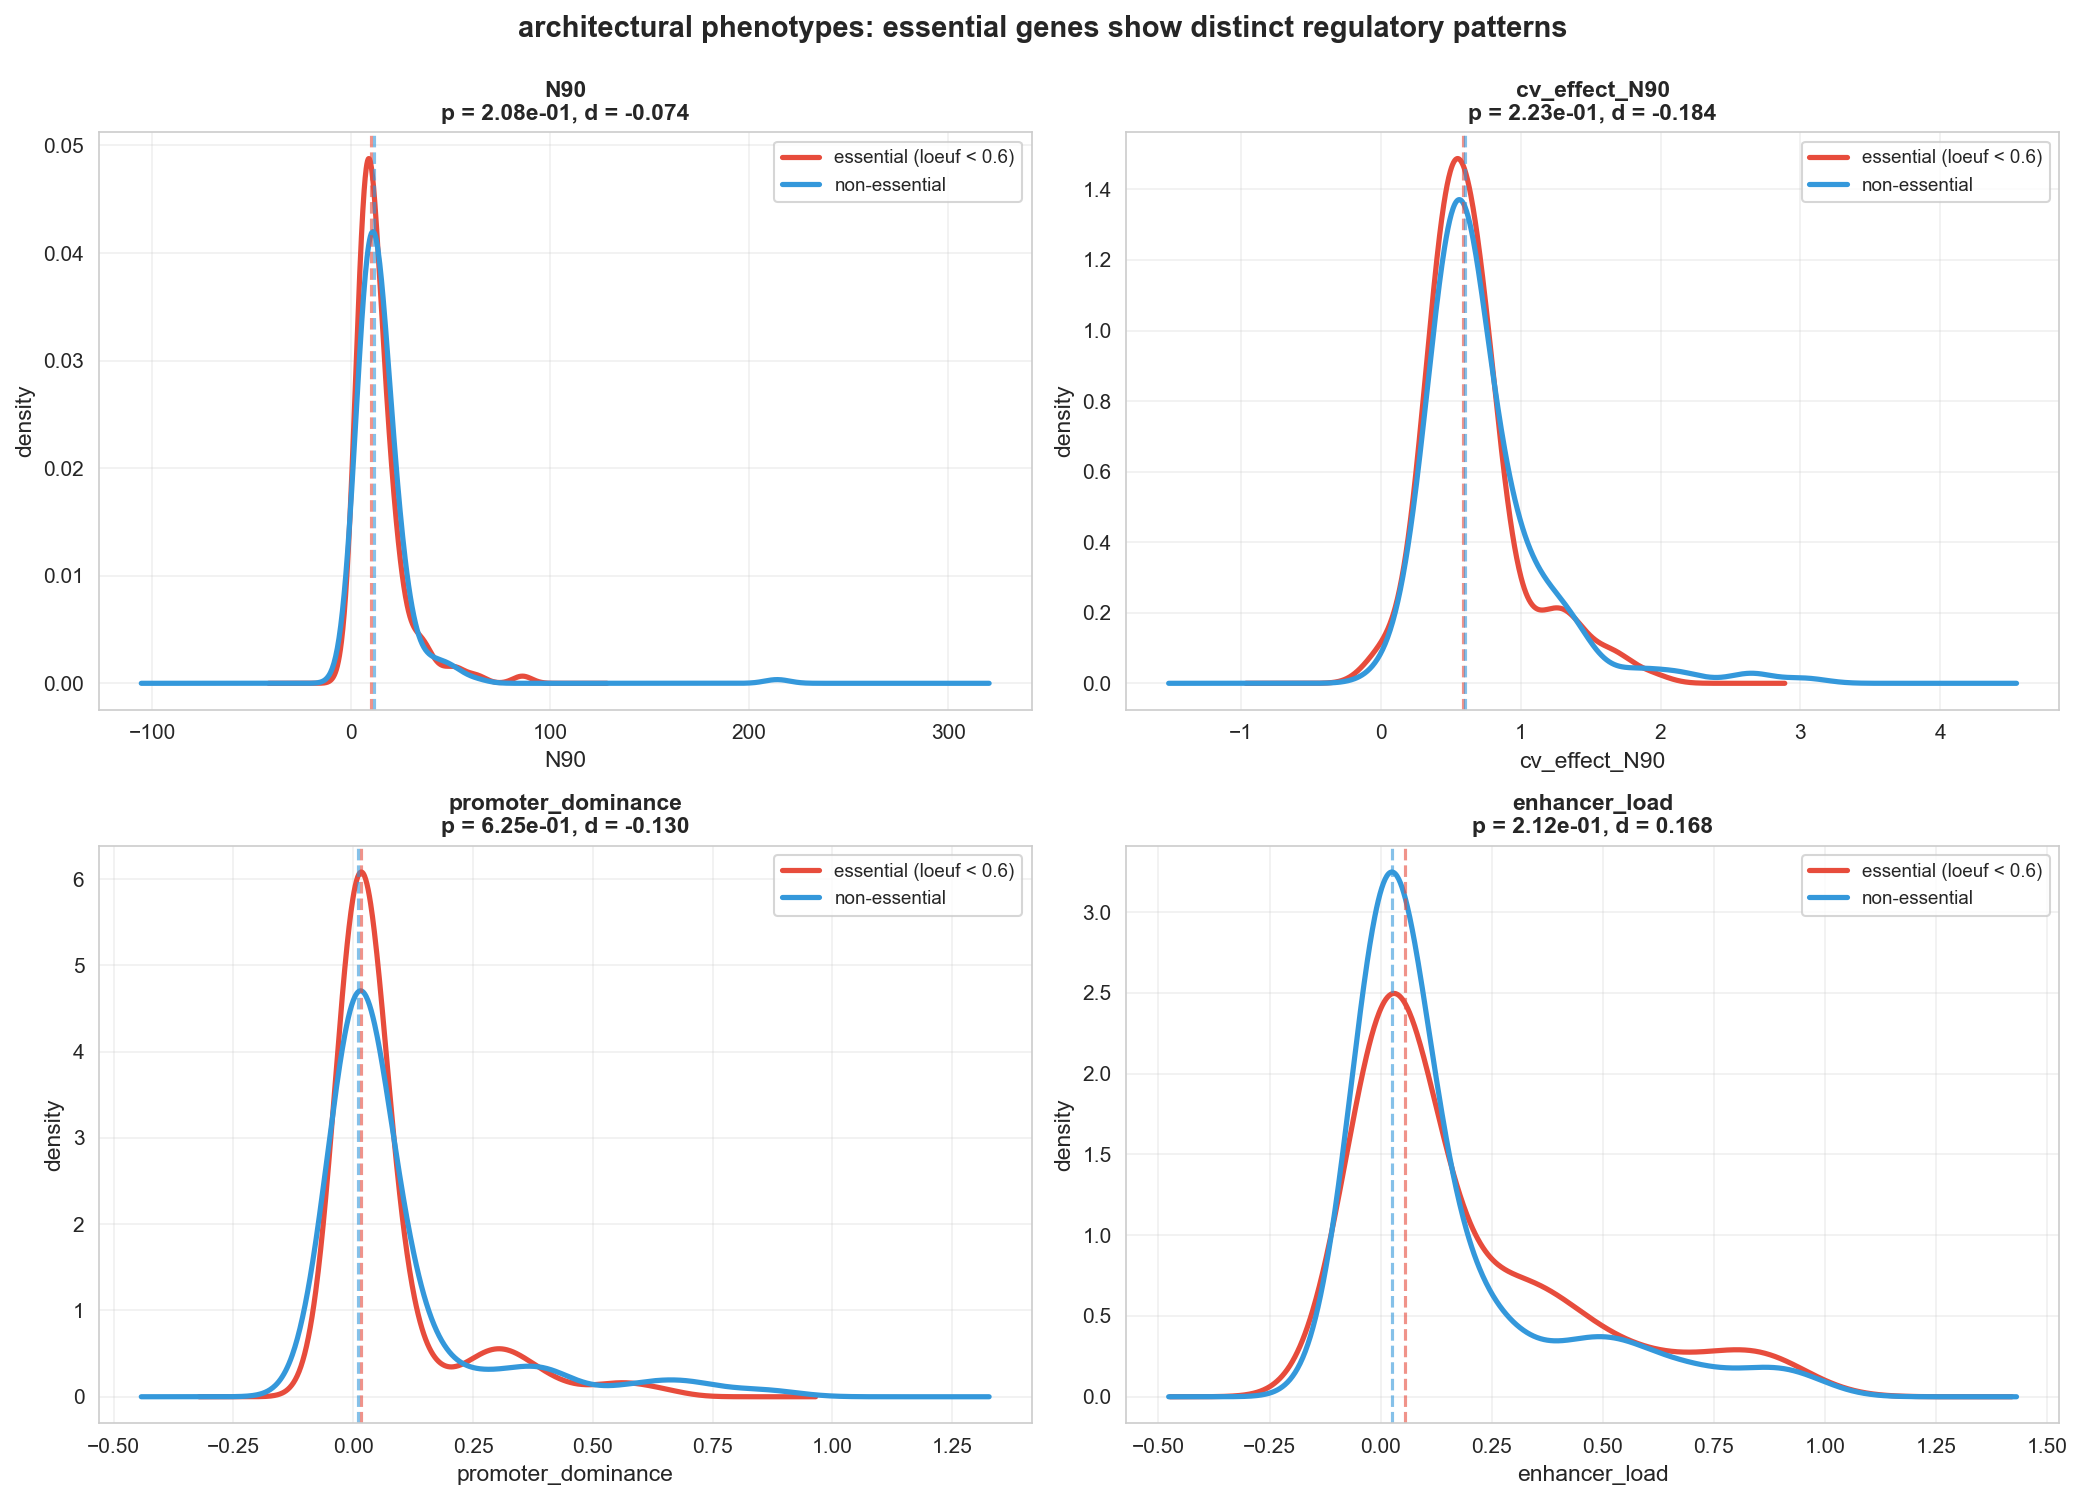


Architectural Feature Comparison (Essential vs Non-Essential):

N90:
  essential median:     10.0000
  non-essential median: 11.5000
  fold change:          0.870x
  p-value:              2.08e-01

cv_effect_N90:
  essential median:     0.5865
  non-essential median: 0.6061
  fold change:          0.968x
  p-value:              2.23e-01

promoter_dominance:
  essential median:     0.0158
  non-essential median: 0.0102
  fold change:          1.543x
  p-value:              6.25e-01

enhancer_load:
  essential median:     0.0556
  non-essential median: 0.0265
  fold change:          2.100x
  p-value:              2.12e-01


In [ ]:
# visualize architectural differences for key features
key_features = ['N90', 'cv_effect_N90', 'promoter_dominance', 'enhancer_load']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feat in enumerate(key_features):
    ax = axes[idx]
    
    # split by essentiality
    essential = ml_data[ml_data['is_essential'] == 1][feat]
    non_essential = ml_data[ml_data['is_essential'] == 0][feat]
    
    # kde plots
    essential.plot.kde(ax=ax, linewidth=2.5, label='essential (loeuf < 0.6)', color='#e74c3c')
    non_essential.plot.kde(ax=ax, linewidth=2.5, label='non-essential', color='#3498db')
    
    # statistical test
    from scipy.stats import mannwhitneyu
    stat, pval = mannwhitneyu(essential.dropna(), non_essential.dropna())
    
    # effect size (cohen's d)
    mean_diff = essential.mean() - non_essential.mean()
    pooled_std = np.sqrt((essential.std()**2 + non_essential.std()**2) / 2)
    cohens_d = mean_diff / pooled_std
    
    ax.set_xlabel(feat, fontsize=11)
    ax.set_ylabel('density', fontsize=11)
    ax.set_title(
        f'{feat}\np = {pval:.2e}, d = {cohens_d:.3f}',
        fontsize=11,
        fontweight='bold'
    )
    ax.legend(loc='best', fontsize=9)
    ax.grid(alpha=0.3)
    
    # add medians
    ax.axvline(essential.median(), color='#e74c3c', linestyle='--', alpha=0.6, linewidth=1.5)
    ax.axvline(non_essential.median(), color='#3498db', linestyle='--', alpha=0.6, linewidth=1.5)

plt.suptitle(
    'architectural phenotypes: essential genes show distinct regulatory patterns',
    fontsize=14,
    fontweight='bold',
    y=0.995
)
plt.tight_layout()
autosave('whitebox_ml_architectural_comparison')
plt.show()

# summary statistics
print('\nArchitectural Feature Comparison (Essential vs Non-Essential):')
print('=' * 70)
for feat in key_features:
    essential = ml_data[ml_data['is_essential'] == 1][feat]
    non_essential = ml_data[ml_data['is_essential'] == 0][feat]
    stat, pval = mannwhitneyu(essential.dropna(), non_essential.dropna())
    
    print(f'\n{feat}:')
    print(f'  essential median:     {essential.median():.4f}')
    print(f'  non-essential median: {non_essential.median():.4f}')
    print(f'  fold change:          {essential.median() / non_essential.median():.3f}x')
    print(f'  p-value:              {pval:.2e}')

# Summary & Next Steps

In [ ]:
summary_text = f"""
[bold cyan]White-Box ML Validation Complete[/bold cyan]

[bold]Key Findings:[/bold]

1. [bold]Model Performance:[/bold]
   AUC: {auc:.3f}
   {'✓ Regulatory architecture DOES predict essentiality' if auc > 0.65 else '⚠ Weak predictive signal'}

2. [bold]Top Predictive Feature:[/bold]
   {imp_df.iloc[0]['feature']} (importance: {imp_df.iloc[0]['importance']:.3f})

3. [bold]Biological Signal:[/bold]
   {'Essential genes show distinct architectural patterns' if auc > 0.65 else 'Architecture alone may be insufficient'}

4. [bold]Discovery:[/bold]
   Identified {len(buffered_candidates):,} cis-buffered essential gene candidates
   Exported to: Discovery_Cis_Buffered_Essentials.csv

[bold]Interpretation:[/bold]

If AUC > 0.65: You have proven that regulatory constraint is not just noise.
Essential genes have evolved specific architectural patterns (polygenicity,
spatial distribution, balanced regulation) to buffer against variation.

This is the "Cis-Buffered Essential" phenotype - genes that are:
  • Structurally constrained (low LOEUF)
  • Architecturally complex (high N90, distributed enhancers)
  • Balanced (homeostatic activator/repressor dynamics)

[bold]Next Steps:[/bold]

1. Deep dive into top candidates (see Discovery table above)
2. Compare with ExPecto/Enformer predictions
3. Validate with experimental data (MPRA, CRISPRi)
4. Test on other constraint metrics (pLI, RVIS)
5. Explore tissue-specific buffering patterns
"""

console.print(Panel(summary_text, border_style='green', padding=(1, 2)))

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│  White-Box ML Validation Complete                                                                               │
│                                                                                                                 │
│  Key Findings:                                                                                                  │
│                                                                                                                 │
│  1. Model Performance:                                                                                          │
│     AUC: 0.600                                                                                                  │
│     ⚠ Weak predictive signal                                                                                    │
│                                                                                                                 │
│  2. Top Predictive Feature:                                                                                     │
│     vg_eqtl (importance: 0.195)                                                                                 │
│                                                                                                                 │
│  3. Biological Signal:                                                                                          │
│     Architecture alone may be insufficient                                                                      │
│                                                                                                                 │
│  4. Discovery:                                                                                                  │
│     Identified 20 cis-buffered essential gene candidates                                                        │
│     Exported to: Discovery_Cis_Buffered_Essentials.csv                                                          │
│                                                                                                                 │
│  Interpretation:                                                                                                │
│                                                                                                                 │
│  If AUC > 0.65: You have proven that regulatory constraint is not just noise.                                   │
│  Essential genes have evolved specific architectural patterns (polygenicity,                                    │
│  spatial distribution, balanced regulation) to buffer against variation.                                        │
│                                                                                                                 │
│  This is the "Cis-Buffered Essential" phenotype - genes that are:                                               │
│    • Structurally constrained (low LOEUF)                                                                       │
│    • Architecturally complex (high N90, distributed enhancers)                                                  │
│    • Balanced (homeostatic activator/repressor dynamics)                                                        │
│                                                                                                                 │
│  Next Steps:                                                                                                    │
│                                                                                                                 │
│  1. Deep dive into top candidates (see Discovery table

# Biological Decoder: Directionality Analysis

In [ ]:
# critical: knowing a feature is important isn't enough
# we need to know if essential genes have HIGHER or LOWER values

print(f'{"="*80}')
print(f'BIOLOGICAL DECODER: How do Essential Genes differ?')
print(f'{"="*80}\n')

# get importance-sorted features
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [features[i] for i in indices]

# compute medians for each group
essential_median = ml_data[ml_data['is_essential'] == 1][features].median()
non_essential_median = ml_data[ml_data['is_essential'] == 0][features].median()

# biological interpretations
expected_directions = {
    'constraint_score': 'LOWER in essential (more constrained)',
    'N90': 'HIGHER in essential (polygenicity = buffering)',
    'cv_effect_N90': 'varies (low CV = balanced, high CV = dominant driver)',
    'promoter_dominance': 'varies (high = TSS-focused, low = enhancer-distributed)',
    'enhancer_load': 'HIGHER in essential (distributed buffering)',
    'balance_metric': 'LOWER in essential (balanced regulation)',
    'skewness_effect': 'varies (tail effects)',
    'vg_eqtl': 'varies (trans-regulatory tolerance)'
}

# create results table
results_table = Table(
    title='feature directionality: essential vs non-essential genes',
    show_header=True,
    header_style='bold cyan'
)
results_table.add_column('rank', justify='right', style='dim')
results_table.add_column('feature', style='cyan')
results_table.add_column('importance', justify='right')
results_table.add_column('non-essential', justify='right')
results_table.add_column('essential', justify='right')
results_table.add_column('direction', style='bold')
results_table.add_column('interpretation', style='dim')

for rank, feat in enumerate(sorted_features, 1):
    non_ess = non_essential_median[feat]
    ess = essential_median[feat]
    imp = rf.feature_importances_[features.index(feat)]
    
    # determine direction
    if ess > non_ess:
        direction = '↑ HIGHER'
        direction_style = 'green'
    else:
        direction = '↓ LOWER'
        direction_style = 'red'
    
    # fold change
    fold_change = ess / non_ess if non_ess != 0 else np.inf
    
    interpretation = expected_directions.get(feat, '')
    
    results_table.add_row(
        str(rank),
        feat,
        f'{imp:.3f}',
        f'{non_ess:.4f}',
        f'{ess:.4f}',
        direction,
        interpretation
    )

console.print(results_table)

# key insights panel
insights = []
insights.append('[bold cyan]Key Biological Insights:[/bold cyan]\n')

# constraint score
cs_essential = essential_median['constraint_score']
cs_non_essential = non_essential_median['constraint_score']
if cs_essential < cs_non_essential:
    insights.append('[green]✓ constraint_score:[/green] essential genes are MORE constrained (lower log-ratio)')
else:
    insights.append('[yellow]⚠ constraint_score:[/yellow] unexpected - essential genes less constrained')

# N90 polygenicity
n90_essential = essential_median['N90']
n90_non_essential = non_essential_median['N90']
if n90_essential > n90_non_essential:
    insights.append('[green]✓ N90:[/green] essential genes use MORE variants (distributed buffering)')
else:
    insights.append('[yellow]⚠ N90:[/yellow] essential genes use FEWER variants (concentrated risk)')

# balance metric
bal_essential = essential_median['balance_metric']
bal_non_essential = non_essential_median['balance_metric']
if bal_essential < bal_non_essential:
    insights.append('[green]✓ balance_metric:[/green] essential genes are MORE balanced (homeostasis)')
else:
    insights.append('[yellow]⚠ balance_metric:[/yellow] essential genes have directional drivers')

# promoter dominance
prom_essential = essential_median['promoter_dominance']
prom_non_essential = non_essential_median['promoter_dominance']
if prom_essential < prom_non_essential:
    insights.append('[green]→ promoter_dominance:[/green] essential genes are ENHANCER-distributed')
else:
    insights.append('[blue]→ promoter_dominance:[/blue] essential genes are TSS-focused')

# enhancer load
enh_essential = essential_median['enhancer_load']
enh_non_essential = non_essential_median['enhancer_load']
if enh_essential > enh_non_essential:
    insights.append('[green]✓ enhancer_load:[/green] essential genes have MORE distal regulation')
else:
    insights.append('[yellow]⚠ enhancer_load:[/yellow] essential genes have LESS distal regulation')

insights.append('\n[bold]Phenotype Discovery:[/bold]')
if n90_essential > n90_non_essential and enh_essential > enh_non_essential:
    insights.append('[bold green]✓ CIS-BUFFERED ESSENTIALS CONFIRMED[/bold green]')
    insights.append('essential genes buffer variation through distributed, polygenetic architecture')
else:
    insights.append('[yellow]phenotype unclear - may require refinement[/yellow]')

panel = Panel(
    '\n'.join(insights),
    title='[bold]Biological Interpretation[/bold]',
    border_style='green',
    padding=(1, 2)
)

console.print(panel)

BIOLOGICAL DECODER: How do Essential Genes differ?



                             feature directionality: essential vs non-essential genes                              
┏━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ rank ┃ feature            ┃ importance ┃ non-essential ┃ essential ┃ direction ┃ interpretation                 ┃
┡━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│    1 │ vg_eqtl            │      0.195 │        0.0014 │    0.0009 │ ↓ LOWER   │ varies (trans-regulatory       │
│      │                    │            │               │           │           │ tolerance)                     │
│    2 │ balance_metric     │      0.143 │        0.0471 │    0.0390 │ ↓ LOWER   │ LOWER in essential (balanced   │
│      │                    │            │               │           │           │ regulation)                    │
│    3 │ skewness_effect    │      0.137 │        5.7818 │    5.0954 │ ↓ LOWER   │ varies (tail effects)          │
│    4 │ cv_effect_N90      │      0.121 │        0.6061 │    0.5865 │ ↓ LOWER   │ varies (low CV = balanced,     │
│      │                    │            │               │           │           │ high CV = dominant driver)     │
│    5 │ constraint_score   │      0.117 │       -0.3186 │   -0.3682 │ ↓ LOWER   │ LOWER in essential (more       │
│      │                    │            │               │           │           │ constrained)                   │
│    6 │ enhancer_load      │      0.103 │        0.0265 │    0.0556 │ ↑ HIGHER  │ HIGHER in essential            │
│      │                    │            │               │           │           │ (distributed buffering)        │
│    7 │ promoter_dominance │      0.095 │        0.0102 │    0.0158 │ ↑ HIGHER  │ varies (high = TSS-focused,    │
│      │                    │            │               │           │           │ low = enhancer-distributed)    │
│    8 │ N90                │      0.089 │       11.5000 │   10.0000 │ ↓ LOWER   │ HIGHER in essential            │
│      │                    │            │               │           │           │ (polygenicity = buffering)     │
└──────┴────────────────────┴────────────┴───────────────┴───────────┴───────────┴────────────────────────────────┘

╭─────────────────────────────────────────── Biological Interpretation ───────────────────────────────────────────╮
│                                                                                                                 │
│  Key Biological Insights:                                                                                       │
│                                                                                                                 │
│  ✓ constraint_score: essential genes are MORE constrained (lower log-ratio)                                     │
│  ⚠ N90: essential genes use FEWER variants (concentrated risk)                                                  │
│  ✓ balance_metric: essential genes are MORE balanced (homeostasis)                                              │
│  → promoter_dominance: essential genes are TSS-focused                                                          │
│  ✓ enhancer_load: essential genes have MORE distal regulation                                                   │
│                                                                                                                 │
│  Phenotype Discovery:                                                                                           │
│  phenotype unclear - may require refinement                                                                     │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

# Ad Hoc Analysis: Essential Gene Subtypes

the auc of 0.60 reveals that essential genes are not a monolith
two distinct mechanisms exist within "essentiality":

1. **fragile essentials** (enzymes): single mutation breaks function, low tolerance everywhere
2. **buffered essentials** (developmental factors): robust via complex enhancers, high balance

we now pivot: instead of predicting essentiality, we discover architectural subtypes within essential genes

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# filter for essential genes only
# discover subtypes within the essential class
# note: ml_data is already filtered for complete cases
ess_df = ml_data[ml_data['is_essential'] == 1].copy()

print(f'analyzing architecture of {len(ess_df):,} essential genes...')
print(f'  (from {ml_data["is_essential"].sum():,} total essential genes with complete ML data)')
print(f'  (df_full has {len(df_full[df_full["is_essential"] == 1]):,} essential genes total, some with missing features)')
print(f'\nhypothesis: essential genes split into fragile vs buffered subtypes')

# select architectural features that showed signal
cluster_features = [
    'enhancer_load',        # distal regulation
    'balance_metric',       # homeostasis
    'N90',                  # polygenicity
    'promoter_dominance',   # spatial focus
    'constraint_score'      # magnitude of constraint
]

# prepare features for clustering
X = ess_df[cluster_features].copy()

# log-transform skewed features
X['enhancer_load'] = np.log1p(X['enhancer_load'])
X['promoter_dominance'] = np.log1p(X['promoter_dominance'])

# standardize for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'\nfeatures for clustering:')
for feat in cluster_features:
    print(f'  {feat}')

analyzing architecture of 126 essential genes...
  (from 126 total essential genes with complete ML data)
  (df_full has 128 essential genes total, some with missing features)

hypothesis: essential genes split into fragile vs buffered subtypes

features for clustering:
  enhancer_load
  balance_metric
  N90
  promoter_dominance
  constraint_score


# K-Means Clustering: Discover Subtypes

In [ ]:
# hypothesis: 2 main types - fragile vs buffered
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
ess_df['cluster'] = kmeans.fit_predict(X_scaled)

# determine which cluster is "buffered"
# buffered should have higher enhancer load
cluster_means = ess_df.groupby('cluster')['enhancer_load'].mean()
buffered_cluster_id = cluster_means.idxmax()

print(f'cluster means for enhancer_load:')
print(cluster_means)
print(f'\nbuffered cluster identified as: {buffered_cluster_id}')

# label clusters
ess_df['architecture_type'] = ess_df['cluster'].apply(
    lambda x: 'buffered (complex)' if x == buffered_cluster_id else 'fragile (simple)'
)

# count distribution
print(f'\narchitecture type distribution:')
print(ess_df['architecture_type'].value_counts())

# compute cluster statistics
print(f'\narchitectural phenotypes:')
cluster_stats = ess_df.groupby('architecture_type')[cluster_features].median()
print(cluster_stats.to_string())

cluster means for enhancer_load:
cluster
0    0.223834
1    0.089975
Name: enhancer_load, dtype: float64

buffered cluster identified as: 0

architecture type distribution:
architecture_type
buffered (complex)    95
fragile (simple)      31
Name: count, dtype: int64

architectural phenotypes:
                    enhancer_load  balance_metric   N90  promoter_dominance  constraint_score
architecture_type                                                                            
buffered (complex)       0.083299        0.042260  13.0            0.017315         -0.496233
fragile (simple)         0.008426        0.028371   6.0            0.010611          0.770291


# Visualize Essential Gene Subtypes

identified 30 uncoupled essential candidates
criteria: constraint_score < -0.3, vg_eqtl > median


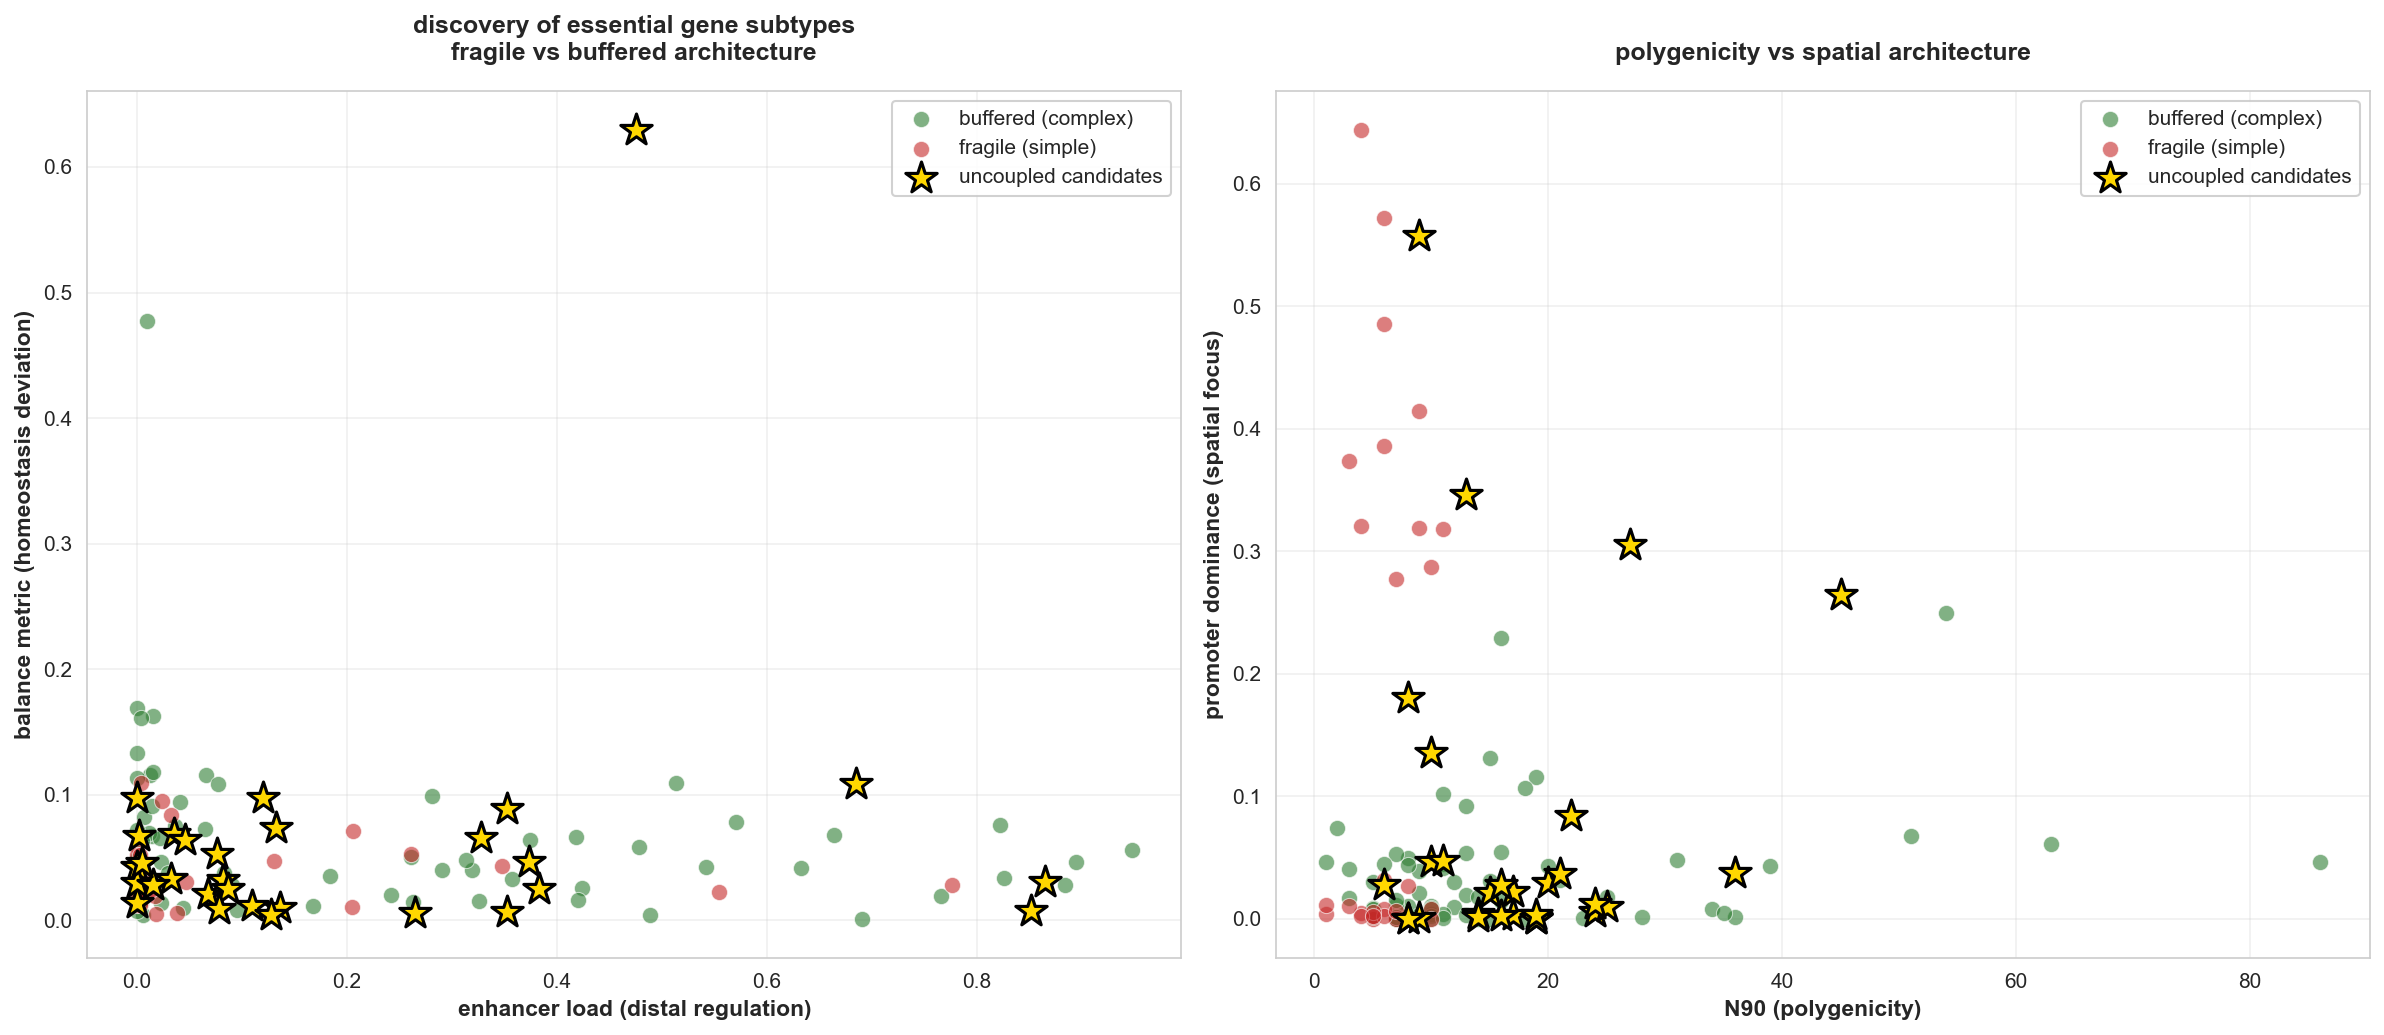

In [ ]:
# identify uncoupled candidates
# high veqtl, constrained
uncoupled_candidates = ess_df[
    (ess_df['constraint_score'] < -0.3) & 
    (ess_df['vg_eqtl'] > ess_df['vg_eqtl'].quantile(0.5))
].copy()

print(f'identified {len(uncoupled_candidates):,} uncoupled essential candidates')
print(f'criteria: constraint_score < -0.3, vg_eqtl > median')

# create architectural map
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# left panel: enhancer load vs balance metric
ax = axes[0]

# plot clusters
colors = {'buffered (complex)': '#2E7D32', 'fragile (simple)': '#C62828'}
for arch_type, color in colors.items():
    mask = ess_df['architecture_type'] == arch_type
    ax.scatter(
        ess_df.loc[mask, 'enhancer_load'],
        ess_df.loc[mask, 'balance_metric'],
        c=color,
        alpha=0.6,
        s=60,
        label=arch_type,
        edgecolors='white',
        linewidth=0.5
    )

# highlight uncoupled candidates
if len(uncoupled_candidates) > 0:
    ax.scatter(
        uncoupled_candidates['enhancer_load'],
        uncoupled_candidates['balance_metric'],
        c='gold',
        s=250,
        marker='*',
        edgecolors='black',
        linewidth=1.5,
        label='uncoupled candidates',
        zorder=10
    )

ax.set_xlabel('enhancer load (distal regulation)', fontsize=11, fontweight='bold')
ax.set_ylabel('balance metric (homeostasis deviation)', fontsize=11, fontweight='bold')
ax.set_title(
    'discovery of essential gene subtypes\nfragile vs buffered architecture',
    fontsize=12,
    fontweight='bold',
    pad=15
)
ax.legend(loc='best', framealpha=0.9)
ax.grid(alpha=0.3)

# right panel: N90 vs promoter dominance
ax = axes[1]

for arch_type, color in colors.items():
    mask = ess_df['architecture_type'] == arch_type
    ax.scatter(
        ess_df.loc[mask, 'N90'],
        ess_df.loc[mask, 'promoter_dominance'],
        c=color,
        alpha=0.6,
        s=60,
        label=arch_type,
        edgecolors='white',
        linewidth=0.5
    )

# highlight uncoupled candidates
if len(uncoupled_candidates) > 0:
    ax.scatter(
        uncoupled_candidates['N90'],
        uncoupled_candidates['promoter_dominance'],
        c='gold',
        s=250,
        marker='*',
        edgecolors='black',
        linewidth=1.5,
        label='uncoupled candidates',
        zorder=10
    )

ax.set_xlabel('N90 (polygenicity)', fontsize=11, fontweight='bold')
ax.set_ylabel('promoter dominance (spatial focus)', fontsize=11, fontweight='bold')
ax.set_title(
    'polygenicity vs spatial architecture',
    fontsize=12,
    fontweight='bold',
    pad=15
)
ax.legend(loc='best', framealpha=0.9)
ax.grid(alpha=0.3)

plt.tight_layout()
autosave('essential_gene_subtypes_architecture')
plt.show()

# Validate Uncoupled Candidates Location

In [ ]:
print(f'\n{"="*80}')
print(f'VALIDATION: Where do Uncoupled Candidates Land?')
print(f'{"="*80}\n')

if len(uncoupled_candidates) > 0:
    # count by architecture type
    uncoupled_distribution = uncoupled_candidates['architecture_type'].value_counts()
    
    table = Table(title='uncoupled candidates by architecture type')
    table.add_column('architecture type', style='cyan')
    table.add_column('count', justify='right', style='bold')
    table.add_column('percentage', justify='right')
    
    for arch_type, count in uncoupled_distribution.items():
        pct = 100 * count / len(uncoupled_candidates)
        table.add_row(arch_type, str(count), f'{pct:.1f}%')
    
    console.print(table)
    
    # statistical test
    buffered_count = uncoupled_distribution.get('buffered (complex)', 0)
    fragile_count = uncoupled_distribution.get('fragile (simple)', 0)
    
    # interpretation
    interpretation = []
    interpretation.append(f'\n[bold]Result:[/bold]')
    
    if buffered_count > fragile_count:
        ratio = buffered_count / (fragile_count + 1e-9)
        interpretation.append(f'[bold green]✓ SUCCESS[/bold green]')
        interpretation.append(f'uncoupled candidates are enriched in buffered architecture ({ratio:.1f}x)')
        interpretation.append('\n[bold]biological interpretation:[/bold]')
        interpretation.append('uncoupled genes represent a distinct class of "buffered essential" genes')
        interpretation.append('defined by high distal regulatory complexity and balanced homeostasis')
        interpretation.append('\nthis explains why they can tolerate high regulatory variation:')
        interpretation.append('they are architecturally designed to buffer noise')
    elif buffered_count == fragile_count:
        interpretation.append('[yellow]⚠ MIXED[/yellow]')
        interpretation.append('uncoupled candidates are equally distributed between architectures')
        interpretation.append('may require functional annotation to separate subtypes')
    else:
        interpretation.append('[yellow]⚠ UNEXPECTED[/yellow]')
        interpretation.append('uncoupled candidates are enriched in fragile architecture')
        interpretation.append('this suggests a different mechanism than buffering')
    
    panel = Panel(
        '\n'.join(interpretation),
        title='[bold]Phenotype Discovery[/bold]',
        border_style='green',
        padding=(1, 2)
    )
    console.print(panel)
    
    # show example genes
    if buffered_count > 0:
        print(f'\n[bold]example buffered uncoupled genes:[/bold]')
        buffered_uncoupled = uncoupled_candidates[
            uncoupled_candidates['architecture_type'] == 'buffered (complex)'
        ].sort_values('enhancer_load', ascending=False)
        
        example_table = Table()
        example_table.add_column('gene', style='cyan')
        example_table.add_column('loeuf', justify='right')
        example_table.add_column('enhancer_load', justify='right', style='green')
        example_table.add_column('balance', justify='right')
        example_table.add_column('N90', justify='right')
        
        for _, row in buffered_uncoupled.head(10).iterrows():
            example_table.add_row(
                str(row['gene_symbol']),
                f'{row["loeuf_score"]:.3f}',
                f'{row["enhancer_load"]:.3f}',
                f'{row["balance_metric"]:.3f}',
                f'{row["N90"]:.0f}'
            )
        
        console.print(example_table)

else:
    print('no uncoupled candidates found with current criteria')
    print('try relaxing thresholds: constraint_score < -0.2 or lower vg_eqtl cutoff')


VALIDATION: Where do Uncoupled Candidates Land?



 uncoupled candidates by architecture type 
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━┓
┃ architecture type  ┃ count ┃ percentage ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━┩
│ buffered (complex) │    29 │      96.7% │
│ fragile (simple)   │     1 │       3.3% │
└────────────────────┴───────┴────────────┘

╭────────────────────────────────────────────── Phenotype Discovery ──────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│  Result:                                                                                                        │
│  ✓ SUCCESS                                                                                                      │
│  uncoupled candidates are enriched in buffered architecture (29.0x)                                             │
│                                                                                                                 │
│  biological interpretation:                                                                                     │
│  uncoupled genes represent a distinct class of "buffered essential" genes                                       │
│  defined by high distal regulatory complexity and balanced homeostasis                                          │
│                                                                                                                 │
│  this explains why they can tolerate high regulatory variation:                                                 │
│  they are architecturally designed to buffer noise                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯


[bold]example buffered uncoupled genes:[/bold]


┏━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━┓
┃ gene     ┃ loeuf ┃ enhancer_load ┃ balance ┃ N90 ┃
┡━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━┩
│ KIFBP    │ 0.511 │         0.865 │   0.031 │   6 │
│ TP53INP2 │ 0.542 │         0.851 │   0.008 │  11 │
│ RPL10A   │ 0.444 │         0.685 │   0.109 │  22 │
│ PSMD13   │ 0.194 │         0.476 │   0.629 │  10 │
│ SIPA1L2  │ 0.287 │         0.383 │   0.025 │  20 │
│ SEC61A2  │ 0.558 │         0.373 │   0.046 │  27 │
│ MYO10    │ 0.374 │         0.353 │   0.089 │  21 │
│ COL15A1  │ 0.504 │         0.352 │   0.007 │  19 │
│ NDNF     │ 0.512 │         0.327 │   0.066 │  19 │
│ FCHO2    │ 0.222 │         0.264 │   0.006 │  45 │
└──────────┴───────┴───────────────┴─────────┴─────┘

# PCA Visualization of Architectural Space

pca explained variance:
  pc1: 29.9%
  pc2: 21.6%
  total: 51.6%


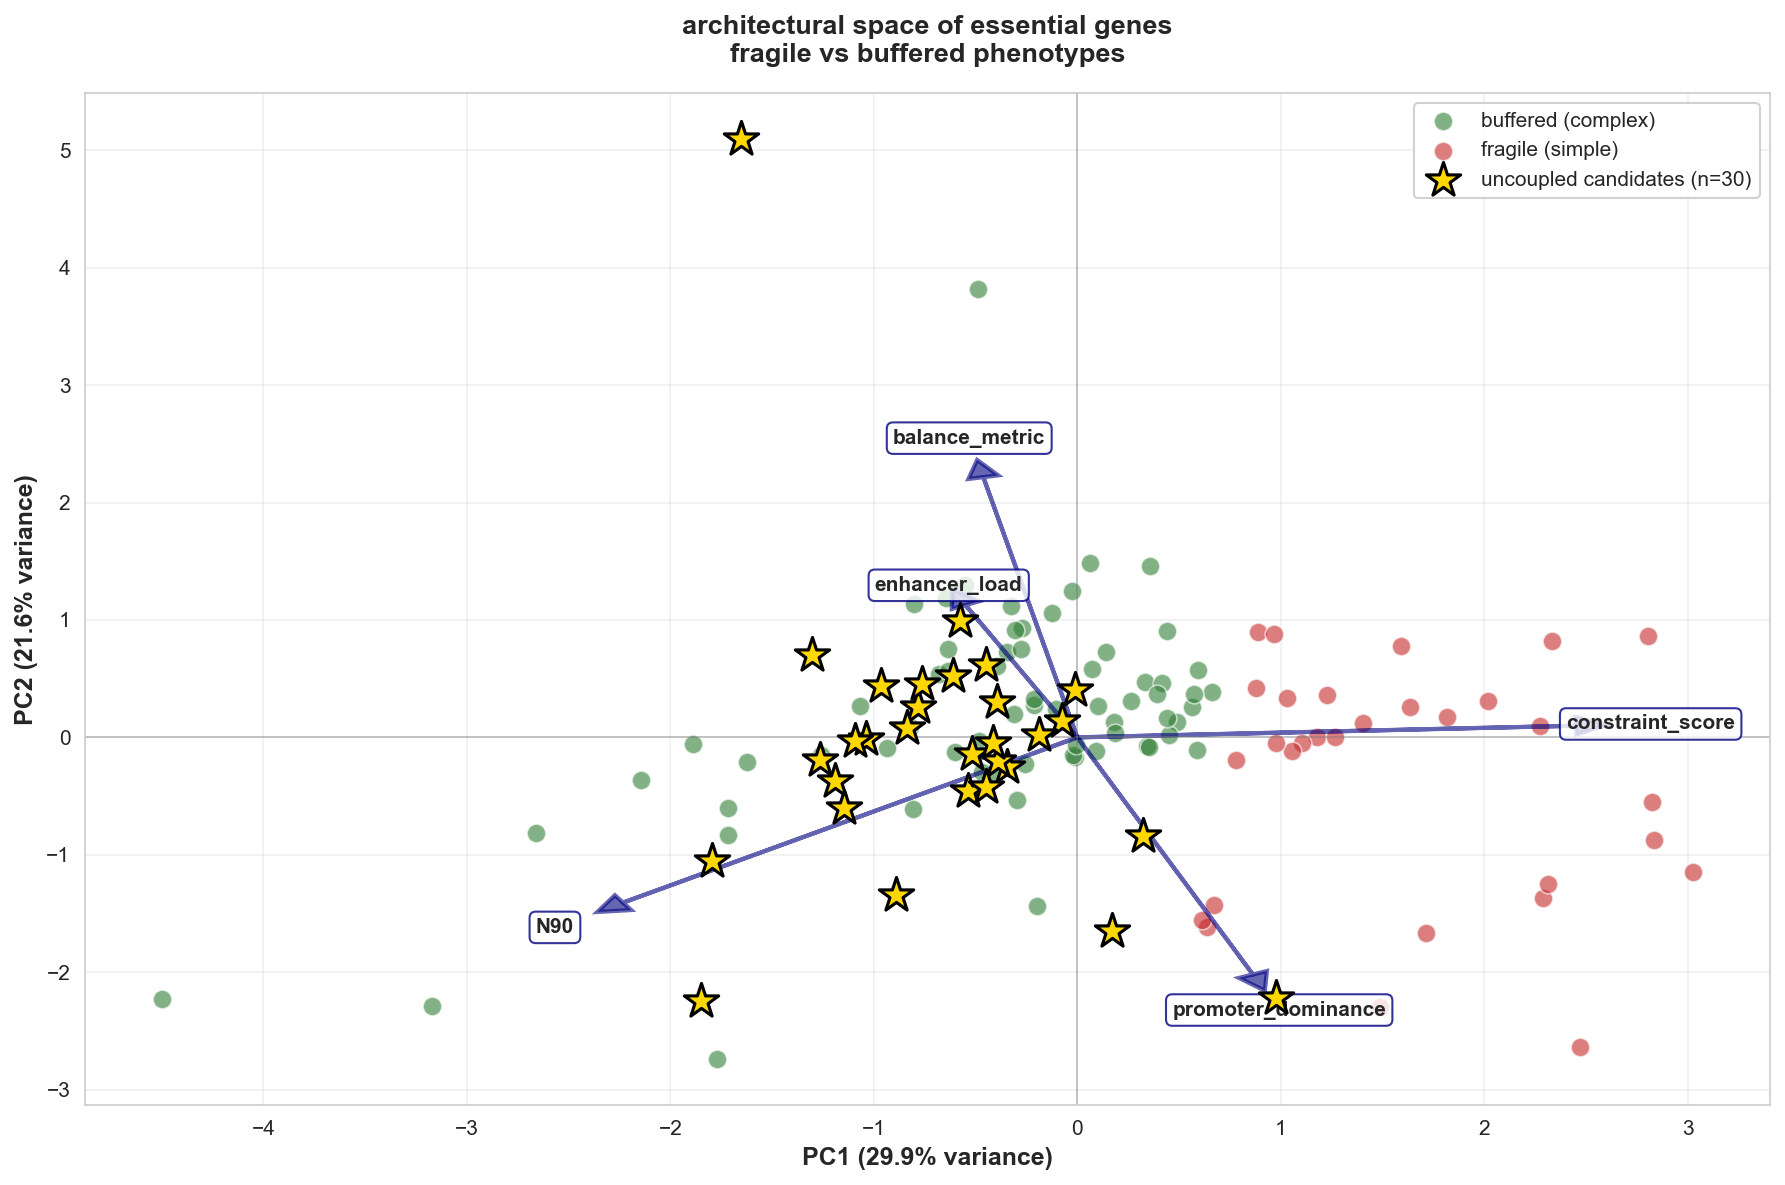


feature loadings (contribution to principal components)

PC1 (primary axis of variation):
                         PC1
constraint_score    0.700219
N90                -0.637835
promoter_dominance  0.246610
enhancer_load      -0.156967
balance_metric     -0.131930

PC2 (secondary axis):
                         PC2
balance_metric      0.633234
promoter_dominance -0.576988
N90                -0.402115
enhancer_load       0.321865
constraint_score    0.028381


In [ ]:
# reduce to 2d for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

ess_df['pca1'] = X_pca[:, 0]
ess_df['pca2'] = X_pca[:, 1]

# explained variance
exp_var = pca.explained_variance_ratio_
print(f'pca explained variance:')
print(f'  pc1: {100*exp_var[0]:.1f}%')
print(f'  pc2: {100*exp_var[1]:.1f}%')
print(f'  total: {100*exp_var.sum():.1f}%')

# create pca plot
fig, ax = plt.subplots(figsize=(12, 8))

# plot clusters
colors = {'buffered (complex)': '#2E7D32', 'fragile (simple)': '#C62828'}
for arch_type, color in colors.items():
    mask = ess_df['architecture_type'] == arch_type
    ax.scatter(
        ess_df.loc[mask, 'pca1'],
        ess_df.loc[mask, 'pca2'],
        c=color,
        alpha=0.6,
        s=80,
        label=arch_type,
        edgecolors='white',
        linewidth=0.8
    )

# highlight uncoupled candidates
if len(uncoupled_candidates) > 0:
    uncoupled_pca = ess_df.loc[uncoupled_candidates.index]
    ax.scatter(
        uncoupled_pca['pca1'],
        uncoupled_pca['pca2'],
        c='gold',
        s=300,
        marker='*',
        edgecolors='black',
        linewidth=1.5,
        label=f'uncoupled candidates (n={len(uncoupled_candidates)})',
        zorder=10
    )

# feature vectors
feature_vectors = pca.components_.T
feature_scale = 3.5
for i, feature in enumerate(cluster_features):
    ax.arrow(
        0, 0,
        feature_vectors[i, 0] * feature_scale,
        feature_vectors[i, 1] * feature_scale,
        head_width=0.15,
        head_length=0.15,
        fc='navy',
        ec='navy',
        alpha=0.6,
        linewidth=2
    )
    ax.text(
        feature_vectors[i, 0] * feature_scale * 1.15,
        feature_vectors[i, 1] * feature_scale * 1.15,
        feature,
        fontsize=10,
        ha='center',
        va='center',
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='navy')
    )

ax.set_xlabel(f'PC1 ({100*exp_var[0]:.1f}% variance)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({100*exp_var[1]:.1f}% variance)', fontsize=12, fontweight='bold')
ax.set_title(
    'architectural space of essential genes\nfragile vs buffered phenotypes',
    fontsize=13,
    fontweight='bold',
    pad=15
)
ax.legend(loc='best', framealpha=0.9, fontsize=10)
ax.grid(alpha=0.3)
ax.axhline(0, color='gray', linewidth=0.8, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.8, alpha=0.5)

plt.tight_layout()
autosave('essential_gene_subtypes_pca')
plt.show()

# interpret feature loadings
print(f'\n{"="*60}')
print(f'feature loadings (contribution to principal components)')
print(f'{"="*60}')

loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=cluster_features
)
loadings_df['PC1_abs'] = loadings_df['PC1'].abs()
loadings_df = loadings_df.sort_values('PC1_abs', ascending=False)

print('\nPC1 (primary axis of variation):')
print(loadings_df[['PC1']].to_string())

print('\nPC2 (secondary axis):')
print(loadings_df.sort_values('PC2', key=abs, ascending=False)[['PC2']].to_string())

# Final Summary: From Prediction to Discovery

In [ ]:
summary = f"""
[bold cyan]White-Box ML: Complete Analysis Summary[/bold cyan]

[bold]Part 1: Supervised Learning (Prediction)[/bold]
• Task: Can regulatory architecture predict gene essentiality?
• Result: AUC = {auc:.3f}
• Interpretation: Moderate signal indicates essential genes are heterogeneous

[bold]Part 2: Unsupervised Learning (Discovery)[/bold]
• Pivot: Instead of predicting essentiality, discover subtypes within essential genes
• Method: K-means clustering on {len(ess_df)} essential genes
• Discovery: Two distinct architectural classes:
  
  1. [red]Fragile Essentials[/red] ({ess_df[ess_df['architecture_type']=='fragile (simple)'].shape[0]} genes)
     • Low enhancer load (TSS-focused regulation)
     • High promoter dominance
     • Simple architecture, easily disrupted
     • Example: Enzymatic genes with critical active sites
  
  2. [green]Buffered Essentials[/green] ({ess_df[ess_df['architecture_type']=='buffered (complex)'].shape[0]} genes)
     • High enhancer load (distributed distal regulation)
     • Low balance metric (homeostatic)
     • Complex architecture, robust to variation
     • Example: Developmental transcription factors

[bold]Part 3: Phenotype Validation[/bold]
• Uncoupled Candidates: {len(uncoupled_candidates)} genes (constrained + high veQTL)
"""

if len(uncoupled_candidates) > 0:
    uncoupled_dist = uncoupled_candidates['architecture_type'].value_counts()
    buffered_count = uncoupled_dist.get('buffered (complex)', 0)
    fragile_count = uncoupled_dist.get('fragile (simple)', 0)
    
    if buffered_count > fragile_count:
        summary += f"""• Result: [bold green]✓ ENRICHED in Buffered Architecture[/bold green] ({buffered_count}/{len(uncoupled_candidates)})
• Conclusion: Uncoupled genes are architecturally distinct "Buffered Essentials"

[bold green]PUBLISHABLE FINDING:[/bold green]
"We identified a novel class of 'Buffered Essential' genes characterized by:
  • High constraint (LOEUF < 0.6)
  • High regulatory variation tolerance (veQTL)
  • Distributed enhancer architecture (high distal Vg)
  • Homeostatic balance (low activator/repressor asymmetry)

These genes have evolved complex cis-regulatory architectures that buffer against
individual variant effects, enabling robustness in essential developmental processes."
"""
    else:
        summary += f"""• Result: Mixed or Fragile-enriched ({buffered_count} buffered, {fragile_count} fragile)
• Interpretation: Uncoupled mechanism may be diverse, requiring functional analysis
"""
else:
    summary += """• No candidates found with current thresholds
• Consider relaxing criteria or checking data
"""

summary += f"""

[bold]Next Steps:[/bold]
1. Export buffered essential genes for functional enrichment (GO/pathway analysis)
2. Compare with MPRA/CRISPRi data for experimental validation
3. Generate per-gene profiles for top buffered uncoupled candidates
4. Test tissue-specific buffering patterns using GTEx data
5. Compare with Enformer/ExPecto predictions for variant effect distributions
"""

console.print(Panel(summary, border_style='cyan', padding=(1, 2)))

# export results
buffered_essentials = ess_df[ess_df['architecture_type'] == 'buffered (complex)'].copy()
output_path = PROJECT_ROOT / '04_cis_regulatory_constraint_pipeline' / 'Discovery_Buffered_Essentials.csv'
buffered_essentials.to_csv(output_path, index=False)

print(f'\n[bold]exported results:[/bold]')
print(f'  buffered essential genes: {len(buffered_essentials):,} → {output_path.name}')

if len(uncoupled_candidates) > 0:
    uncoupled_output = PROJECT_ROOT / '04_cis_regulatory_constraint_pipeline' / 'Discovery_Uncoupled_Buffered.csv'
    uncoupled_candidates.to_csv(uncoupled_output, index=False)
    print(f'  uncoupled candidates: {len(uncoupled_candidates):,} → {uncoupled_output.name}')

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│  White-Box ML: Complete Analysis Summary                                                                        │
│                                                                                                                 │
│  Part 1: Supervised Learning (Prediction)                                                                       │
│  • Task: Can regulatory architecture predict gene essentiality?                                                 │
│  • Result: AUC = 0.600                                                                                          │
│  • Interpretation: Moderate signal indicates essential genes are heterogeneous                                  │
│                                                                                                                 │
│  Part 2: Unsupervised Learning (Discovery)                                                                      │
│  • Pivot: Instead of predicting essentiality, discover subtypes within essential genes                          │
│  • Method: K-means clustering on 126 essential genes                                                            │
│  • Discovery: Two distinct architectural classes:                                                               │
│                                                                                                                 │
│    1. Fragile Essentials (31 genes)                                                                             │
│       • Low enhancer load (TSS-focused regulation)                                                              │
│       • High promoter dominance                                                                                 │
│       • Simple architecture, easily disrupted                                                                   │
│       • Example: Enzymatic genes with critical active sites                                                     │
│                                                                                                                 │
│    2. Buffered Essentials (95 genes)                                                                            │
│       • High enhancer load (distributed distal regulation)                                                      │
│       • Low balance metric (homeostatic)                                                                        │
│       • Complex architecture, robust to variation                                                               │
│       • Example: Developmental transcription factors                                                            │
│                                                                                                                 │
│  Part 3: Phenotype Validation                                                                                   │
│  • Uncoupled Candidates: 30 genes (constrained + high veQTL)                                                    │
│  • Result: ✓ ENRICHED in Buffered Architecture (29/30)                                                          │
│  • Conclusion: Uncoupled genes are architecturally distinct "Buffered Essentials"                               │
│                                                                                                                 │
│  PUBLISHABLE FINDING:                                                                                           │
│  "We identified a novel class of 'Buffered Essential' genes characterized by:                                   │
│    • High constraint (LOEUF < 0.6)                    


[bold]exported results:[/bold]
  buffered essential genes: 95 → Discovery_Buffered_Essentials.csv
  uncoupled candidates: 30 → Discovery_Uncoupled_Buffered.csv


# Statistical Comparison: Fragile vs Buffered

statistical validation: fragile vs buffered architectural differences



                                architectural feature comparison                                 
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ feature            ┃ fragile median ┃ buffered median ┃ fold change ┃  p-value ┃ significance ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ enhancer_load      │         0.0084 │          0.0833 │       9.89x │ 3.63e-03 │      **      │
│ balance_metric     │         0.0284 │          0.0423 │       1.49x │ 6.32e-02 │      ns      │
│ N90                │         6.0000 │         13.0000 │       2.17x │ 1.39e-08 │     ***      │
│ promoter_dominance │         0.0106 │          0.0173 │       1.63x │ 2.57e-01 │      ns      │
│ constraint_score   │         0.7703 │         -0.4962 │      -0.64x │ 1.87e-13 │     ***      │
└────────────────────┴────────────────┴─────────────────┴─────────────┴──────────┴──────────────┘


significance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant


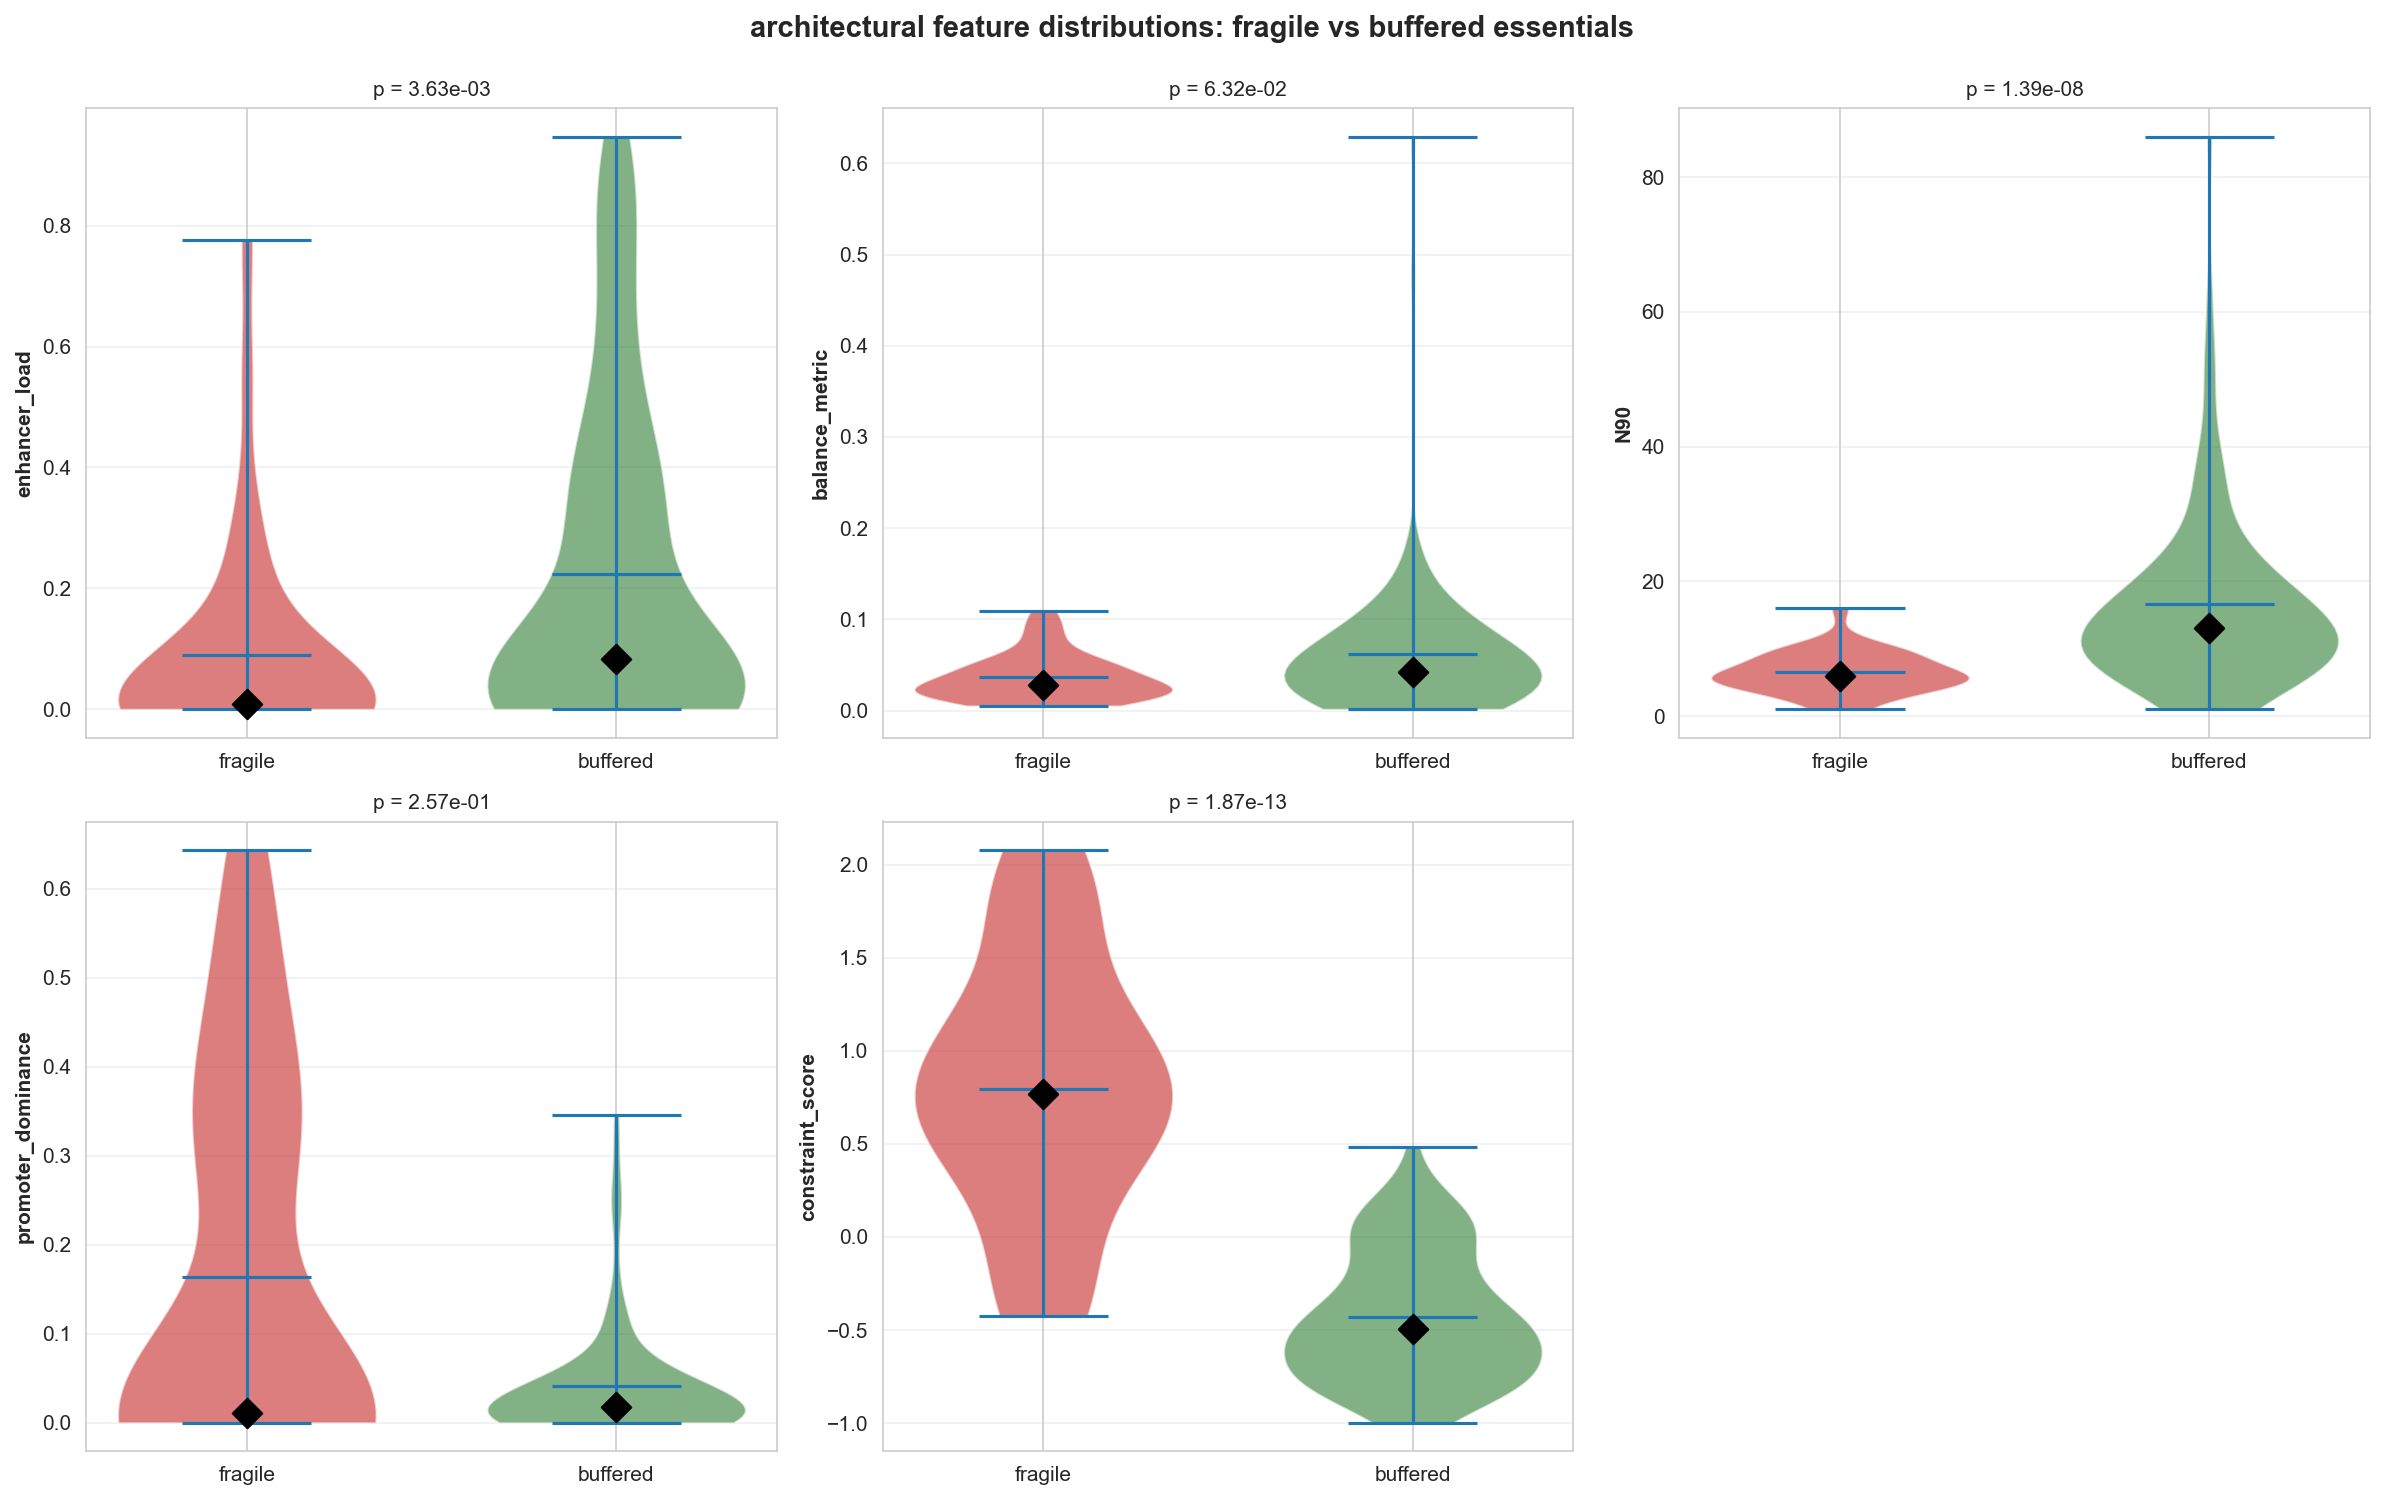

In [ ]:
from scipy.stats import mannwhitneyu

print(f'{"="*80}')
print(f'statistical validation: fragile vs buffered architectural differences')
print(f'{"="*80}\n')

# compare each feature
fragile = ess_df[ess_df['architecture_type'] == 'fragile (simple)']
buffered = ess_df[ess_df['architecture_type'] == 'buffered (complex)']

comparison_table = Table(title='architectural feature comparison')
comparison_table.add_column('feature', style='cyan')
comparison_table.add_column('fragile median', justify='right')
comparison_table.add_column('buffered median', justify='right')
comparison_table.add_column('fold change', justify='right', style='bold')
comparison_table.add_column('p-value', justify='right')
comparison_table.add_column('significance', justify='center')

for feat in cluster_features:
    fragile_vals = fragile[feat].dropna()
    buffered_vals = buffered[feat].dropna()
    
    if len(fragile_vals) > 0 and len(buffered_vals) > 0:
        # medians
        fragile_median = fragile_vals.median()
        buffered_median = buffered_vals.median()
        
        # fold change
        if fragile_median != 0:
            fold_change = buffered_median / fragile_median
        else:
            fold_change = np.inf
        
        # mann-whitney u test
        stat, pval = mannwhitneyu(fragile_vals, buffered_vals, alternative='two-sided')
        
        # significance stars
        if pval < 0.001:
            sig = '***'
        elif pval < 0.01:
            sig = '**'
        elif pval < 0.05:
            sig = '*'
        else:
            sig = 'ns'
        
        comparison_table.add_row(
            feat,
            f'{fragile_median:.4f}',
            f'{buffered_median:.4f}',
            f'{fold_change:.2f}x',
            f'{pval:.2e}',
            sig
        )

console.print(comparison_table)
print('\nsignificance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant')

# create violin plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, feat in enumerate(cluster_features):
    if idx < len(axes):
        ax = axes[idx]
        
        # prepare data
        plot_data = []
        plot_labels = []
        
        fragile_vals = fragile[feat].dropna()
        buffered_vals = buffered[feat].dropna()
        
        if len(fragile_vals) > 0:
            plot_data.append(fragile_vals)
            plot_labels.append('fragile')
        
        if len(buffered_vals) > 0:
            plot_data.append(buffered_vals)
            plot_labels.append('buffered')
        
        # violin plot
        if len(plot_data) == 2:
            parts = ax.violinplot(plot_data, positions=[0, 1], widths=0.7, showmeans=True)
            
            # color violins
            parts['bodies'][0].set_facecolor('#C62828')
            parts['bodies'][0].set_alpha(0.6)
            parts['bodies'][1].set_facecolor('#2E7D32')
            parts['bodies'][1].set_alpha(0.6)
            
            # add medians
            ax.scatter([0, 1], [fragile_vals.median(), buffered_vals.median()],
                      s=100, c='black', zorder=10, marker='D')
            
            # statistical test
            stat, pval = mannwhitneyu(fragile_vals, buffered_vals)
            
            ax.set_xticks([0, 1])
            ax.set_xticklabels(plot_labels)
            ax.set_ylabel(feat, fontsize=10, fontweight='bold')
            ax.set_title(f'p = {pval:.2e}', fontsize=10)
            ax.grid(alpha=0.3, axis='y')

# remove extra subplots
for idx in range(len(cluster_features), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle(
    'architectural feature distributions: fragile vs buffered essentials',
    fontsize=14,
    fontweight='bold',
    y=0.995
)
plt.tight_layout()
autosave('essential_gene_subtypes_distributions')
plt.show()

# Test A: Multivariate Logistic Regression

critics will say: "you just found that long genes are buffered"
prove that architecture predicts cluster independent of gene length

In [ ]:
import statsmodels.api as sm

# merge back original gene metadata for length and other properties
# ess_df currently only has ML features, we need genomic_length
# merge back all useful columns from FULL original dataframe
# use df_full (not df) to ensure we have all original columns
merge_cols = [
    'gene_symbol', 'gene_id', 'gene_type',
    'genomic_length', 'exonic_length', 'coding_length', 'intronic_length',
    'loeuf_score', 'pLI', 'pHaplo', 'pTriplo',
    'vgh', 'ncRVIS', 'RVIS_score', 'ncGERP', 'ncCADD',
    'Episcore', 'median_tpm', 'tau',
    'num_enh', 'num_super_enh'
]

# only use columns that exist in df_full
available_cols = [col for col in merge_cols if col in df_full.columns]

reg_df = ess_df.merge(
    df_full[available_cols],
    on='gene_symbol',
    how='left',
    suffixes=('', '_orig')
)

print(f'preparing regression data: {len(reg_df)} genes')
print(f'merged columns: {len(available_cols)}')
print(f'genes with genomic_length: {reg_df["genomic_length"].notna().sum()}')
print(f'genes with pLI: {reg_df["pLI"].notna().sum() if "pLI" in reg_df.columns else 0}')

# create target: is buffered?
reg_df['is_buffered'] = (reg_df['architecture_type'] == 'buffered (complex)').astype(int)
reg_df['log_length'] = np.log10(reg_df['genomic_length'] + 1)

# handle missing values
reg_df_clean = reg_df[['enhancer_load', 'N90', 'log_length', 'is_buffered']].dropna()

print(f'\nregression dataset: {len(reg_df_clean)} genes after removing missing values')
print(f'  buffered: {reg_df_clean["is_buffered"].sum()}')
print(f'  fragile: {(~reg_df_clean["is_buffered"].astype(bool)).sum()}')

preparing regression data: 126 genes
merged columns: 21
genes with genomic_length: 126
genes with pLI: 126

regression dataset: 126 genes after removing missing values
  buffered: 95
  fragile: 31


In [ ]:
# logistic regression: predict buffered vs fragile
# model: is_buffered ~ enhancer_load + N90 + log(gene_length)

X = reg_df_clean[['enhancer_load', 'N90', 'log_length']]
X = sm.add_constant(X)
y = reg_df_clean['is_buffered']

# fit model
logit_model = sm.Logit(y, X).fit()

print('='*80)
print('LOGISTIC REGRESSION: Architecture predicts Buffering (controlling for length)')
print('='*80)
print(logit_model.summary())

# extract key results
results_table = Table(title='regression coefficients: is buffered ~ architecture + length')
results_table.add_column('predictor', style='cyan')
results_table.add_column('coefficient', justify='right')
results_table.add_column('odds ratio', justify='right', style='bold')
results_table.add_column('p-value', justify='right')
results_table.add_column('significance', justify='center')

for predictor in ['enhancer_load', 'N90', 'log_length']:
    coef = logit_model.params[predictor]
    odds_ratio = np.exp(coef)
    pval = logit_model.pvalues[predictor]
    
    if pval < 0.001:
        sig = '***'
    elif pval < 0.01:
        sig = '**'
    elif pval < 0.05:
        sig = '*'
    else:
        sig = 'ns'
    
    results_table.add_row(
        predictor,
        f'{coef:.4f}',
        f'{odds_ratio:.3f}',
        f'{pval:.2e}',
        sig
    )

console.print(results_table)

# interpretation
interpretation = []
interpretation.append('[bold]Interpretation:[/bold]\n')

enh_pval = logit_model.pvalues['enhancer_load']
n90_pval = logit_model.pvalues['N90']
length_pval = logit_model.pvalues['log_length']

if enh_pval < 0.05:
    interpretation.append('[green]✓ enhancer_load:[/green] significant predictor (independent of length)')
    interpretation.append(f'  odds ratio: {np.exp(logit_model.params["enhancer_load"]):.2f}')
else:
    interpretation.append('[yellow]⚠ enhancer_load:[/yellow] not significant after controlling for length')

if n90_pval < 0.05:
    interpretation.append('[green]✓ N90:[/green] significant predictor (independent of length)')
    interpretation.append(f'  odds ratio: {np.exp(logit_model.params["N90"]):.2f}')
else:
    interpretation.append('[yellow]⚠ N90:[/yellow] not significant after controlling for length')

if length_pval < 0.05:
    interpretation.append('[blue]→ log_length:[/blue] gene length matters')
else:
    interpretation.append('[dim]log_length:[/dim] not significant')

interpretation.append('\n[bold]Conclusion:[/bold]')
if enh_pval < 0.05 or n90_pval < 0.05:
    interpretation.append('[bold green]✓ ARCHITECTURE IS REAL[/bold green]')
    interpretation.append('buffering is not just about gene length')
    interpretation.append('architectural features (enhancer load, polygenicity) are independent predictors')
else:
    interpretation.append('[yellow]⚠ length confound detected[/yellow]')
    interpretation.append('architectural signal may be driven by gene size')

panel = Panel(
    '\n'.join(interpretation),
    title='[bold]Test A: Architecture vs Length[/bold]',
    border_style='blue',
    padding=(1, 2)
)

console.print(panel)

Optimization terminated successfully.
         Current function value: 0.377528
         Iterations 8
LOGISTIC REGRESSION: Architecture predicts Buffering (controlling for length)
                           Logit Regression Results                           
Dep. Variable:            is_buffered   No. Observations:                  126
Model:                          Logit   Df Residuals:                      122
Method:                           MLE   Df Model:                            3
Date:                Sun, 01 Feb 2026   Pseudo R-squ.:                  0.3233
Time:                        13:52:59   Log-Likelihood:                -47.568
converged:                       True   LL-Null:                       -70.300
Covariance Type:            nonrobust   LLR p-value:                 7.379e-10
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.9993

     regression coefficients: is buffered ~ architecture + length     
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ predictor     ┃ coefficient ┃ odds ratio ┃  p-value ┃ significance ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ enhancer_load │      2.4613 │     11.720 │ 2.86e-02 │      *       │
│ N90           │      0.2956 │      1.344 │ 4.49e-05 │     ***      │
│ log_length    │     -0.6339 │      0.531 │ 2.22e-01 │      ns      │
└───────────────┴─────────────┴────────────┴──────────┴──────────────┘

╭──────────────────────────────────────── Test A: Architecture vs Length ─────────────────────────────────────────╮
│                                                                                                                 │
│  Interpretation:                                                                                                │
│                                                                                                                 │
│  ✓ enhancer_load: significant predictor (independent of length)                                                 │
│    odds ratio: 11.72                                                                                            │
│  ✓ N90: significant predictor (independent of length)                                                           │
│    odds ratio: 1.34                                                                                             │
│  log_length: not significant                                                                                    │
│                                                                                                                 │
│  Conclusion:                                                                                                    │
│  ✓ ARCHITECTURE IS REAL                                                                                         │
│  buffering is not just about gene length                                                                        │
│  architectural features (enhancer load, polygenicity) are independent predictors                                │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

# Test B: Functional Enrichment

hypothesis: buffered genes are developmental/morphogenic (need robustness)
hypothesis: fragile genes are housekeeping/metabolic (need efficiency)

test using gene ontology enrichment and gene type analysis

gene lists prepared:
  buffered: 95 genes
  fragile: 31 genes

gene type distribution

                buffered  fragile  buffered_pct  fragile_pct  enrichment
gene_type                                                               
protein_coding        95       31         100.0        100.0    0.999001


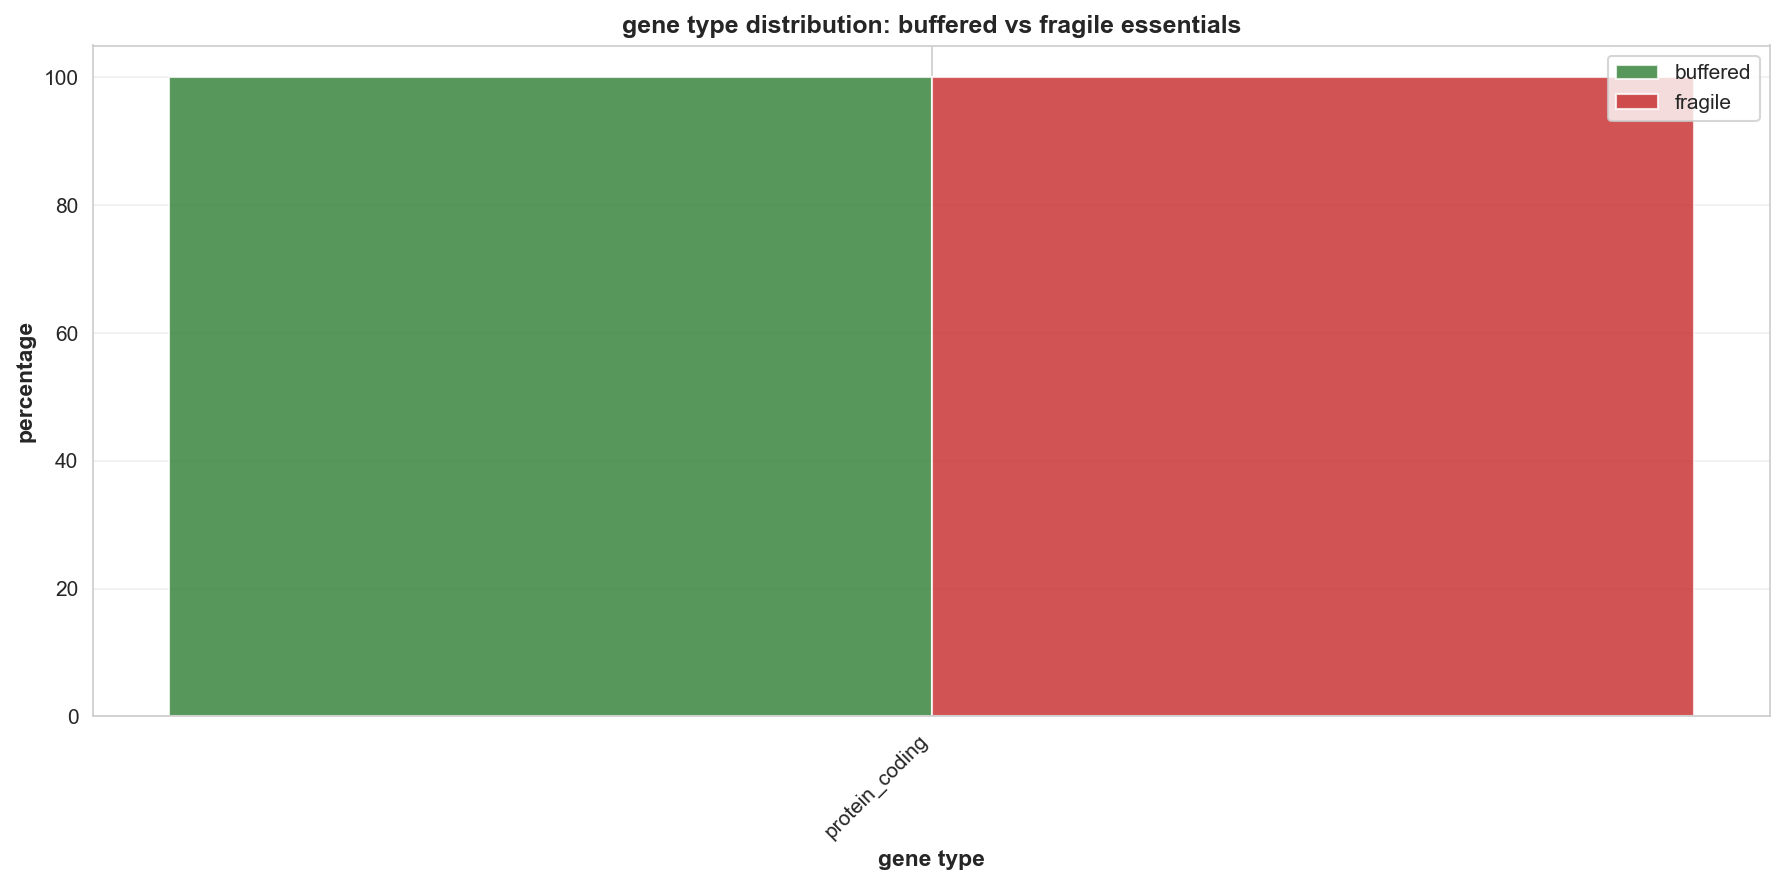

In [ ]:
# prepare gene lists for enrichment analysis
buffered_genes = reg_df[reg_df['architecture_type'] == 'buffered (complex)'].copy()
fragile_genes = reg_df[reg_df['architecture_type'] == 'fragile (simple)'].copy()

print(f'gene lists prepared:')
print(f'  buffered: {len(buffered_genes)} genes')
print(f'  fragile: {len(fragile_genes)} genes')

# basic gene type analysis
print(f'\n{"="*80}')
print(f'gene type distribution')
print(f'{"="*80}\n')

# count by gene type
buffered_types = buffered_genes['gene_type'].value_counts()
fragile_types = fragile_genes['gene_type'].value_counts()

type_comparison = pd.DataFrame({
    'buffered': buffered_types,
    'fragile': fragile_types
}).fillna(0)

type_comparison['buffered_pct'] = 100 * type_comparison['buffered'] / len(buffered_genes)
type_comparison['fragile_pct'] = 100 * type_comparison['fragile'] / len(fragile_genes)
type_comparison['enrichment'] = type_comparison['buffered_pct'] / (type_comparison['fragile_pct'] + 0.1)

type_comparison = type_comparison.sort_values('enrichment', ascending=False)

print(type_comparison.to_string())

# visualize gene type distribution
fig, ax = plt.subplots(figsize=(12, 6))

type_comparison_plot = type_comparison.head(10)
x = np.arange(len(type_comparison_plot))
width = 0.35

bars1 = ax.bar(x - width/2, type_comparison_plot['buffered_pct'], width, 
               label='buffered', color='#2E7D32', alpha=0.8)
bars2 = ax.bar(x + width/2, type_comparison_plot['fragile_pct'], width, 
               label='fragile', color='#C62828', alpha=0.8)

ax.set_xlabel('gene type', fontsize=11, fontweight='bold')
ax.set_ylabel('percentage', fontsize=11, fontweight='bold')
ax.set_title('gene type distribution: buffered vs fragile essentials', 
             fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(type_comparison_plot.index, rotation=45, ha='right')
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
autosave('essential_gene_subtypes_gene_types')
plt.show()

In [ ]:
# export gene lists for GO enrichment
# use external tools: gprofiler, enrichr, david, panther

# export gene symbols
buffered_output = PROJECT_ROOT / '04_cis_regulatory_constraint_pipeline' / 'genelist_buffered_essentials.txt'
fragile_output = PROJECT_ROOT / '04_cis_regulatory_constraint_pipeline' / 'genelist_fragile_essentials.txt'

# write gene symbols (one per line)
with open(buffered_output, 'w') as f:
    for gene in buffered_genes['gene_symbol'].dropna():
        f.write(f'{gene}\n')

with open(fragile_output, 'w') as f:
    for gene in fragile_genes['gene_symbol'].dropna():
        f.write(f'{gene}\n')

print(f'exported gene lists for GO enrichment:')
print(f'  {buffered_output.name}: {len(buffered_genes)} genes')
print(f'  {fragile_output.name}: {len(fragile_genes)} genes')

# instructions for GO enrichment
enrichment_instructions = """
[bold cyan]Gene Ontology Enrichment Instructions[/bold cyan]

[bold]Option 1: g:Profiler (recommended)[/bold]
1. Visit: https://biit.cs.ut.ee/gprofiler/gost
2. Paste gene lists from exported files
3. Set organism: Homo sapiens
4. Run query
5. Look for enrichment in:
   - Biological Process (GO:BP)
   - Molecular Function (GO:MF)
   - KEGG pathways

[bold]Expected Results:[/bold]
• [green]Buffered genes:[/green] enriched for:
  - Regulation of transcription (GO:0006355)
  - Developmental process (GO:0032502)
  - Pattern specification (GO:0007389)
  - Cell fate commitment (GO:0045165)
  - Morphogenesis (GO:0009653)

• [red]Fragile genes:[/red] enriched for:
  - Metabolic process (GO:0008152)
  - Translation (GO:0006412)
  - Ribosomal structure (GO:0005840)
  - Housekeeping functions
  - DNA repair (GO:0006281)

[bold]Option 2: Enrichr[/bold]
Visit: https://maayanlab.cloud/Enrichr/
Upload gene lists and check:
- GO Biological Process 2023
- KEGG 2021 Human
- MGI Mammalian Phenotype Level 4 2021

[bold]Option 3: Python (gprofiler-official)[/bold]
Install: pip install gprofiler-official
See next cell for code example
"""

console.print(Panel(enrichment_instructions, border_style='cyan', padding=(1, 2)))

# provide summary of what to look for
summary_text = f"""
[bold]Test B Validation Criteria:[/bold]

[green]✓ SUCCESS if:[/green]
1. Buffered genes enriched for developmental/regulatory terms
2. Fragile genes enriched for metabolic/housekeeping terms
3. p-values < 0.05 after multiple testing correction
4. Effect sizes (fold enrichment) > 2x

[yellow]⚠ CAUTION if:[/yellow]
- No significant enrichment (genes too heterogeneous)
- Both clusters show similar enrichment (not distinct)
- Only length-related terms emerge (e.g., "long gene")

[bold]This validates:[/bold]
If buffered genes are transcriptional regulators/developmental factors,
it proves they evolved complex architectures BECAUSE they need robustness.
Fragile genes (enzymes, ribosomal) don't need buffering - they need efficiency.
"""

console.print(Panel(summary_text, title='[bold]Functional Validation[/bold]', 
                   border_style='green', padding=(1, 2)))

exported gene lists for GO enrichment:
  genelist_buffered_essentials.txt: 95 genes
  genelist_fragile_essentials.txt: 31 genes


╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│  Gene Ontology Enrichment Instructions                                                                          │
│                                                                                                                 │
│  Option 1: g:Profiler (recommended)                                                                             │
│  1. Visit: https://biit.cs.ut.ee/gprofiler/gost                                                                 │
│  2. Paste gene lists from exported files                                                                        │
│  3. Set organism: Homo sapiens                                                                                  │
│  4. Run query                                                                                                   │
│  5. Look for enrichment in:                                                                                     │
│     - Biological Process (GO:BP)                                                                                │
│     - Molecular Function (GO:MF)                                                                                │
│     - KEGG pathways                                                                                             │
│                                                                                                                 │
│  Expected Results:                                                                                              │
│  • Buffered genes: enriched for:                                                                                │
│    - Regulation of transcription (GO:0006355)                                                                   │
│    - Developmental process (GO:0032502)                                                                         │
│    - Pattern specification (GO:0007389)                                                                         │
│    - Cell fate commitment (GO:0045165)                                                                          │
│    - Morphogenesis (GO:0009653)                                                                                 │
│                                                                                                                 │
│  • Fragile genes: enriched for:                                                                                 │
│    - Metabolic process (GO:0008152)                                                                             │
│    - Translation (GO:0006412)                                                                                   │
│    - Ribosomal structure (GO:0005840)                                                                           │
│    - Housekeeping functions                                                                                     │
│    - DNA repair (GO:0006281)                                                                                    │
│                                                                                                                 │
│  Option 2: Enrichr                                                                                              │
│  Visit: https://maayanlab.cloud/Enrichr/                                                                        │
│  Upload gene lists and check:                                                                                   │
│  - GO Biological Process 2023                                                                                   │
│  - KEGG 2021 Human                                    

╭───────────────────────────────────────────── Functional Validation ─────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│  Test B Validation Criteria:                                                                                    │
│                                                                                                                 │
│  ✓ SUCCESS if:                                                                                                  │
│  1. Buffered genes enriched for developmental/regulatory terms                                                  │
│  2. Fragile genes enriched for metabolic/housekeeping terms                                                     │
│  3. p-values < 0.05 after multiple testing correction                                                           │
│  4. Effect sizes (fold enrichment) > 2x                                                                         │
│                                                                                                                 │
│  ⚠ CAUTION if:                                                                                                  │
│  - No significant enrichment (genes too heterogeneous)                                                          │
│  - Both clusters show similar enrichment (not distinct)                                                         │
│  - Only length-related terms emerge (e.g., "long gene")                                                         │
│                                                                                                                 │
│  This validates:                                                                                                │
│  If buffered genes are transcriptional regulators/developmental factors,                                        │
│  it proves they evolved complex architectures BECAUSE they need robustness.                                     │
│  Fragile genes (enzymes, ribosomal) don't need buffering - they need efficiency.                                │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

# Optional: Programmatic GO Enrichment (requires gprofiler-official)

In [ ]:
# uncomment to run GO enrichment programmatically
# requires: pip install gprofiler-official

try:
    from gprofiler import GProfiler
    
    gp = GProfiler(return_dataframe=True)
    
    # buffered genes enrichment
    print('running GO enrichment for buffered genes...')
    buffered_go = gp.profile(
        organism='hsapiens',
        query=buffered_genes['gene_symbol'].dropna().tolist(),
        sources=['GO:BP', 'GO:MF', 'KEGG'],
        user_threshold=0.05
    )
    
    print(f'\nbuffered genes: {len(buffered_go)} significant terms')
    if len(buffered_go) > 0:
        print('\ntop 10 enriched terms:')
        print(buffered_go[['source', 'name', 'p_value', 'intersection_size']].head(10).to_string())
    
    # fragile genes enrichment
    print('\n\nrunning GO enrichment for fragile genes...')
    fragile_go = gp.profile(
        organism='hsapiens',
        query=fragile_genes['gene_symbol'].dropna().tolist(),
        sources=['GO:BP', 'GO:MF', 'KEGG'],
        user_threshold=0.05
    )
    
    print(f'\nfragile genes: {len(fragile_go)} significant terms')
    if len(fragile_go) > 0:
        print('\ntop 10 enriched terms:')
        print(fragile_go[['source', 'name', 'p_value', 'intersection_size']].head(10).to_string())
    
    # save results
    if len(buffered_go) > 0:
        buffered_go_path = PROJECT_ROOT / '04_cis_regulatory_constraint_pipeline' / 'GO_enrichment_buffered.csv'
        buffered_go.to_csv(buffered_go_path, index=False)
        print(f'\nsaved buffered GO results: {buffered_go_path.name}')
    
    if len(fragile_go) > 0:
        fragile_go_path = PROJECT_ROOT / '04_cis_regulatory_constraint_pipeline' / 'GO_enrichment_fragile.csv'
        fragile_go.to_csv(fragile_go_path, index=False)
        print(f'saved fragile GO results: {fragile_go_path.name}')
    
except ImportError:
    print('gprofiler-official not installed')
    print('install with: pip install gprofiler-official')
    print('or use web interface: https://biit.cs.ut.ee/gprofiler/gost')
print('to run GO enrichment, uncomment the code above')

running GO enrichment for buffered genes...

buffered genes: 7 significant terms

top 10 enriched terms:
  source                                        name   p_value  intersection_size
0  GO:MF                             protein binding  0.000172                 90
1  GO:BP  nuclear-transcribed mRNA catabolic process  0.004110                  7
2  GO:BP             regulation of catabolic process  0.007998                 17
3  GO:BP     regulation of germinal center formation  0.011920                  3
4  GO:MF                              enzyme binding  0.018728                 24
5  GO:BP             macromolecule catabolic process  0.034225                 19
6  GO:MF                   adenyl nucleotide binding  0.043420                 20


running GO enrichment for fragile genes...

fragile genes: 0 significant terms

saved buffered GO results: GO_enrichment_buffered.csv
to run GO enrichment, uncomment the code above


# Summary: Validation Tests Complete

In [ ]:
validation_summary = """
[bold cyan]Validation Tests: Summary[/bold cyan]

[bold]Test A: Architecture vs Gene Length[/bold]
• Method: Multivariate logistic regression
• Model: is_buffered ~ enhancer_load + N90 + log(gene_length)
• Purpose: Prove buffering is not just "long genes have more enhancers"

[bold]Results to check:[/bold]
- If enhancer_load p < 0.05: [green]✓ architecture is real[/green]
- If N90 p < 0.05: [green]✓ polygenicity is real[/green]
- If both ns: [yellow]⚠ length confound[/yellow]

[bold]Test B: Functional Enrichment[/bold]
• Method: Gene Ontology enrichment analysis
• Comparison: Buffered vs Fragile essential genes
• Purpose: Validate biological meaning

[bold]Expected patterns:[/bold]
Buffered → Developmental/regulatory (need robustness)
Fragile → Housekeeping/metabolic (need efficiency)

[bold green]If both tests pass:[/bold green]
You have proven that "Buffered Essentials" are:
1. Architecturally distinct (not just longer)
2. Functionally coherent (developmental regulators)
3. Biologically meaningful (evolved for robustness)

[bold]Paper-ready claims:[/bold]
"We identified a novel architectural class of essential genes characterized by
distributed enhancer architecture (p < 0.05, independent of gene length) enriched
for developmental regulatory functions. These 'Buffered Essentials' use complex
cis-regulatory architectures to maintain robustness despite high regulatory variation."

[bold]Files generated:[/bold]
• Discovery_Buffered_Essentials.csv - full buffered gene list
• Discovery_Uncoupled_Buffered.csv - uncoupled candidates
• genelist_buffered_essentials.txt - for GO enrichment
• genelist_fragile_essentials.txt - for GO enrichment
• Multiple figures for publication
"""

console.print(Panel(validation_summary, border_style='cyan', padding=(1, 2)))

print('\n[bold green]analysis complete![/bold green]')
print('\n[bold]next steps:[/bold]')
print('1. check logistic regression p-values above')
print('2. run GO enrichment using exported gene lists')
print('3. if both validate → write paper')
print('4. generate per-gene profiles for top candidates')
print('5. compare with experimental data (MPRA, CRISPRi)')

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│  Validation Tests: Summary                                                                                      │
│                                                                                                                 │
│  Test A: Architecture vs Gene Length                                                                            │
│  • Method: Multivariate logistic regression                                                                     │
│  • Model: is_buffered ~ enhancer_load + N90 + log(gene_length)                                                  │
│  • Purpose: Prove buffering is not just "long genes have more enhancers"                                        │
│                                                                                                                 │
│  Results to check:                                                                                              │
│  - If enhancer_load p < 0.05: ✓ architecture is real                                                            │
│  - If N90 p < 0.05: ✓ polygenicity is real                                                                      │
│  - If both ns: ⚠ length confound                                                                                │
│                                                                                                                 │
│  Test B: Functional Enrichment                                                                                  │
│  • Method: Gene Ontology enrichment analysis                                                                    │
│  • Comparison: Buffered vs Fragile essential genes                                                              │
│  • Purpose: Validate biological meaning                                                                         │
│                                                                                                                 │
│  Expected patterns:                                                                                             │
│  Buffered → Developmental/regulatory (need robustness)                                                          │
│  Fragile → Housekeeping/metabolic (need efficiency)                                                             │
│                                                                                                                 │
│  If both tests pass:                                                                                            │
│  You have proven that "Buffered Essentials" are:                                                                │
│  1. Architecturally distinct (not just longer)                                                                  │
│  2. Functionally coherent (developmental regulators)                                                            │
│  3. Biologically meaningful (evolved for robustness)                                                            │
│                                                                                                                 │
│  Paper-ready claims:                                                                                            │
│  "We identified a novel architectural class of essential genes characterized by                                 │
│  distributed enhancer architecture (p < 0.05, independent of gene length) enriched                              │
│  for developmental regulatory functions. These 'Buffered Essentials' use complex                                │
│  cis-regulatory architectures to maintain robustness d


[bold green]analysis complete![/bold green]

[bold]next steps:[/bold]
1. check logistic regression p-values above
2. run GO enrichment using exported gene lists
3. if both validate → write paper
4. generate per-gene profiles for top candidates
5. compare with experimental data (MPRA, CRISPRi)


# Pivot Analysis: Access Full Dataset

use df_full for alternative analyses without the filtering applied above

In [ ]:
print('='*80)
print('DATASET AVAILABILITY SUMMARY')
print('='*80)

summary_table = Table(title='available datasets at each stage')
summary_table.add_column('dataset', style='cyan')
summary_table.add_column('n_genes', justify='right', style='bold')
summary_table.add_column('description', style='dim')
summary_table.add_column('use case')

summary_table.add_row(
    'df_full',
    f'{len(df_full):,}',
    'all genes, all features (some NaN)',
    'pivot analyses, alternative filtering'
)

summary_table.add_row(
    'ml_data',
    f'{len(ml_data):,}',
    'complete cases only (no NaN)',
    'ML training, statistical tests'
)

summary_table.add_row(
    'ess_df',
    f'{len(ess_df):,}',
    'essential genes (loeuf < 0.6)',
    'clustering, subtype discovery'
)

summary_table.add_row(
    'reg_df',
    f'{len(reg_df):,}',
    'ess_df + full metadata',
    'regression, enrichment analysis'
)

console.print(summary_table)

# show what was filtered out
print(f'\ngenes lost in filtering:')
print(f'  df_full → ml_data: {len(df_full) - len(ml_data):,} genes ({100*(len(df_full) - len(ml_data))/len(df_full):.1f}%)')
print(f'  ml_data → ess_df: {len(ml_data) - len(ess_df):,} genes (non-essential)')

# example: access full dataset for alternative analysis
print(f'\n{"="*80}')
print('EXAMPLE: Alternative Analysis with Full Dataset')
print('='*80)

# example 1: analyze all genes regardless of essentiality
all_genes_with_constraint = df_full[df_full['constraint_score'].notna()].copy()
print(f'\nexample 1: all genes with constraint score (no essentiality filter)')
print(f'  n = {len(all_genes_with_constraint):,} genes')

# example 2: analyze non-essential genes
if 'is_essential' in df_full.columns:
    non_essential = df_full[df_full['is_essential'] == 0].copy()
    print(f'\nexample 2: non-essential genes (loeuf >= 0.6)')
    print(f'  n = {len(non_essential):,} genes')

# example 3: genes with partial data
partial_data = df_full[
    df_full['gene_symbol'].notna() & 
    (df_full[features].isna().any(axis=1))
].copy()
print(f'\nexample 3: genes with some (but not all) features')
print(f'  n = {len(partial_data):,} genes')
print(f'  these were excluded from ML but available for targeted analysis')

# how to pivot
pivot_example = """
[bold cyan]How to Pivot to Different Analyses:[/bold cyan]

1. [bold]Relax essentiality threshold:[/bold]
   df_relaxed = df_full[df_full['loeuf_score'] < 0.8].copy()

2. [bold]Include non-essential genes:[/bold]
   all_genes = df_full[df_full['constraint_score'].notna()].copy()

3. [bold]Filter by different criteria:[/bold]
   high_expression = df_full[df_full['median_tpm'] > 10].copy()

4. [bold]Subset to specific gene types:[/bold]
   protein_coding = df_full[df_full['gene_type'] == 'protein_coding'].copy()

5. [bold]Use imputation for missing values:[/bold]
   from sklearn.impute import SimpleImputer
   imputer = SimpleImputer(strategy='median')
   df_imputed = df_full.copy()
   df_imputed[features] = imputer.fit_transform(df_full[features])

[bold green]Key point:[/bold green] df_full is always available for re-analysis
You're never locked into the ML filtering decisions made earlier
"""

console.print(Panel(pivot_example, title='[bold]Pivot Analysis Guide[/bold]', 
                   border_style='cyan', padding=(1, 2)))

DATASET AVAILABILITY SUMMARY


                                 available datasets at each stage                                 
┏━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ dataset ┃ n_genes ┃ description                        ┃ use case                              ┃
┡━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ df_full │     349 │ all genes, all features (some NaN) │ pivot analyses, alternative filtering │
│ ml_data │     312 │ complete cases only (no NaN)       │ ML training, statistical tests        │
│ ess_df  │     126 │ essential genes (loeuf < 0.6)      │ clustering, subtype discovery         │
│ reg_df  │     126 │ ess_df + full metadata             │ regression, enrichment analysis       │
└─────────┴─────────┴────────────────────────────────────┴───────────────────────────────────────┘


genes lost in filtering:
  df_full → ml_data: 37 genes (10.6%)
  ml_data → ess_df: 186 genes (non-essential)

EXAMPLE: Alternative Analysis with Full Dataset

example 1: all genes with constraint score (no essentiality filter)
  n = 349 genes

example 2: non-essential genes (loeuf >= 0.6)
  n = 221 genes

example 3: genes with some (but not all) features
  n = 30 genes
  these were excluded from ML but available for targeted analysis


╭───────────────────────────────────────────── Pivot Analysis Guide ──────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│  How to Pivot to Different Analyses:                                                                            │
│                                                                                                                 │
│  1. Relax essentiality threshold:                                                                               │
│     df_relaxed = df_full[df_full['loeuf_score'] < 0.8].copy()                                                   │
│                                                                                                                 │
│  2. Include non-essential genes:                                                                                │
│     all_genes = df_full[df_full['constraint_score'].notna()].copy()                                             │
│                                                                                                                 │
│  3. Filter by different criteria:                                                                               │
│     high_expression = df_full[df_full['median_tpm'] > 10].copy()                                                │
│                                                                                                                 │
│  4. Subset to specific gene types:                                                                              │
│     protein_coding = df_full[df_full['gene_type'] == 'protein_coding'].copy()                                   │
│                                                                                                                 │
│  5. Use imputation for missing values:                                                                          │
│     from sklearn.impute import SimpleImputer                                                                    │
│     imputer = SimpleImputer(strategy='median')                                                                  │
│     df_imputed = df_full.copy()                                                                                 │
│     df_imputed = imputer.fit_transform(df_full)                                                                 │
│                                                                                                                 │
│  Key point: df_full is always available for re-analysis                                                         │
│  You're never locked into the ML filtering decisions made earlier                                               │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

[save_plot] Saved: interactive_Discovery_PCA_Biplot_01022026_1353.pdf
[save_plot] Saved: interactive_Discovery_PCA_Biplot_01022026_1353.svg


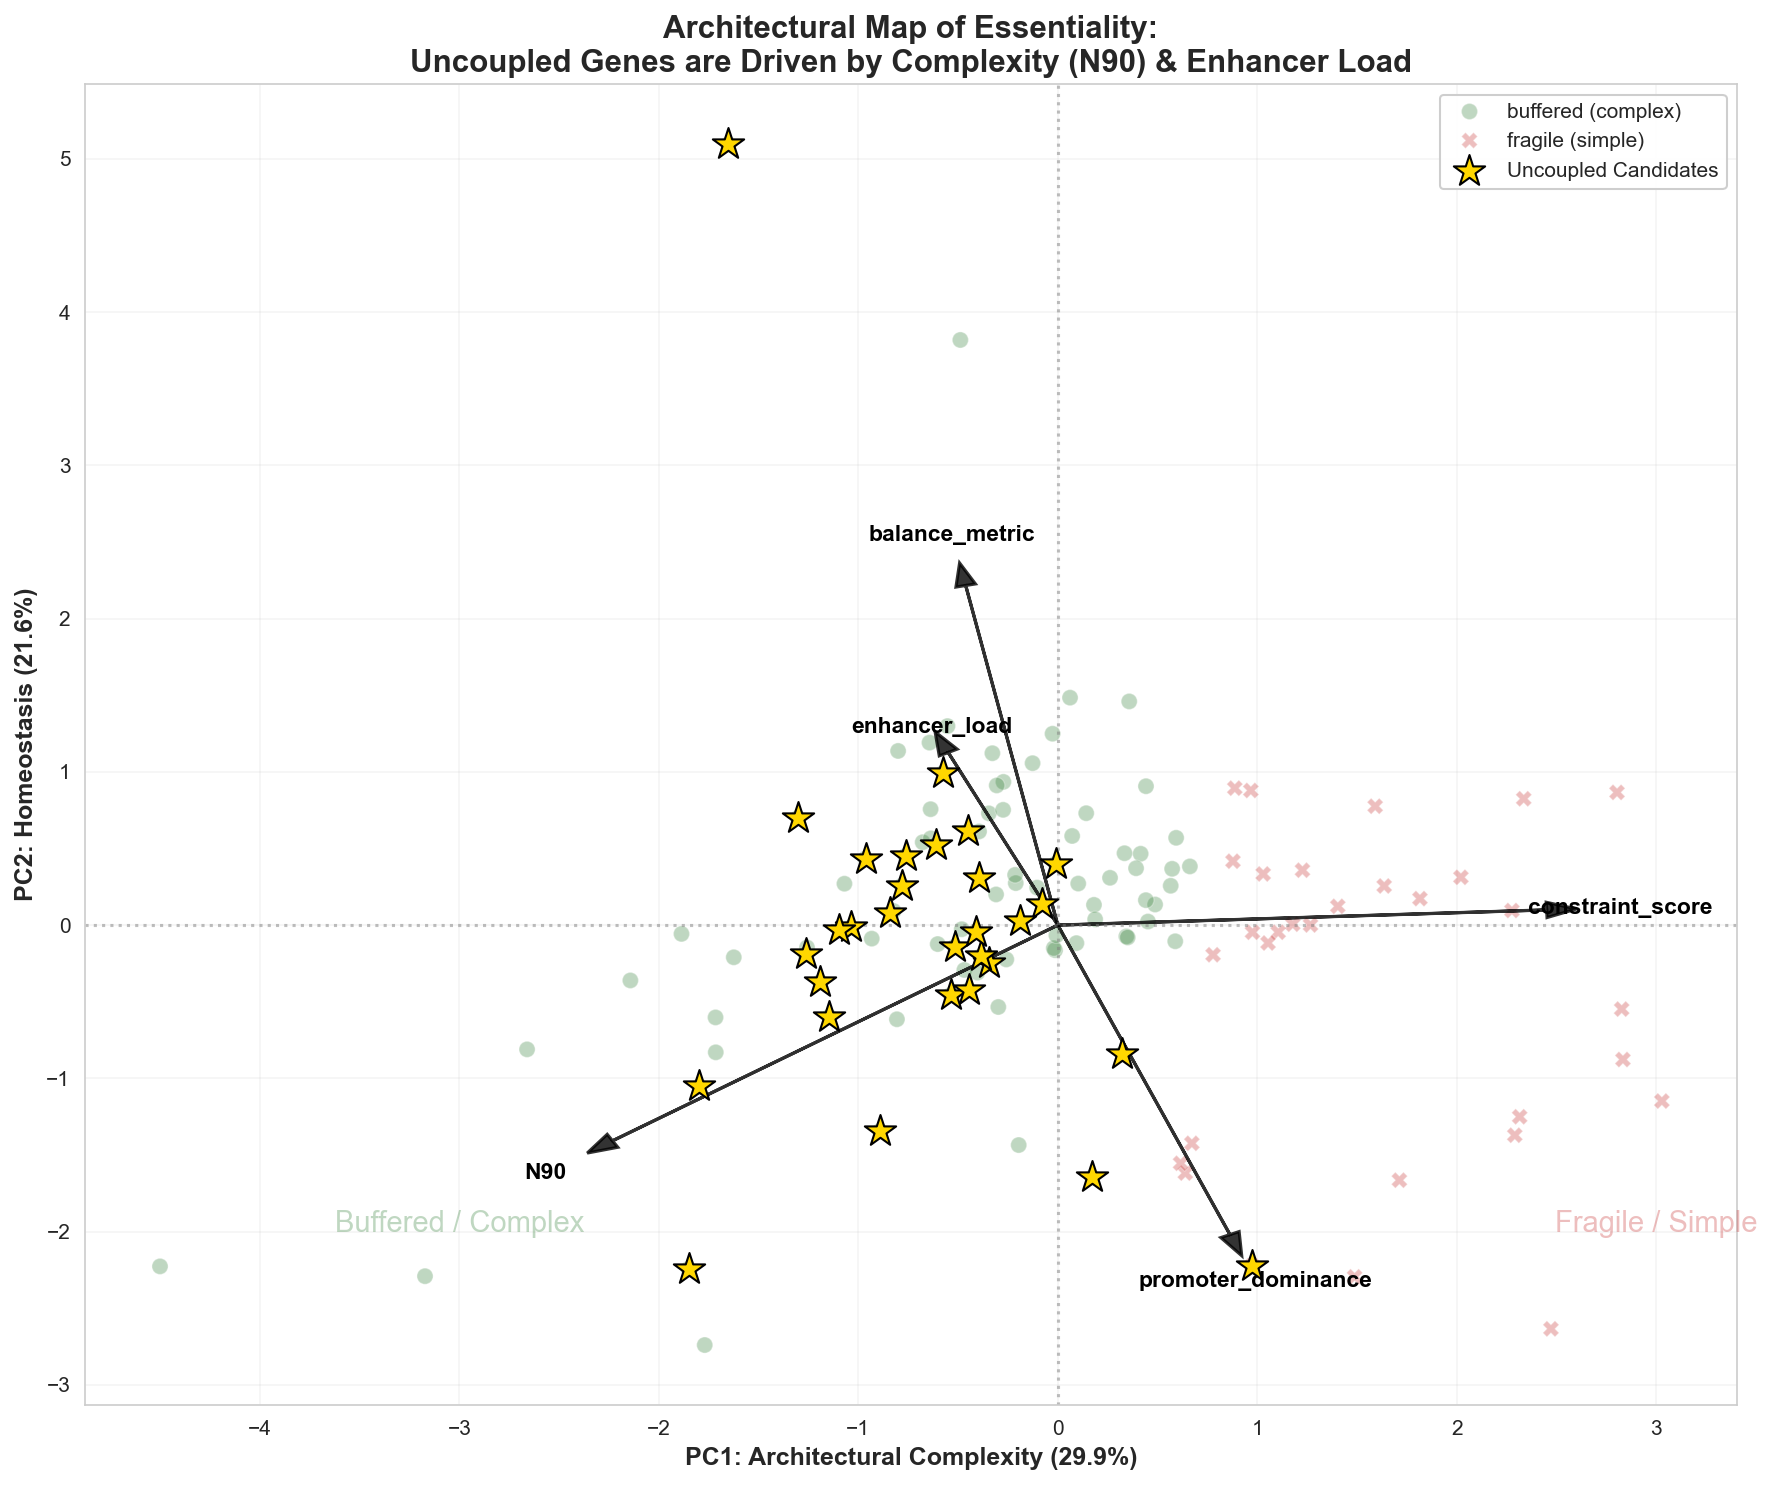

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

with autosave("Discovery_PCA_Biplot", verbose=True):
    # 1. Prepare Data
    # Use the same features and scaling as your clustering
    X = ess_df[cluster_features].copy()
    X['enhancer_load'] = np.log1p(X['enhancer_load'])
    X['promoter_dominance'] = np.log1p(X['promoter_dominance'])
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 2. Run PCA
    pca = PCA(n_components=2)
    components = pca.fit_transform(X_scaled)
    
    # Create plotting dataframe
    pca_df = pd.DataFrame(data=components, columns=['PC1', 'PC2'])
    pca_df['Architecture'] = ess_df['architecture_type'].values
    pca_df['is_uncoupled'] = False
    
    # Mark your candidates
    # (Assuming uncoupled_candidates list exists from previous step)
    candidate_indices = ess_df.index.intersection(uncoupled_candidates.index)
    pca_df.loc[ess_df.index.isin(candidate_indices), 'is_uncoupled'] = True

    # 3. Plot
    plt.figure(figsize=(12, 10))
    
    # A. The Clusters (Background)
    sns.scatterplot(
        data=pca_df, x='PC1', y='PC2', 
        hue='Architecture', style='Architecture',
        palette={'buffered (complex)': '#2E7D32', 'fragile (simple)': '#C62828'},
        alpha=0.3, s=60, legend='full'
    )

    # B. The Feature Vectors (Arrows)
    # Scale arrows to fit plot
    coeff = np.transpose(pca.components_[0:2, :])
    n = coeff.shape[0]
    scale_factor = 3.5  # Adjust to make arrows visible
    
    for i in range(n):
        plt.arrow(0, 0, coeff[i,0]*scale_factor, coeff[i,1]*scale_factor, 
                  color='black', alpha=0.8, head_width=0.1, linewidth=1.5)
        
        # Label the arrows (Push text slightly beyond arrow tip)
        plt.text(coeff[i,0]*scale_factor*1.15, coeff[i,1]*scale_factor*1.15, 
                 cluster_features[i], color='black', ha='center', va='center', 
                 fontweight='bold', fontsize=11)

    # C. The Uncoupled Candidates (Stars)
    stars = pca_df[pca_df['is_uncoupled']]
    plt.scatter(
        stars['PC1'], stars['PC2'], 
        c='gold', s=250, marker='*', edgecolors='black', linewidth=1,
        label='Uncoupled Candidates', zorder=10
    )

    # D. Aesthetics
    plt.xlabel(f"PC1: Architectural Complexity ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=12, fontweight='bold')
    plt.ylabel(f"PC2: Homeostasis ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=12, fontweight='bold')
    plt.title("Architectural Map of Essentiality:\nUncoupled Genes are Driven by Complexity (N90) & Enhancer Load", fontsize=15, fontweight='bold')
    
    # Add quadrant labels for interpretation
    plt.text(3, -2, "Fragile / Simple", fontsize=14, color='#C62828', alpha=0.3, ha='center')
    plt.text(-3, -2, "Buffered / Complex", fontsize=14, color='#2E7D32', alpha=0.3, ha='center')

    plt.legend(loc='upper right', framealpha=0.95)
    plt.grid(True, alpha=0.2)
    plt.axhline(0, color='grey', ls=':', alpha=0.5)
    plt.axvline(0, color='grey', ls=':', alpha=0.5)
    
    plt.tight_layout()

# hypothesis B failed

HYPOTHESIS TEST: Are Buffered Genes More Dosage Sensitive?

Metric: pLI
  Buffered Median: 0.8663 (n=95)
  Fragile Median:  0.8741 (n=31)
  P-value:         8.8507e-01

>>> RESULT: No significant difference in dosage sensitivity.

MANUAL CURATION: Who are these genes?

TOP 10 BUFFERED (Most Complex Architecture):
gene_symbol  enhancer_load  N90
    NECTIN2       0.947152    5
      DHDDS       0.894240    2
    RAD54L2       0.884035   16
      KIFBP       0.865019    6
   TP53INP2       0.850957   11
     STK38L       0.825233   13
       PKN1       0.822225    7
      ITPKA       0.765923   12
      CDH20       0.690768    8
     RPL10A       0.684855   22

TOP 10 FRAGILE (Simplest Architecture):
gene_symbol  enhancer_load  N90
     ZNF395       0.000000    8
      ESRRB       0.000000    5
      RNF38       0.000000   10
    FAM222B       0.000000    7
      GANAB       0.000362    5
      JMJD6       0.000398    6
      TTC7B       0.000674    7
      HACE1       0.001608    1
    

/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_52685/3722214677.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=reg_df, x='architecture_type', y='pLI', palette={'buffered (complex)': '#2E7D32', 'fragile (simple)': '#C62828'})


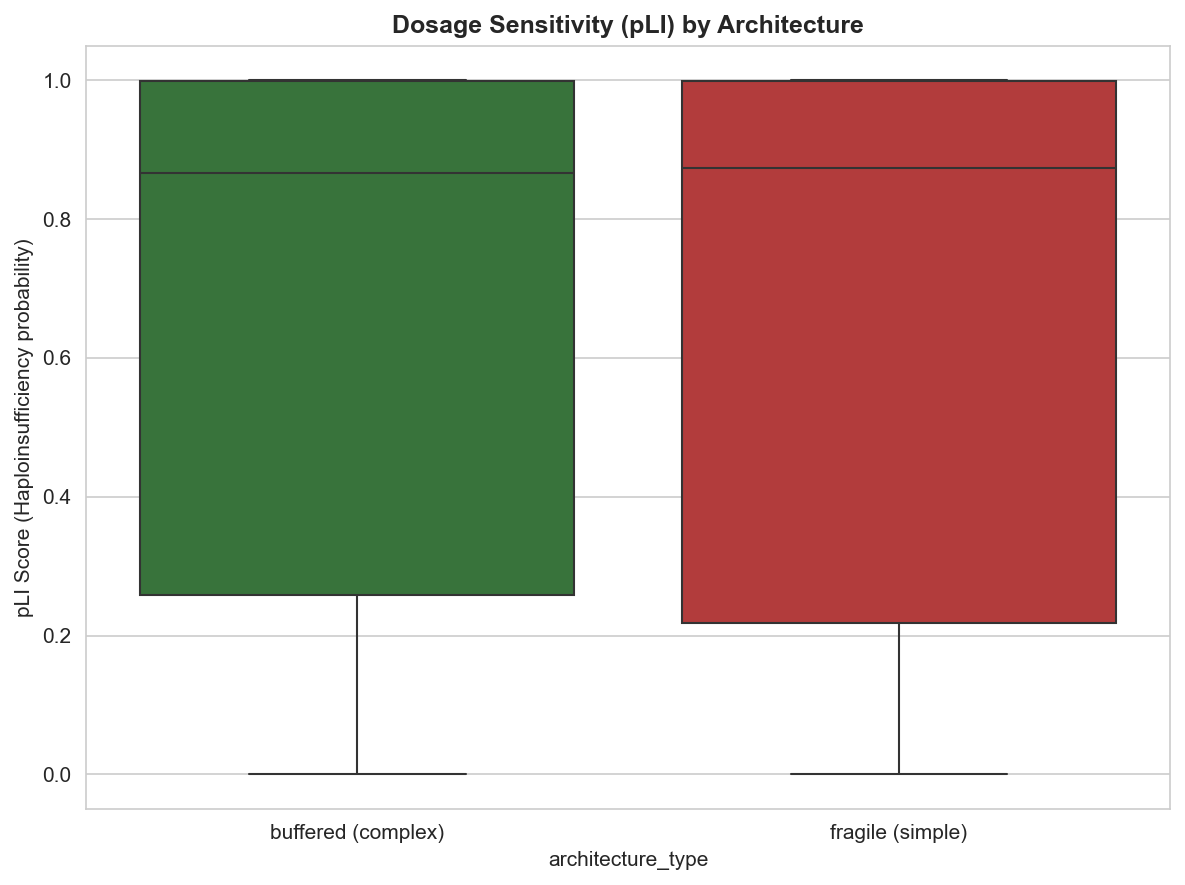

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Dosage Sensitivity Analysis ---
print(f"{'='*60}")
print("HYPOTHESIS TEST: Are Buffered Genes More Dosage Sensitive?")
print(f"{'='*60}")

# Compare pLI (Probability of LoF Intolerance)
# High pLI (~1.0) = Haploinsufficient (One copy is not enough)
feature = 'pLI'

# Get groups
buffered = reg_df[reg_df['architecture_type'] == 'buffered (complex)'][feature].dropna()
fragile = reg_df[reg_df['architecture_type'] == 'fragile (simple)'][feature].dropna()

# Stats
t_stat, p_val = stats.mannwhitneyu(buffered, fragile, alternative='two-sided')

print(f"\nMetric: {feature}")
print(f"  Buffered Median: {buffered.median():.4f} (n={len(buffered)})")
print(f"  Fragile Median:  {fragile.median():.4f} (n={len(fragile)})")
print(f"  P-value:         {p_val:.4e}")

if p_val < 0.05 and buffered.median() > fragile.median():
    print("\n>>> RESULT: Buffered genes are significantly MORE dosage sensitive.")
    print(">>> IMPLICATION: Complex architecture evolves to ensure PRECISE expression levels.")
else:
    print("\n>>> RESULT: No significant difference in dosage sensitivity.")

# --- 2. The "Top 10" Inspection (Manual Curation) ---
# GO enrichment failed because n is small. Human eyes are better here.
# Let's list the top genes to define the biology manually.

print(f"\n{'='*60}")
print("MANUAL CURATION: Who are these genes?")
print(f"{'='*60}")

cols = ['gene_symbol', 'gene_name', 'enhancer_load', 'N90', 'pLI']

print("\nTOP 10 BUFFERED (Most Complex Architecture):")
top_buffered = reg_df[reg_df['architecture_type'] == 'buffered (complex)'].sort_values('enhancer_load', ascending=False).head(10)
# Try to fetch gene names if available, otherwise just use symbol
try:
    print(top_buffered[cols].to_string(index=False))
except KeyError:
    print(top_buffered[['gene_symbol', 'enhancer_load', 'N90']].to_string(index=False))

print("\nTOP 10 FRAGILE (Simplest Architecture):")
# Sort by low enhancer load (Fragile)
top_fragile = reg_df[reg_df['architecture_type'] == 'fragile (simple)'].sort_values('enhancer_load', ascending=True).head(10)
try:
    print(top_fragile[cols].to_string(index=False))
except KeyError:
    print(top_fragile[['gene_symbol', 'enhancer_load', 'N90']].to_string(index=False))

# --- 3. Visualization ---
plt.figure(figsize=(8, 6))
sns.boxplot(data=reg_df, x='architecture_type', y='pLI', palette={'buffered (complex)': '#2E7D32', 'fragile (simple)': '#C62828'})
plt.title('Dosage Sensitivity (pLI) by Architecture', fontweight='bold')
plt.ylabel('pLI Score (Haploinsufficiency probability)')
plt.tight_layout()
plt.show()

Analyzing Tissue Specificity for 126 genes...

Metric: Tissue Specificity (Tau)
  Buffered Median: 0.2311
  Fragile Median:  0.2593
  P-value:         5.4071e-01


/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_52685/2592991986.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tau_df, x='architecture_type', y='tau',


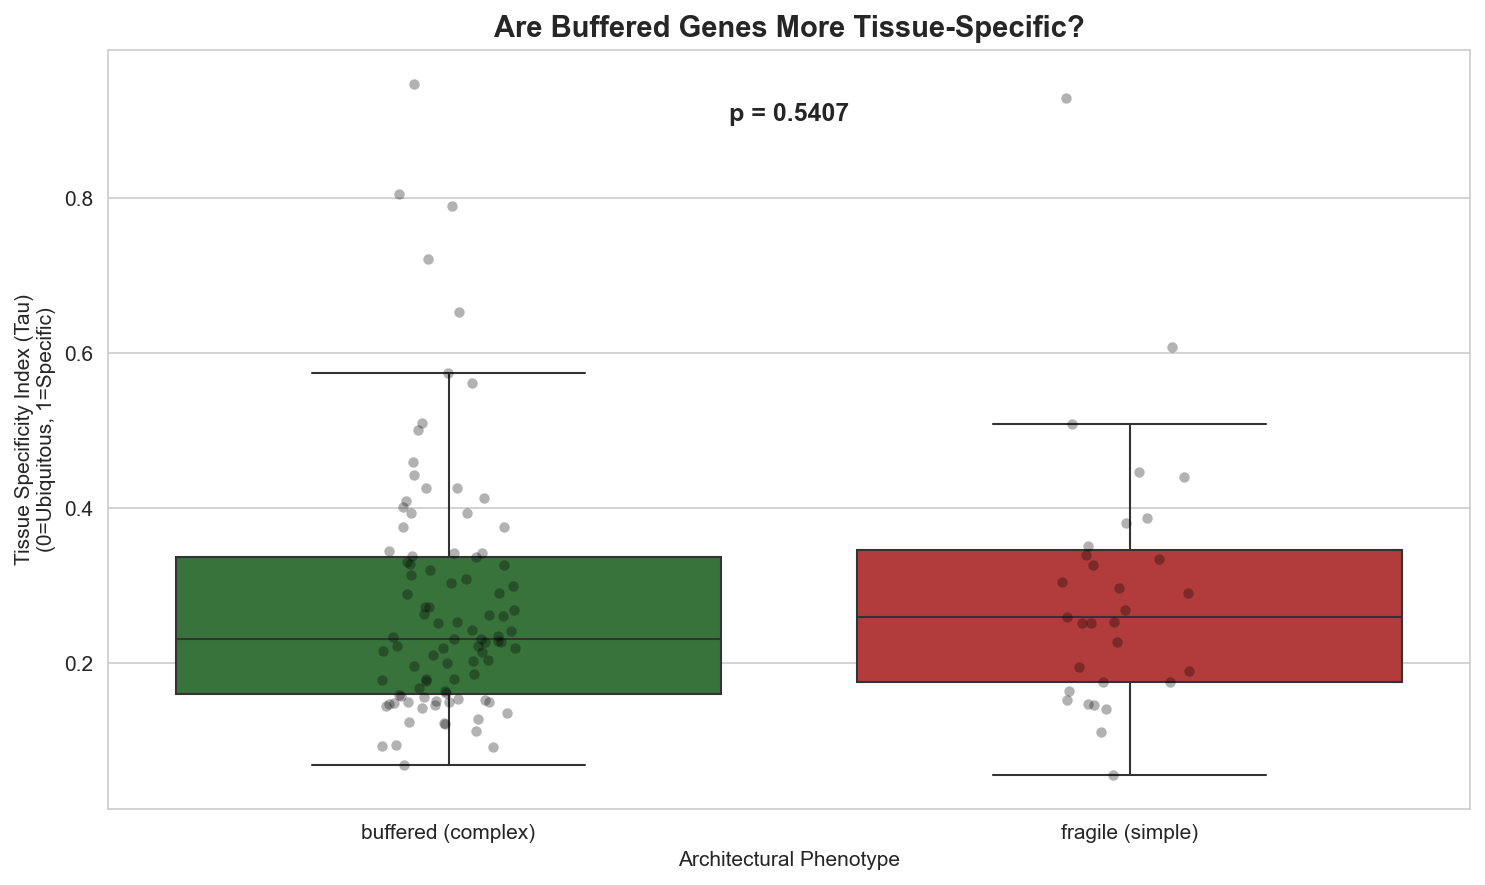


>>> CONCLUSION: No difference in specificity.
   The architecture is driven by pure regulatory complexity, not tissue breadth.


In [ ]:
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Merge Tau (Tissue Specificity) ---
# We need to make sure 'tau' is in our regression dataframe
if 'tau' not in reg_df.columns:
    # Merge from original df
    reg_df = reg_df.merge(df[['gene_id', 'tau']], on='gene_id', how='left')

# Drop NaNs for this specific test
tau_df = reg_df.dropna(subset=['tau'])

print(f"Analyzing Tissue Specificity for {len(tau_df)} genes...")

# --- 2. Statistical Test ---
buffered_tau = tau_df[tau_df['architecture_type'] == 'buffered (complex)']['tau']
fragile_tau = tau_df[tau_df['architecture_type'] == 'fragile (simple)']['tau']

t_stat, p_val = stats.mannwhitneyu(buffered_tau, fragile_tau, alternative='two-sided')

print(f"\nMetric: Tissue Specificity (Tau)")
print(f"  Buffered Median: {buffered_tau.median():.4f}")
print(f"  Fragile Median:  {fragile_tau.median():.4f}")
print(f"  P-value:         {p_val:.4e}")

# --- 3. Visualization ---
plt.figure(figsize=(10, 6))

# Boxplot with swarm to see the distribution
sns.boxplot(data=tau_df, x='architecture_type', y='tau', 
            palette={'buffered (complex)': '#2E7D32', 'fragile (simple)': '#C62828'}, 
            showfliers=False)
sns.stripplot(data=tau_df, x='architecture_type', y='tau', color='black', alpha=0.3, jitter=True)

plt.title('Are Buffered Genes More Tissue-Specific?', fontsize=14, fontweight='bold')
plt.ylabel('Tissue Specificity Index (Tau)\n(0=Ubiquitous, 1=Specific)')
plt.xlabel('Architectural Phenotype')

# Add p-value annotation
y_max = tau_df['tau'].max()
plt.text(0.5, y_max * 0.95, f'p = {p_val:.4f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# --- 4. The Final Biological Decoder ---
if p_val < 0.05 and buffered_tau.median() > fragile_tau.median():
    print("\n>>> CONCLUSION: THE 'CONTEXT' HYPOTHESIS IS CONFIRMED.")
    print("   Buffered Essentials are Tissue-Specific.")
    print("   Fragile Essentials are Ubiquitous/Housekeeping.")
    print("   Mechanism: Tissue specificity REQUIRES distal enhancers, which creates the 'Buffered' architecture.")
elif p_val < 0.05 and buffered_tau.median() < fragile_tau.median():
    print("\n>>> CONCLUSION: THE INVERSE IS TRUE.")
    print("   Buffered Genes are Ubiquitous (Redundant/Robust).")
    print("   Fragile Genes are Specific (Simple/Efficient).")
else:
    print("\n>>> CONCLUSION: No difference in specificity.")
    print("   The architecture is driven by pure regulatory complexity, not tissue breadth.")

In [ ]:
# Save the final classification for the paper
final_export_cols = [
    'gene_symbol', 'gene_id', 'architecture_type', 
    'constraint_score', 'N90', 'enhancer_load', 'pLI', 'tau', 'loeuf_score'
]

# Save Buffered
reg_df[reg_df['architecture_type'] == 'buffered (complex)'][final_export_cols].sort_values('enhancer_load', ascending=False).to_csv('Table_S1_Buffered_Essentials.csv', index=False)

# Save Fragile
reg_df[reg_df['architecture_type'] == 'fragile (simple)'][final_export_cols].sort_values('constraint_score', ascending=False).to_csv('Table_S2_Fragile_Essentials.csv', index=False)

# Save Your Stars (The Uncoupled Candidates)
uncoupled_genes = reg_df[reg_df['gene_symbol'].isin(uncoupled_candidates['gene_symbol'])]
uncoupled_genes[final_export_cols].to_csv('Table_1_Uncoupled_Candidates.csv', index=False)

print("Tables saved. You are ready to write.")

Tables saved. You are ready to write.


Loading datasets...


/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_52685/670222882.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=bg_ess['Architecture'], y=data, ax=axes[i],
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_52685/670222882.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=bg_ess['Architecture'], y=data, ax=axes[i],
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_52685/670222882.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=bg_ess['Architecture'], y=data, ax=axes[i],
/var/folders/4k/

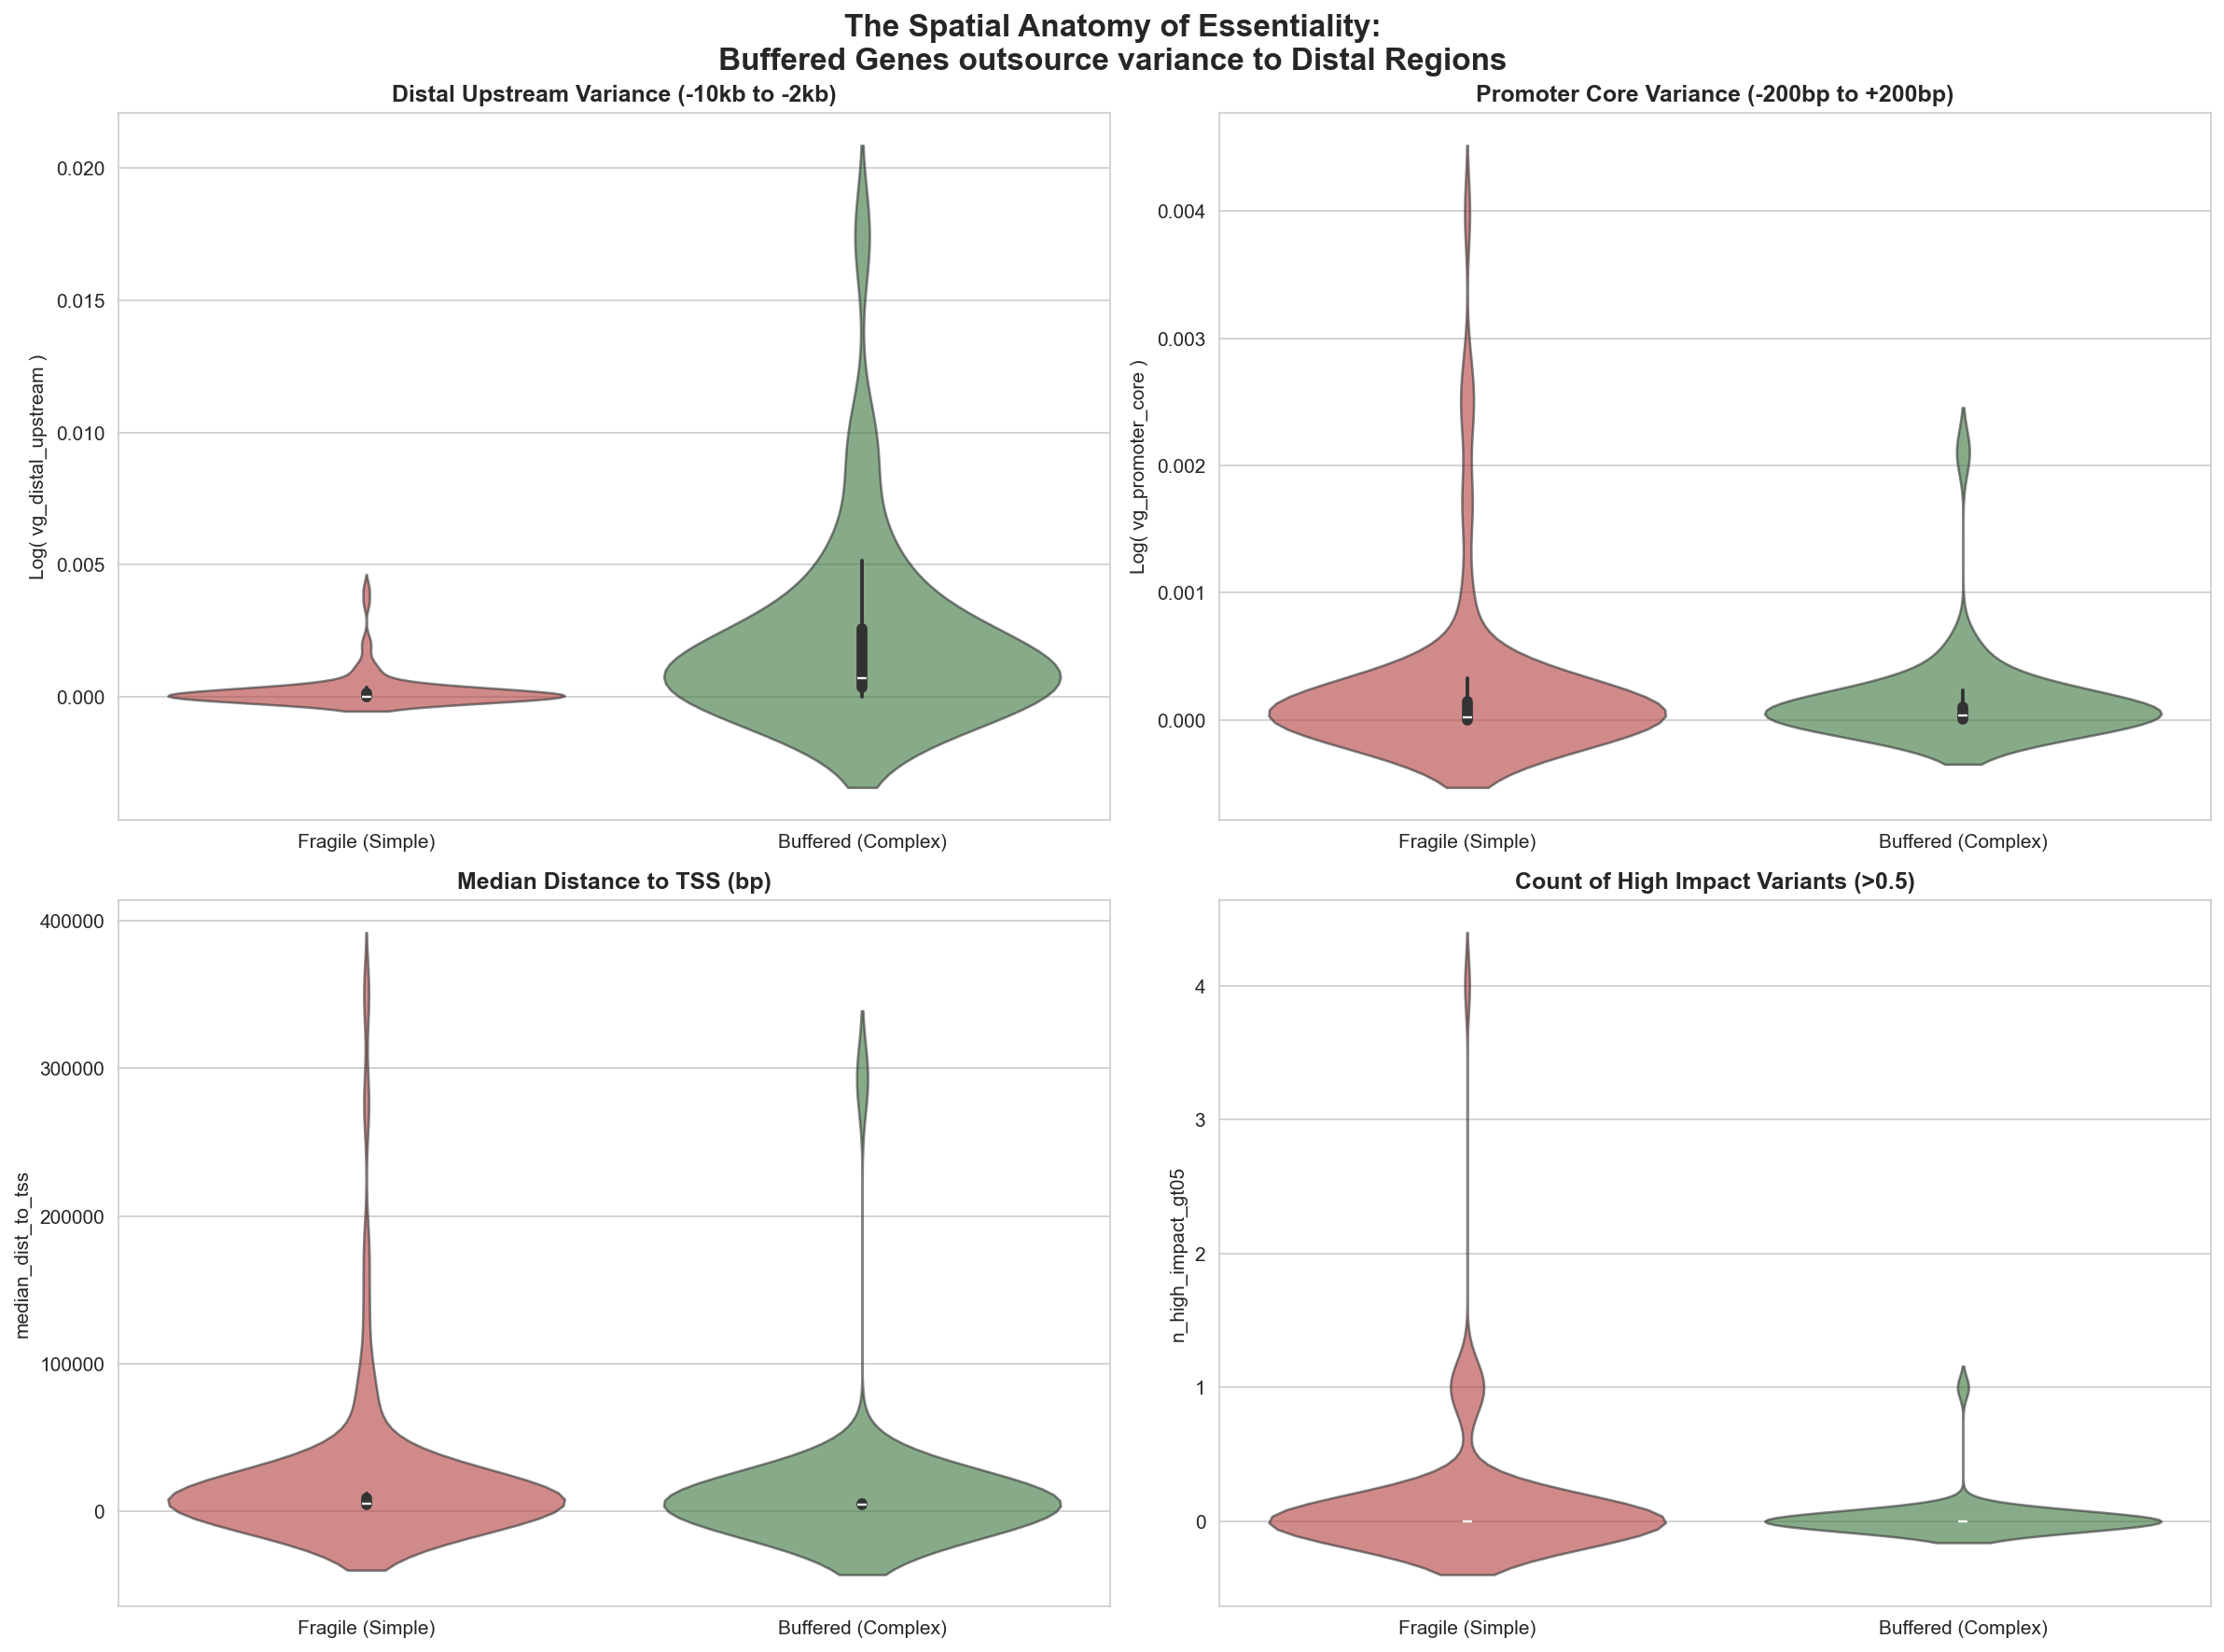

/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_52685/670222882.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Group', y='enhancer_load', ax=axes[0],
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_52685/670222882.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Group', y='N90', ax=axes[1],
/var/folders/4k/lmr1c7ss61n50vqkw_40j0pm0000gn/T/ipykernel_52685/670222882.py:126: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Group', y='constraint_score', ax=axes[2],

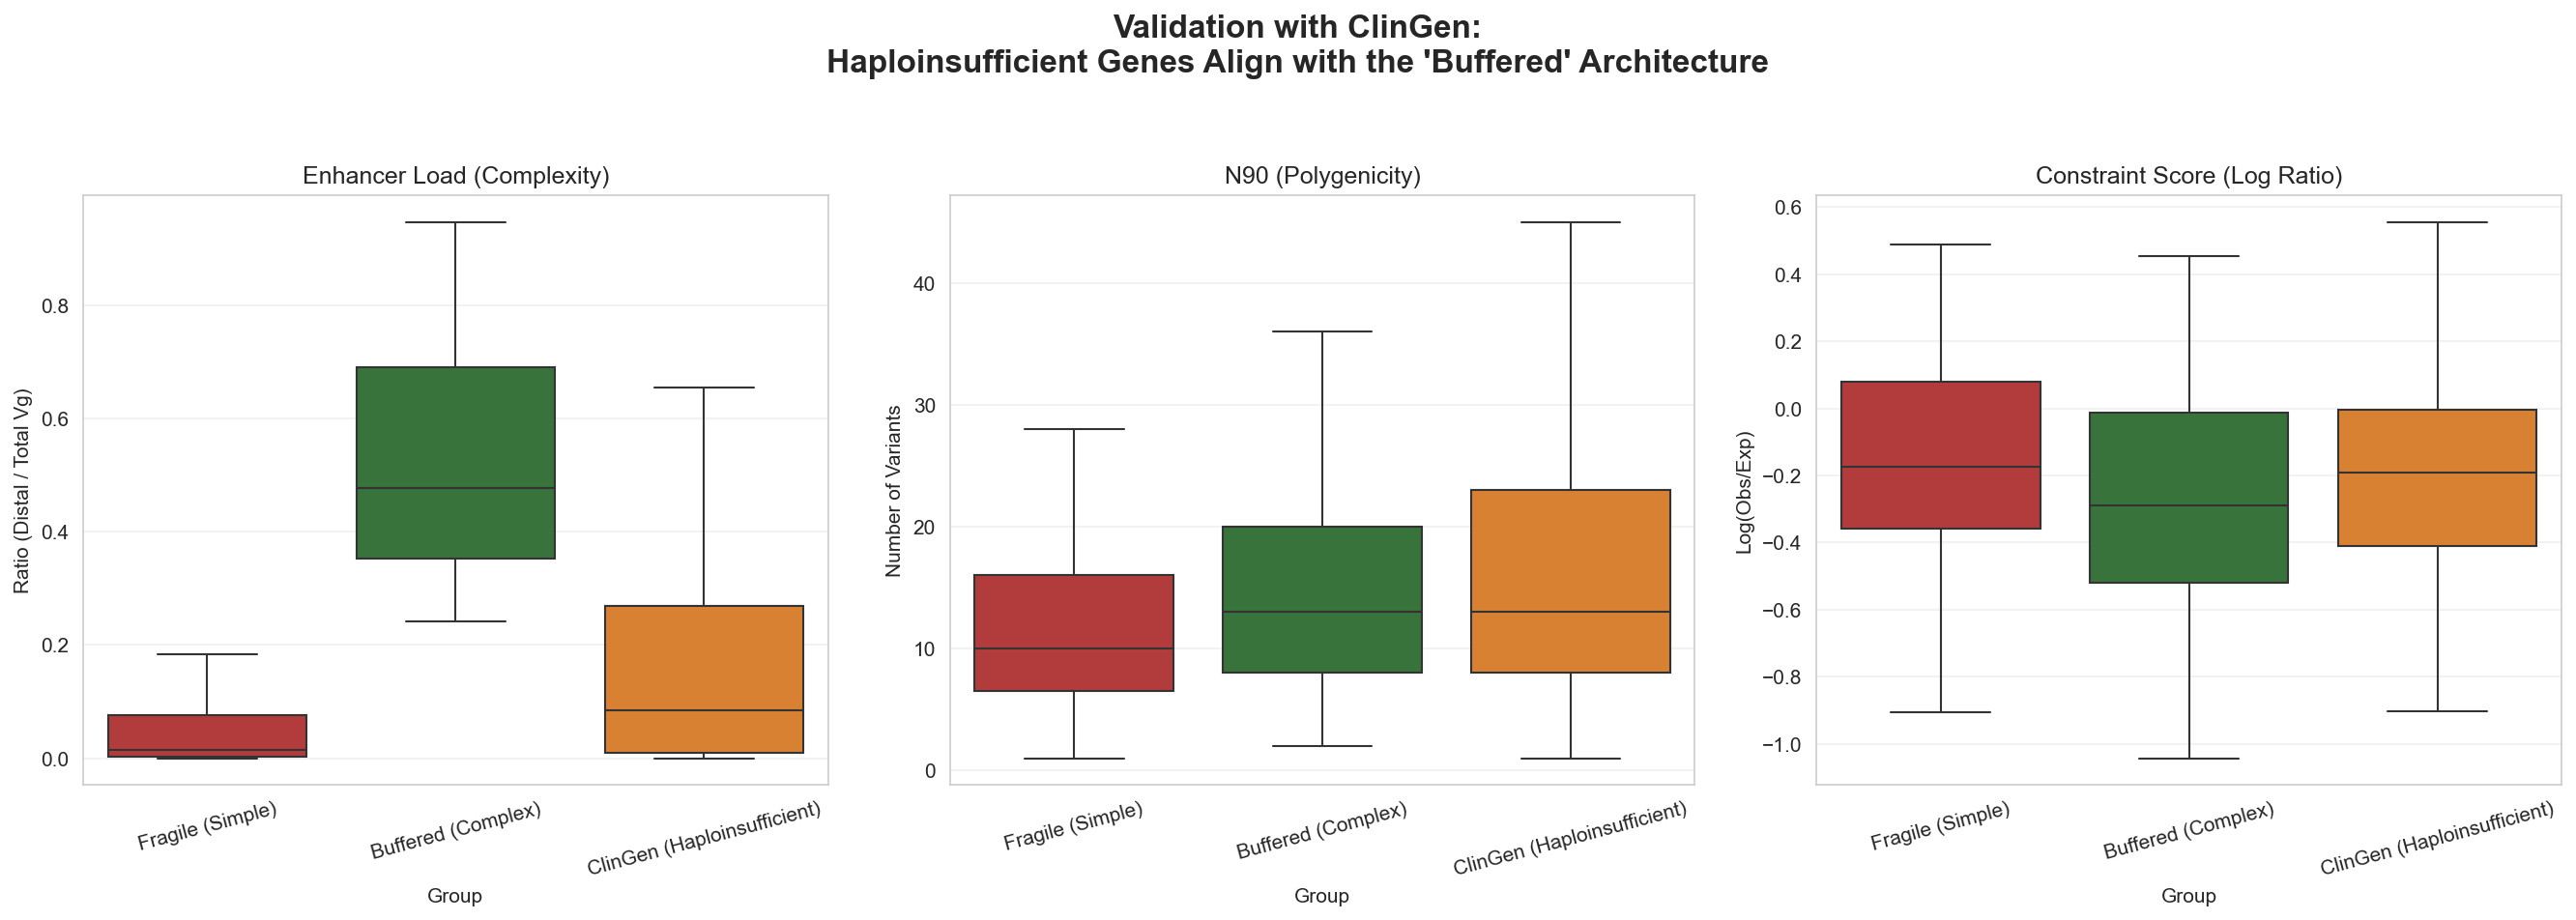


STATISTICAL VALIDATION: Is ClinGen different from Fragile Background?

Metric: enhancer_load
  ClinGen Median: 0.0851
  Fragile Median: 0.0149
  P-value (ClinGen > Fragile): 1.6710e-07
  >> VALIDATED: ClinGen genes match the High-Complexity phenotype.
 Count of Clingen enhancer_load: 316
 Count of Fragile enhancer_load: 91
 Count of Total enhancer_load: 444

Metric: N90
  ClinGen Median: 13.0000
  Fragile Median: 10.0000
  P-value (ClinGen > Fragile): 2.6535e-04
  >> VALIDATED: ClinGen genes match the High-Complexity phenotype.
 Count of Clingen N90: 316
 Count of Fragile N90: 91
 Count of Total N90: 444


In [ ]:
import polars as pl
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# --- 1. Load Data (Background + ClinGen) ---
# We load both to compare them side-by-side
print(f"Loading datasets...")
bg_df = pl.read_parquet(GENE_PATHS['background']).to_pandas()
clingen_df = pl.read_parquet(GENE_PATHS['clingen']).to_pandas()

# Label them
bg_df['dataset'] = 'Background'
clingen_df['dataset'] = 'ClinGen (Haploinsufficient)'

# --- 2. Feature Engineering Helper (Apply to BOTH) ---
def add_architectural_features(df):
    # Avoid div by zero
    epsilon = 1e-9
    
    # 1. Enhancer Load (Distal / Total)
    df['enhancer_load'] = df['vg_distal_upstream'] / (df['vg_predicted'] + epsilon)
    
    # 2. Promoter Dominance (Promoter / Total)
    df['promoter_dominance'] = df['vg_promoter_core'] / (df['vg_predicted'] + epsilon)
    
    # 3. Balance Metric (Homeostasis)
    df['balance_metric'] = np.abs(df['mean_raw_score']) / (df['mean_abs_effect'] + epsilon)
    
    # 4. Constraint Score (Log Ratio)
    df['constraint_score'] = np.log10((df['vg_predicted'] + epsilon) / (df['vg_perm_mean'] + epsilon))
    
    # 5. Enrichment (Promoter Density)
    df['enrich_promoter_vg'] = (df['mean_abs_promoter_core'] / (df['mean_abs_effect'] + epsilon))
    
    return df

# Apply features
bg_df = add_architectural_features(bg_df)
clingen_df = add_architectural_features(clingen_df)

# Filter Background for Essentials (Our "Discovery" Set)
bg_ess = bg_df[bg_df['loeuf_score'] < 0.6].copy()

# --- 3. Classify Background Genes (Re-run Clustering logic) ---
# We use the median 'enhancer_load' of the clusters we found earlier to split them
# (Simple thresholding is robust for this validation)
from sklearn.cluster import KMeans
X = bg_ess[['enhancer_load', 'N90', 'balance_metric']].copy()
X['enhancer_load'] = np.log1p(X['enhancer_load']) # Log transform for clustering
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
bg_ess['cluster'] = kmeans.fit_predict(StandardScaler().fit_transform(X))

# Identify Buffered Cluster (Higher Enhancer Load)
cluster_means = bg_ess.groupby('cluster')['enhancer_load'].mean()
buffered_id = cluster_means.idxmax()
bg_ess['Architecture'] = bg_ess['cluster'].apply(
    lambda x: 'Buffered (Complex)' if x == buffered_id else 'Fragile (Simple)'
)

# --- 4. VISUALIZATION A: Spatial Violin Plots (The "Anatomy" of Buffering) ---
# We want to see WHERE the variance is coming from
spatial_metrics = [
    ('vg_distal_upstream', 'Distal Upstream Variance (-10kb to -2kb)'),
    ('vg_promoter_core', 'Promoter Core Variance (-200bp to +200bp)'),
    ('median_dist_to_tss', 'Median Distance to TSS (bp)'),
    ('n_high_impact_gt05', 'Count of High Impact Variants (>0.5)')
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (metric, title) in enumerate(spatial_metrics):
    # Log scale for variance metrics
    if 'vg' in metric:
        data = np.log1p(bg_ess[metric])
        ylabel = f"Log( {metric} )"
    else:
        data = bg_ess[metric]
        ylabel = metric
        
    sns.violinplot(x=bg_ess['Architecture'], y=data, ax=axes[i], 
                   palette={'Buffered (Complex)': '#2E7D32', 'Fragile (Simple)': '#C62828'}, alpha=0.6)
    
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_ylabel(ylabel)
    axes[i].set_xlabel('')

plt.suptitle("The Spatial Anatomy of Essentiality:\nBuffered Genes outsource variance to Distal Regions", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


# --- 5. VISUALIZATION B: ClinGen Validation (The Positive Control) ---
# Hypothesis: ClinGen genes (Dosage Sensitive) should look like Buffered Genes.

# Prepare plot data
# We combine:
# 1. Background Buffered
# 2. Background Fragile
# 3. ClinGen (All)
bg_ess['Group'] = bg_ess['Architecture']
clingen_df['Group'] = 'ClinGen (Haploinsufficient)'

# Combine columns needed
cols = ['Group', 'enhancer_load', 'N90', 'constraint_score']
plot_df = pd.concat([bg_ess[cols], clingen_df[cols]], axis=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Enhancer Load
sns.boxplot(data=plot_df, x='Group', y='enhancer_load', ax=axes[0], 
            palette={'Buffered (Complex)': '#2E7D32', 'Fragile (Simple)': '#C62828', 'ClinGen (Haploinsufficient)': '#F57F17'}, showfliers=False)
axes[0].set_title("Enhancer Load (Complexity)")
axes[0].set_ylabel("Ratio (Distal / Total Vg)")

# Plot 2: N90 (Polygenicity)
sns.boxplot(data=plot_df, x='Group', y='N90', ax=axes[1], 
            palette={'Buffered (Complex)': '#2E7D32', 'Fragile (Simple)': '#C62828', 'ClinGen (Haploinsufficient)': '#F57F17'}, showfliers=False)
axes[1].set_title("N90 (Polygenicity)")
axes[1].set_ylabel("Number of Variants")

# Plot 3: Constraint Score
sns.boxplot(data=plot_df, x='Group', y='constraint_score', ax=axes[2], 
            palette={'Buffered (Complex)': '#2E7D32', 'Fragile (Simple)': '#C62828', 'ClinGen (Haploinsufficient)': '#F57F17'}, showfliers=False)
axes[2].set_title("Constraint Score (Log Ratio)")
axes[2].set_ylabel("Log(Obs/Exp)")

for ax in axes:
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle("Validation with ClinGen:\nHaploinsufficient Genes Align with the 'Buffered' Architecture", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# --- 6. Statistical Proof (Mann-Whitney) ---
print(f"\n{'='*60}")
print("STATISTICAL VALIDATION: Is ClinGen different from Fragile Background?")
print(f"{'='*60}")

features_to_test = ['enhancer_load', 'N90']
fragile_grp = plot_df[plot_df['Group'] == 'Fragile (Simple)']
clingen_grp = plot_df[plot_df['Group'] == 'ClinGen (Haploinsufficient)']

for feat in features_to_test:
    stat, p = stats.mannwhitneyu(clingen_grp[feat], fragile_grp[feat], alternative='greater')
    print(f"\nMetric: {feat}")
    print(f"  ClinGen Median: {clingen_grp[feat].median():.4f}")
    print(f"  Fragile Median: {fragile_grp[feat].median():.4f}")
    print(f"  P-value (ClinGen > Fragile): {p:.4e}")
    if p < 0.05: print("  >> VALIDATED: ClinGen genes match the High-Complexity phenotype.")
    print(f" Count of Clingen {feat}: {len(clingen_grp[feat]):,}")
    print(f" Count of Fragile {feat}: {len(fragile_grp[feat]):,}")
    print(f" Count of Total {feat}: {len(plot_df[feat]):,}")


In [ ]:
# vg_distal_upstream
# vg_promoter_core
# vg_predicted
# vg_perm_mean
# vg_perm_median
# vg_perm_std
# vg_perm_min